# Systematic coupler characterization

Two lookup tables are built from this notebook:

1. **`f0g1_fine_func(I_mA) -> MHz`** — refined f0g1 transition frequency vs DC flux current.
   Built in two passes: a coarse 2D `f0g1` spectroscopy vs current, then a per-current
   refinement loop (length Rabi -> error amplification on frequency -> length Rabi),
   borrowing the multiphoton-calibration sequence.
2. **`f_coupler_func(I_mA) -> MHz`** — coupler frequency vs current. Built from a 2D
   coupler spectroscopy vs current, with the f0g1 drive frequency pulled from
   table 1 at every row so the state-selective readout sequence stays calibrated.

All inner experiments are submitted via the queue/worker workflow
(`CharacterizationRunner.run`), so the worker auto-ramps `station.yoko_coupler` and
each point is logged to the lab notebook (`log_measurements=True` on the station).

Tables are pickled to `coupler_lookup_tables.pkl` next to this notebook so later
notebooks can reload them without rerunning.

## Imports and station setup

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


import pickle
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from slab import AttrDict
from job_server import JobClient

client = JobClient()
health = client.health_check()
print(f"Server status: {health['status']}, pending: {health['pending_jobs']}")

USER = 'seb'
EXPERIMENT_NAME = '260420_T2_AC_stark'

# log_measurements=True wires every queue-side run() into the lab notebook (vault).
# Per-point logging in the inner sweeps can be silenced with `log=False` on run().
station = MultimodeStation(
    user=USER,
    experiment_name=EXPERIMENT_NAME,
    project='Stark-induced sweet spot',
    log_measurements=True,
)

USE_QUEUE = True
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)

station.hardware_cfg.device

LOOKUP_PATH = Path(station.data_path) / 'coupler_lookup_tables.pkl'
print(f'Lookup tables will be written to: {LOOKUP_PATH}')

In [ ]:
station.hardware_cfg.device.readout.relay_delay = 1000

## Shared utilities

Per-row Lorentzian fitter (used for both f0g1 spec and coupler spec) plus a
small polynomial helper. The shape of `f0g1(I)` is roughly `|cos|`-like over
the working range, so a degree-4 polynomial is a reasonable local proxy --
adjust `POLY_DEG` per section if a row has more curvature.

In [ ]:
def _lorentzian(x, A, x0, gamma, offset):
    return offset + A / (1.0 + ((x - x0) / gamma) ** 2)

def fit_peak_per_row(freqs, signal_2d, sign=1,
                     smooth_window=11, fit_window=20, min_gamma_steps=1):
    """Robust per-row Lorentzian fit for narrow peaks in a wide scan.

    1. Savitzky-Golay smooth + median baseline -> reliable argmax even when
       the true peak spans only ~2 raw points.
    2. Fit a Lorentzian in a [-fit_window, +fit_window]-step neighbourhood
       around that argmax, with bounds on gamma and x0 so the optimiser
       can't run away to a wide-shoulder local minimum.
    """
    freqs = np.asarray(freqs, dtype=float)
    signal_2d = np.asarray(signal_2d, dtype=float)
    n_rows, n_pts = signal_2d.shape
    step = float(abs(freqs[1] - freqs[0]))
    peaks = np.full(n_rows, np.nan)

    sw = min(int(smooth_window) | 1, n_pts - (1 - n_pts % 2))  # odd, <= n_pts
    for i, row in enumerate(signal_2d):
        s = sign * np.asarray(row, dtype=float)
        s_smooth = savgol_filter(s, sw, polyorder=2) if sw >= 5 else s
        baseline = float(np.median(s_smooth))
        peak_idx = int(np.argmax(s_smooth - baseline))

        i0 = max(0, peak_idx - fit_window)
        i1 = min(n_pts, peak_idx + fit_window + 1)
        x_win = freqs[i0:i1]
        y_win = s[i0:i1] - baseline
        if x_win.size < 5:
            continue

        amp0 = float(np.max(y_win))
        x00 = float(freqs[peak_idx])
        gamma0 = max(step * min_gamma_steps, 2 * step)
        try:
            popt, _ = curve_fit(
                _lorentzian, x_win, y_win,
                p0=[amp0, x00, gamma0, 0.0],
                bounds=(
                    [0.0,           x_win[0],  step,                  -np.inf],
                    [10 * amp0 + 1e-9, x_win[-1], (i1 - i0) * step,    np.inf],
                ),
                maxfev=4000,
            )
            peaks[i] = popt[1]
        except Exception:
            peaks[i] = np.nan
    return peaks



def polyfit_lookup(currents_mA, peaks_MHz, deg):
    """NaN-safe `np.polyfit` -> `np.poly1d`. Returns (coeffs, callable)."""
    currents_mA = np.asarray(currents_mA, dtype=float)
    peaks_MHz = np.asarray(peaks_MHz, dtype=float)
    mask = np.isfinite(peaks_MHz)
    if mask.sum() < deg + 1:
        raise RuntimeError(
            f'Need at least {deg+1} valid points to fit deg-{deg}, got {mask.sum()}')
    coeffs = np.polyfit(currents_mA[mask], peaks_MHz[mask], deg)
    return coeffs, np.poly1d(coeffs)


# --- Per-current characterization pickle helpers ---
# These layer on top of the existing `_section` / `_section_differs` save logic
# (cell "Modify the lookup tables if needed"); they touch only the
# 'characterization' subdict so the f0g1/coupler polyfit sections are untouched.

def _round_key(I_mA, decimals=4):
    """Stable float key for the per-current dict (avoids -0.0 / +0.0 split)."""
    return float(np.round(float(I_mA) + 0.0, decimals))


def pickle_load(path):
    """Read the lookup pickle. Returns {} if the file is absent."""
    path = Path(path)
    if not path.exists():
        return {}
    with open(path, 'rb') as f:
        return pickle.load(f)


def pickle_atomic_save(path, data):
    """Write `data` to `path` atomically via temp-file + replace."""
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    with open(tmp, 'wb') as f:
        pickle.dump(data, f)
    tmp.replace(path)


def pickle_save_per_current(path, I_mA, **fields):
    """Merge `fields` into pickle['characterization'][round(I_mA)] non-destructively.

    All other top-level keys (f0g1_coarse, f0g1_fine, coupler, metadata) are
    preserved. Crash-resilient: each call is one atomic disk write, so a
    kernel death between calls only loses the unwritten fields.
    """
    data = pickle_load(path)
    char = data.setdefault('characterization', {})
    entry = char.setdefault(_round_key(I_mA), {})
    entry.update(fields)

    # Ensure the manipulate-channel metrics exist in every per-current entry.
    # Prefer values explicitly passed in `fields`, then fall back to any
    # previously saved `manipulate` sub-dict, else set NaN so downstream
    # notebooks always find the keys.
    man_sub = entry.get('manipulate', {}) or {}
    entry.setdefault('T1_manipulate',
                     fields.get('T1_manipulate', man_sub.get('T1_us', float('nan'))))
    entry.setdefault('T2_ramsey_manipulate',
                     fields.get('T2_ramsey_manipulate', man_sub.get('T2_ramsey_us', float('nan'))))
    entry.setdefault('T2_ramsey_freq_manipulate',
                     fields.get('T2_ramsey_freq_manipulate', man_sub.get('T2_ramsey_freq_MHz', float('nan'))))
    entry.setdefault('T2_echo_manipulate',
                     fields.get('T2_echo_manipulate', man_sub.get('T2_echo_us', float('nan'))))

    entry['updated_at'] = str(np.datetime64('now'))
    pickle_atomic_save(path, data)


def pickle_get_per_current(path, I_mA):
    """Read the per-current entry, or {} if not yet present."""
    return pickle_load(path).get('characterization', {}).get(_round_key(I_mA), {})


def migrate_T2_keys(path, *, verbose=True):
    """One-shot migration: rename per-current `T2_us` -> `T2_short_us` (or `T2_long_us`).

    Old schema stored a single `T2_us` whose meaning depended on `T2_path`:
    'ramsey' (long_T2 branch) vs 'spec_vs_power+rabi_vs_sigma' (short_T2 branch).
    New schema stores both `T2_long_us` and `T2_short_us` side by side so the
    two methods can be compared directly. Also renames the long-branch sub-dict
    `T2` -> `T2_long`. Idempotent: skips entries already in the new schema.
    """
    data = pickle_load(path)
    char = data.get('characterization', {})
    n_short = n_long = 0
    for I, entry in char.items():
        if 'T2' in entry and 'T2_long' not in entry:
            entry['T2_long'] = entry.pop('T2')
        if 'T2_us' not in entry:
            continue
        old_T2 = entry.pop('T2_us')
        if old_T2 is None:
            continue
        if entry.get('T2_path') == 'ramsey':
            entry.setdefault('T2_long_us', float(old_T2))
            n_long += 1
        else:
            entry.setdefault('T2_short_us', float(old_T2))
            n_short += 1
    if (n_short + n_long) > 0:
        pickle_atomic_save(path, data)
        if verbose:
            print(f'[migrate_T2_keys] migrated {n_short} short_T2 + {n_long} long_T2 entries')
    elif verbose:
        print('[migrate_T2_keys] nothing to migrate (already in new schema)')
    return n_short, n_long


## Lookup table 1: f0g1 vs current

In [ ]:
if LOOKUP_PATH.exists():
    with open(LOOKUP_PATH, 'rb') as f:
        lookup_on_disk = pickle.load(f)
    print(f'Loaded {LOOKUP_PATH}')
    for k, v in lookup_on_disk.items():
        if isinstance(v, dict):
            preview = {kk: (vv.shape if isinstance(vv, np.ndarray) else vv)
                       for kk, vv in v.items()}
            print(f'  {k}: {preview}')
        else:
            print(f'  {k} = {v}')

    # Rebuild callables + supporting variables so downstream Step 4 cells
    # (and Step 2/3 if needed) can use the lookups without rerunning Steps 1-2.
    _sec = lookup_on_disk['f0g1_coarse']
    F0G1_COARSE_DEG     = int(_sec['deg'])
    f0g1_coarse_coeffs  = np.asarray(_sec['coeffs'], dtype=float)
    f0g1_currents_mA    = np.asarray(_sec['currents_mA'], dtype=float)
    f0g1_coarse_peaks   = np.asarray(_sec['peaks_MHz'], dtype=float)
    f0g1_coarse_func    = np.poly1d(f0g1_coarse_coeffs)

    _sec = lookup_on_disk['f0g1_fine']
    F0G1_FINE_DEG       = int(_sec['deg'])
    f0g1_fine_coeffs    = np.asarray(_sec['coeffs'], dtype=float)
    currents_refine_mA  = np.asarray(_sec['currents_mA'], dtype=float)
    refined_freqs_MHz   = np.asarray(_sec['peaks_MHz'], dtype=float)
    f0g1_fine_func      = np.poly1d(f0g1_fine_coeffs)

    _sec = lookup_on_disk['coupler']
    COUPLER_DEG         = int(_sec['deg'])
    coupler_coeffs      = np.asarray(_sec['coeffs'], dtype=float)
    coupler_currents_mA = np.asarray(_sec['currents_mA'], dtype=float)
    coupler_peaks       = np.asarray(_sec['peaks_MHz'], dtype=float)
    f_coupler_func      = np.poly1d(coupler_coeffs)

    for k_disk, k_local in (('I_start_ma', 'I_start_ma'), ('I_stop_ma', 'I_stop_ma'),
                            ('I_start_mA', 'I_start_ma'), ('I_stop_mA', 'I_stop_ma')):
        if k_disk in lookup_on_disk:
            globals()[k_local] = float(lookup_on_disk[k_disk])

    I_check = float(np.median(currents_refine_mA))
    print('Rehydrated callables. Sanity:')
    print(f'  f0g1_fine_func({I_check:+.4f} mA) = {f0g1_fine_func(I_check):.4f} MHz')
    print(f'  f_coupler_func({I_check:+.4f} mA) = {f_coupler_func(I_check):.4f} MHz')
else:
    lookup_on_disk = None
    print(f'No lookup table at {LOOKUP_PATH} -- run Steps 1 and 2 to build it.')


In [ ]:
# T2_us -> {T2_long_us, T2_short_us} migration (run once)
# Run once after pulling this notebook update; subsequent runs are no-ops.
migrate_T2_keys(LOOKUP_PATH)


## Flux range

Shared by every step so all the lookups share an x-axis. The set point is the
nominal coupler bias; refinement uses a narrower window to keep the
length-Rabi / error-amp / length-Rabi sequence at a useful SNR.

In [ ]:

I_start_ma = 0          # start of current sweep [mA]
I_stop_ma  = 0.1         # stop of current sweep [mA]
I_npts     = 15             # number of points in current sweep
I_refine_npts = 10          # sparser grid for the refinement loop (slow)
SAFETY_MA  = 1.5            # hard cap on |I_m

currents_coarse_mA  = np.linspace(I_start_ma, I_stop_ma, I_npts)
currents_refine_mA  = np.linspace(I_start_ma, I_stop_ma, I_refine_npts)
assert np.max(np.abs(currents_coarse_mA)) < SAFETY_MA
print(f"Coarse currents (mA): {currents_coarse_mA}")
print(f"Refine currents (mA): {currents_refine_mA}")


## Coupler runners

All runner objects used by Steps 2 / 3 / 4. Run this section once per
kernel; it depends only on `station`, `client`, and `USE_QUEUE` from the
imports cell, so it works whether you build the lookups from scratch or
rehydrate them from disk.

If you only want Step 4 (lookups already on disk), the SOP is:
imports cell -> shared utilities -> load lookups -> flux range -> this
section -> jump to Step 4.

In [ ]:
coupler_spec_defaults = AttrDict(dict(
    start=3800.0, step=2.0, expts=201,
    length=5.0, gain=5000,
    reps=200, rounds=1,
    qubits=[0], man_mode_no=1,
    coupler_f=False,                # True = drive coupler g->e first (probe e-f)
    f0g1_freq=None,                 # MHz; None -> use hardware_cfg multiphoton freq
    prepulse=False, pre_sweep_pulse=None,
    active_reset=False,
))

coupler_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
    default_expt_cfg=coupler_spec_defaults,
    job_client=client,
    use_queue=USE_QUEUE,
)

In [ ]:
coupler_rabi_defaults = AttrDict(dict(
    start=0,
    step=320,        # gain step [DAC]; 320 * 100 = 32000 max for default expts=101
    expts=101,
    pulse_type='gauss',
    freq=4100.0,        # placeholder; overridden at execute()
    sigma=0.5,          # us; gauss envelope length = 4*sigma = 2 us (~12k DAC samples)
    length=5.0,         # us; only used if pulse_type='const' is passed at execute()
    reps=400,
    rounds=1,
    qubits=[0],
    man_mode_no=1,
    prepulse=False,
    pre_sweep_pulse=None,
    active_reset=False,
))


def coupler_rabi_postproc(station, expt):
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


coupler_rabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.AmplitudeRabiCouplerExperiment,
    default_expt_cfg=coupler_rabi_defaults,
    postprocessor=coupler_rabi_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


In [ ]:
coupler_length_rabi_defaults = AttrDict(dict(
    start=0.0,
    step=0.02,        # length step [us]
    expts=101,
    pulse_type='const',
    freq=4100.0,      # placeholder; overridden at execute()
    gain=10000,       # placeholder; overridden at execute()
    reps=400,
    rounds=1,
    qubits=[0],
    man_mode_no=1,
    f0g1_freq=None,
    prepulse=False,
    pre_sweep_pulse=None,
    active_reset=False,
))


def coupler_length_rabi_postproc(station, expt):
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


coupler_length_rabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.LengthRabiCouplerExperiment,
    default_expt_cfg=coupler_length_rabi_defaults,
    postprocessor=coupler_length_rabi_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


In [ ]:
# --- T1, Ramsey, and spec-vs-gain runners for Step 4 ---

coupler_t1_defaults = AttrDict(dict(
    start=0.0, step=2.5, expts=101,
    reps=250, rounds=1,
    qubits=[0], man_mode_no=1,
    # pulse_type omitted: initialize() resolves from pi_ge.type[0], or falls back to 'const'.
    freq=None, length=None, sigma=None, gain=None,
    f0g1_freq=None,
    prepulse=False, pre_sweep_pulse=None,
    active_reset=False,
))


def coupler_t1_postproc(station, expt):
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


coupler_t1_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.T1CouplerExperiment,
    default_expt_cfg=coupler_t1_defaults,
    postprocessor=coupler_t1_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


coupler_ramsey_defaults = AttrDict(dict(
    start=0.0, step=0.01, expts=501,    # tau sweep [us]: 0 to 1.0 us
    ramsey_freq=2.0,
    reps=200, rounds=1,
    qubits=[0], man_mode_no=1,
    pulse_type='gauss',
    freq=None, sigma=None, length=None, gain=None,
    f0g1_freq=None,
    advance_phase=0,
    prepulse=False, pre_sweep_pulse=None,
    active_reset=False,
))


def coupler_ramsey_postproc(station, expt):
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


coupler_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.RamseyCouplerExperiment,
    default_expt_cfg=coupler_ramsey_defaults,
    postprocessor=coupler_ramsey_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


# Coupler spectroscopy vs probe gain (short-T2 branch). Wraps
# PulseProbeCouplerSpectroscopyExperiment in a SweepRunner over `gain`.
coupler_spec_vs_gain_runner = SweepRunner(
    station=station,
    ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
    default_expt_cfg=coupler_spec_defaults,
    sweep_param='gain',
    live_plot=False,
    job_client=client,
    use_queue=USE_QUEUE,
)


In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    cavity_freq=4984.373226159381,
    cavity_gain=400,
    cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # add the active reset dict to the expt config so that it can be used in the postprocessor
    
    return expt_cfg



def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')


## Step 1a -- Coarse f0g1 spectroscopy vs flux current

Inner experiment: `meas.PulseProbeF0g1SpectroscopyExperiment`. Outer loop is a
queue-based current sweep (mirrors `f0g1_stark_flux_sensitivity.ipynb`). The
preprocessor injects the |f> prep (`prep_man_photon + pi_ge + pi_ef`) so the
spectroscopy peak appears.

In [ ]:
f0g1_spec_defaults = AttrDict(dict(
    man_mode_no=1,
    start=1999,
    step=0.025,
    expts=151,
    reps=500,
    rounds=1,
    length=20.0,
    gain=100,
    pulse_type='gaussian',
    qubit_f=False,
    qubits=[0],
    transition=None,            # set to 'f0-g1' at execute time
    relax_delay=200,
    active_reset=False,
    prepulse=False,
    pre_sweep_pulse=None,
))


def qspec_preproc(station, default_expt_cfg, **kwargs):
    """Build the |f> prep prepulse from the calibrated multiphoton config."""
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])
        pre_sweep_pulse = mm_base_calib.prep_man_photon(
            man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', f'g{i}-e{i}', 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', f'e{i}-f{i}', 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(
            pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0

    if expt_cfg.start is None:
        expt_cfg.start = station.hardware_cfg.device.multiphoton['pi']['f0n-g1n+1']['frequency'][0] - 1.0
    return expt_cfg

In [ ]:
f0g1_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
    default_expt_cfg=f0g1_spec_defaults,
    preprocessor=qspec_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


def f0g1_current_sweep(currents_mA, *, sideband='f0-g1', log_per_point=False, **expt_overrides):
    """Outer loop over current; inner = `PulseProbeF0g1SpectroscopyExperiment`."""
    expt_cfg = AttrDict(deepcopy(dict(f0g1_spec_defaults)))
    expt_cfg.update(expt_overrides)

    mother_expt = meas.PulseProbeF0g1SpectroscopyExperiment(
        soccfg=station.soccfg, path=station.data_path,
        prefix='PulseProbeF0g1Spectroscopy_coupler_current_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {'coupler_current_sweep_mA': [],
                        'xpts': [], 'avgi': [], 'avgq': [], 'amps': [], 'phases': []}

    print(f'f0g1 spec sweep: {len(currents_mA)} pts, '
          f'I in [{currents_mA[0]:.4f}, {currents_mA[-1]:.4f}] mA')
    for idx, i_mA in enumerate(currents_mA):
        print(f'  [{idx+1}/{len(currents_mA)}] I = {i_mA:.4f} mA')
        expt = f0g1_spec_runner.run(
            coupler_current=float(i_mA * 1e-3),
            transition=sideband,
            log=log_per_point,
            **expt_overrides,
        )
        mother_expt.data['coupler_current_sweep_mA'].append(float(i_mA))
        for key in ('xpts', 'avgi', 'avgq', 'amps', 'phases'):
            if key in expt.data:
                mother_expt.data[key].append(np.asarray(expt.data[key]))
    return mother_expt

In [ ]:
f_start = 1965
f_step = 2010
expts = 1500
step = (f_step - f_start) / (expts - 1)


f0g1_2d_coarse = f0g1_current_sweep(
    currents_coarse_mA,
    sideband='f0-g1',
    start=f_start,
    step=step,
    expts=expts,
    gain=500, 
    length=20.0,
    reps=200,
    rounds=1,
)

In [ ]:
F0G1_FIT_CHANNEL = 'avgi'
F0G1_FIT_SIGN    = -1     # flip to -1 if the peak goes negative on this channel
F0G1_COARSE_DEG  = 5     # f0g1(I) is |cos|-like; deg 2 over a narrow window

f0g1_currents_mA = np.asarray(f0g1_2d_coarse.data['coupler_current_sweep_mA'])
f0g1_freqs_MHz   = np.asarray(f0g1_2d_coarse.data['xpts'][0])
f0g1_sig_2d      = np.asarray(f0g1_2d_coarse.data[F0G1_FIT_CHANNEL])

f0g1_coarse_peaks = fit_peak_per_row(f0g1_freqs_MHz, f0g1_sig_2d, sign=F0G1_FIT_SIGN)
f0g1_coarse_coeffs, f0g1_coarse_func = polyfit_lookup(
    f0g1_currents_mA, f0g1_coarse_peaks, deg=F0G1_COARSE_DEG)

print(f'Coarse polyfit (deg {F0G1_COARSE_DEG}): {f0g1_coarse_coeffs}')
print(f'f0g1_coarse({I_start_ma:.3f} mA) = {f0g1_coarse_func(I_start_ma):.4f} MHz')



In [ ]:
fig_summary, axes = plt.subplots(1, 2, figsize=(13, 5))
pcm = axes[0].pcolormesh(f0g1_freqs_MHz, f0g1_currents_mA, f0g1_sig_2d,
                         shading='auto', cmap='viridis')
axes[0].plot(f0g1_coarse_peaks, f0g1_currents_mA, 'r.', ms=4)
axes[0].set_xlabel('Probe frequency [MHz]')
axes[0].set_ylabel('Coupler current [mA]')
axes[0].set_title('Coarse f0g1 spectroscopy vs flux')
fig_summary.colorbar(pcm, ax=axes[0], label=F0G1_FIT_CHANNEL)

I_dense = np.linspace(f0g1_currents_mA.min(), f0g1_currents_mA.max(), 200)
axes[1].plot(f0g1_currents_mA, f0g1_coarse_peaks, 'o', label='peak fits')
axes[1].plot(I_dense, f0g1_coarse_func(I_dense), '-', label=f'polyfit deg {F0G1_COARSE_DEG}')
axes[1].set_xlabel('Coupler current [mA]')
axes[1].set_ylabel('f0g1 peak [MHz]')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


fig_slices, ax = plt.subplots(figsize=(8, 6))
for idx, i_mA in enumerate(f0g1_currents_mA):
    sig = f0g1_sig_2d[idx]
    offset = idx * 0.5
    line, = ax.plot(f0g1_freqs_MHz, sig + offset, label=f'{i_mA:.3f} mA')
    peak = f0g1_coarse_peaks[idx]
    if np.isfinite(peak):
        ax.vlines(peak, sig.min() + offset, sig.max() + offset,
                  colors=line.get_color(), linestyles='--', linewidth=1)
ax.set_xlabel('Probe frequency [MHz]')
ax.set_ylabel('Signal (offset for visibility)')
ax.set_title('f0g1 spectra vs flux  (dashed = fitted peak)')
ax.legend(loc='upper right', fontsize='small')
plt.tight_layout(); plt.show()


# Persist the aggregated 2D h5 + log only the summary fig to the vault.
f0g1_2d_coarse.save_data()
station.log_measurement(
    # experiment=f0g1_2d_coarse,
    fig=fig_summary,
    title='Coarse f0g1 spectroscopy vs coupler current',
    notes=f'2D pcolormesh + per-row Lorentzian peaks + polyfit deg {F0G1_COARSE_DEG}.',
    parameters={
        'I_set_mA': float(I_start_ma),
        'I_stop_mA': float(I_stop_ma),
        'I_npts': int(I_npts),
        'fit_channel': F0G1_FIT_CHANNEL,
        'poly_deg': int(F0G1_COARSE_DEG),
        'poly_coeffs': f0g1_coarse_coeffs.tolist(),
        'f0g1_at_setpoint_MHz': float(f0g1_coarse_func(I_start_ma)),
        'f0g1_coarse': dict(
            deg=int(F0G1_COARSE_DEG),
            coeffs=np.asarray(f0g1_coarse_coeffs),
            currents_mA=np.asarray(f0g1_currents_mA),
            peaks_MHz=np.asarray(f0g1_coarse_peaks),
        ),
    },
)


## Step 1b -- Per-current f0g1 refinement

For each current on the refinement grid, run the multiphoton-calibration
sequence at the coarse-estimated frequency:

1. **Length Rabi** at `f = f0g1_coarse(I)` (sanity check, sets the contrast)
2. **Error amplification** with `parameter_to_test='frequency'`, sweeping a
   narrow band around `f0g1_coarse(I)` -- gives the refined frequency
3. **Length Rabi** at the refined frequency (verification)

Trick: passing `freq=` to `LengthRabiGeneralF0g1Experiment` and `start=freq-band`
to `ErrorAmplificationExperiment` overrides the `hardware_cfg` defaults *for
that single run only*, and we deliberately disable the error-amp postprocessor
(`postprocess=False`) so the refined freq does **not** get written back into
`station.hardware_cfg`. Refined values are returned and aggregated locally.

In [ ]:
length_rabi_f0g1_defaults = AttrDict(dict(
    man_mode_no=1,
    start=None, step=0.045, expts=50,
    qubits=[0], reps=100, rounds=1,
    gain=8000, freq=None,           # both filled at execute() time
    use_arb_waveform=False,
    pi_ge_before=False, pi_ef_before=False, pi_ge_after=False,
    normalize=False, active_reset=False,
    man_reset=True, stor_reset=True,
    check_man_reset=[False, 0], swap_lossy=False, check_man_reset_pi=[],
    prepulse=False, postpulse=False,
    pre_sweep_pulse=None, post_sweep_pulse=None,
    err_amp_reps=0, relax_delay=2500,
    transition=None,
))


def length_rabi_f0g1_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])
        pre_sweep_pulse = mm_base_calib.prep_man_photon(
            man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', f'g{i}-e{i}', 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', f'e{i}-f{i}', 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(
            pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i
        if expt_cfg.freq is None:
            expt_cfg.freq = station.hardware_cfg.device.multiphoton['pi'][
                expt_cfg._transition_key]['frequency'][i]
    if expt_cfg.start is None:
        expt_cfg.start = station.soccfg.cycles2us(3)
    return expt_cfg


lenrabi_fog1_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=length_rabi_f0g1_defaults,
    preprocessor=length_rabi_f0g1_preproc,
    postprocessor=None,             # don't write back during the loop
    job_client=client,
    use_queue=USE_QUEUE,
)

In [ ]:
error_amp_defaults = AttrDict(dict(
    reps=100, rounds=1, qubit=0,
    n_pulses=10,
    active_reset=False, man_reset=True, storage_reset=True,
    relax_delay=2500,
    start=0, expts=10, step=100,
    parameter_to_test='gain',       # overridden to 'frequency' at execute
    pulse_type=['qubit', 'ge', 'pi', 0],
    man_no=1, pulse_name='pi',
))


def error_amp_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    if expt_cfg.pulse_type[0] == 'multiphoton':
        transition = expt_cfg.pulse_type[1]
        expt_cfg._photon_idx = int(transition[1])
        if transition[0] in ('e', 'g'):
            expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n'
        elif transition[0] == 'f':
            expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        else:
            raise ValueError(f'Unknown transition format: {transition}')
    expt_cfg.qubits = [expt_cfg.qubit]
    return expt_cfg


# IMPORTANT: no postprocessor -- we extract the refined frequency manually so
# `station.hardware_cfg` is not mutated during the per-current loop.
error_amp_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_defaults,
    preprocessor=error_amp_preproc,
    postprocessor=None,
    job_client=client,
    use_queue=USE_QUEUE,
)

In [ ]:
chevron_defaults = AttrDict(dict(
    start=2, step=0.1, expts=25,
    reps=100, rounds=1, qubits=[0],
    gain=8000, ramp_sigma=0.005,
    use_arb_waveform=False,
    pi_ge_before=False, pi_ef_before=False, pi_ge_after=False,
    normalize=False, active_reset=False,
    check_man_reset=[False, 0], check_man_reset_pi=[],
    transition=None, err_amp_reps=0, swap_lossy=False,
    prepulse=False, postpulse=False,
    pre_sweep_pulse=None, post_sweep_pulse=None,
    man_mode_no=1,
))


def chevron_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])
        pre_sweep_pulse = mm_base_calib.prep_man_photon(
            man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', f'g{i}-e{i}', 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', f'e{i}-f{i}', 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(
            pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i
    return expt_cfg


def chevron_postproc_no_writeback(station, mother_expt):
    # Auto-rotate (avgi, avgq) onto the PCA axis before ChevronFitting reads
    # avgi -- same motivation as the error-amp case: the M1=1 leakage blob
    # sits off the single_shot-calibrated I axis, so signal leaks into Q and
    # the chevron contrast/period analysis loses SNR if we don't rotate.
    I = np.asarray(mother_expt.data['avgi'], dtype=float)
    Q = np.asarray(mother_expt.data['avgq'], dtype=float)
    pts = np.stack([I.ravel(), Q.ravel()], axis=1)
    pts -= pts.mean(axis=0, keepdims=True)
    cov = (pts.T @ pts) / max(len(pts) - 1, 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    new_I_axis = eigvecs[:, 1]
    new_Q_axis = eigvecs[:, 0]
    iq = np.stack([I, Q], axis=-1)
    mother_expt.data['avgi'] = np.tensordot(iq, new_I_axis, axes=1)
    mother_expt.data['avgq'] = np.tensordot(iq, new_Q_axis, axes=1)
    angle_deg = np.degrees(np.arctan2(new_I_axis[1], new_I_axis[0]))
    print(f'  chevron autorotate: angle={angle_deg:+.1f} deg, '
          f'eigval ratio={eigvals[1]/max(eigvals[0],1e-30):.1f}')

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=mother_expt.data['freq_sweep'],
        time=mother_expt.data['xpts'][0],
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )
    chevron_analysis.analyze()
    mother_expt.analysis = chevron_analysis
    chevron_analysis.display_results()

chevron_runner = SweepRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=chevron_defaults,
    sweep_param='freq',
    live_plot=True,
    preprocessor=chevron_preproc,
    postprocessor=chevron_postproc_no_writeback,
    job_client=client,
    use_queue=USE_QUEUE,
)


In [ ]:
def autorotate_error_amp(ea, state_fin='e', verbose=True):
    """PCA-rotate (avgi, avgq), then anchor the sign with the n_pulses=1 row.

    Why: PCA gives a sign-ambiguous axis; analyze(state_fin='e') needs
    Ie = the |e> projection, otherwise prod_avgi forms a valley at the
    optimum and the Gaussian peak-fit finds the wrong feature.

    Anchor: row 0 = 2 phase-cancelling pulses, returns to |f,0> at any
    frequency or gain, so post-pulse maps it to |e,0>. Its mean across the
    sweep is a robust |e> proxy.
    """
    I = np.asarray(ea.data['avgi'], dtype=float)
    Q = np.asarray(ea.data['avgq'], dtype=float)

    pts = np.stack([I.ravel(), Q.ravel()], axis=1)
    pts -= pts.mean(axis=0, keepdims=True)
    cov = (pts.T @ pts) / max(len(pts) - 1, 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    new_I_axis = eigvecs[:, 1]
    new_Q_axis = eigvecs[:, 0]

    iq = np.stack([I, Q], axis=-1)
    proj_I = np.tensordot(iq, new_I_axis, axes=1)
    proj_Q = np.tensordot(iq, new_Q_axis, axes=1)

    ea.data['avgi'] = proj_I
    ea.data['avgq'] = proj_Q

    # Sign convention via row 0 (n_pulses=1, phase-cancelling pair).
    stable = float(proj_I[0].mean())
    proj_min, proj_max = float(proj_I.min()), float(proj_I.max())
    far = proj_min if abs(proj_min - stable) > abs(proj_max - stable) else proj_max

    if state_fin == 'e':
        ea.cfg.device.readout.Ie = [stable]
        ea.cfg.device.readout.Ig = [far]
    else:
        ea.cfg.device.readout.Ig = [stable]
        ea.cfg.device.readout.Ie = [far]

    if verbose:
        angle_deg = np.degrees(np.arctan2(new_I_axis[1], new_I_axis[0]))
        ratio = eigvals[1] / max(eigvals[0], 1e-30)
        print(f'  autorotate: angle={angle_deg:+.1f} deg, '
              f'eigval ratio (I/Q)={ratio:.1f}, '
              f'Ie={stable:.3f}, Ig={far:.3f}, '
              f'|e> at {"min" if far == proj_max else "max"} of proj')
    return new_I_axis


In [ ]:
def refine_f0g1_at_current(i_mA, freq_estimate, *,
                           sideband='f0-g1',
                           band=.5, ea_expts=50, ea_n_pulses=5,
                           chevron_band=4., chevron_step=0.5,
                           lenrabi_expts=50, lenrabi_step=0.045,
                           gain=None, log_per_point=False):
    """Chevron -> error-amp(frequency) at one current.

    Returns (refined_freq_MHz, dict of expt objects). Does not mutate
    `station.hardware_cfg`.
    """
    transition_key = sideband[0] + 'n-' + sideband[3] + 'n+1'
    photon_idx = int(sideband[1])
    if gain is None:
        gain = station.hardware_cfg.device.multiphoton['pi'][transition_key]['gain'][photon_idx]

    coupler_current_A = float(i_mA * 1e-3)

    # 1. Chevron centred on the coarse estimate (mirrors multiphoton_calibration_v2).
    f_start = float(freq_estimate - chevron_band)
    f_stop  = float(freq_estimate)
    nb_pts  = int((f_stop - f_start) / chevron_step) + 1

    chevron = chevron_runner.execute(
        coupler_current=coupler_current_A,
        transition=sideband, gain=gain, start=2,
        sweep_start=f_start, sweep_stop=f_stop, sweep_npts=nb_pts,
        log=log_per_point,
        batch=True,
    )


    best_freq = None
    if hasattr(chevron, 'analysis'):
        best_freq = chevron.analysis.results.get('best_frequency_contrast')
    if best_freq:
        ea_seed = float(best_freq)
        print(f'  chevron best_freq = {ea_seed:.4f} MHz '
              f'(coarse {freq_estimate:.4f}, delta {(ea_seed - freq_estimate)*1e3:+.1f} kHz)')
    else:
        print('  WARN: chevron did not yield best_frequency_contrast -- using coarse estimate')
        ea_seed = float(freq_estimate)

    # 2. Error amp around the chevron pick.
    step = 2 * band / ea_expts
    ea = error_amp_runner.execute(
        postprocess=False,
        coupler_current=coupler_current_A,
        pulse_type=['multiphoton', sideband, 'pi', 0],
        parameter_to_test='frequency',
        start=float(ea_seed - band),
        step=step,
        expts=ea_expts,
        n_pulses=ea_n_pulses,
        log=log_per_point,
    )

    # f0g1 leaves the qubit in |e>: state_fin='e' so avgi rescaling has the right sign.
        # The error-amp moves between |e,M1=0> and |g,M1=1>, not the |g,M1=0> /
    # |e,M1=0> pair single_shot calibrated against -- rotate using the data's
    # own variance axis before letting analyze() rescale.
    autorotate_error_amp(ea, state_fin='e')
    ea.analyze(state_fin='e')
    ea.display()


    if 'fit_avgi' in ea.data:
        refined_freq = float(ea.data['fit_avgi'][2])
    else:
        print('  WARN: no fit_avgi -- falling back to chevron seed')
        refined_freq = ea_seed

    return refined_freq, {'chevron': chevron, 'error_amp': ea}


In [ ]:
refined_freqs_MHz = np.full(len(currents_refine_mA), np.nan)
refine_records = []

for k, i_mA in enumerate(currents_refine_mA):

    f_coarse = float(f0g1_coarse_func(i_mA))
    print(f'[{k+1}/{len(currents_refine_mA)}] I={i_mA:.4f} mA  f_coarse={f_coarse:.4f} MHz')
    # try:
    f_refined, records = refine_f0g1_at_current(i_mA, f_coarse, sideband='f0-g1')
    # except Exception as exc:
    #     print(f'  refinement failed: {exc!r}')
    #     continue
    refined_freqs_MHz[k] = f_refined
    refine_records.append({'i_mA': float(i_mA), 'f_coarse': f_coarse,
                           'f_refined': f_refined, **records})
    print(f'  -> f_refined = {f_refined:.4f} MHz '
          f'(delta = {(f_refined - f_coarse)*1e3:+.1f} kHz)')

In [ ]:
F0G1_FINE_DEG = 5

f0g1_fine_coeffs, f0g1_fine_func = polyfit_lookup(
    currents_refine_mA, refined_freqs_MHz, deg=F0G1_FINE_DEG)
print(f'Fine polyfit (deg {F0G1_FINE_DEG}): {f0g1_fine_coeffs}')

I_dense = np.linspace(currents_refine_mA.min(), currents_refine_mA.max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(f0g1_currents_mA, f0g1_coarse_peaks, 'o', alpha=0.4, label='coarse Lorentzian')
ax.plot(I_dense, f0g1_coarse_func(I_dense), ':', alpha=0.6, label='coarse polyfit')
ax.plot(currents_refine_mA, refined_freqs_MHz, 's', color='C3', label='refined (err-amp)')
ax.plot(I_dense, f0g1_fine_func(I_dense), '-', color='C3',
        label=f'fine polyfit deg {F0G1_FINE_DEG}')
ax.set_xlabel('Coupler current [mA]')
ax.set_ylabel('f0g1 frequency [MHz]')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('LOOKUP TABLE #1: f0g1(I)')
plt.tight_layout(); plt.show()


import inspect
_refine_sig = inspect.signature(refine_f0g1_at_current)
_refine_defaults = {
    name: p.default for name, p in _refine_sig.parameters.items()
    if p.default is not inspect.Parameter.empty
}

station.log_measurement(
    fig=fig,
    title='LOOKUP TABLE #1: refined f0g1(I) (chevron + error-amp per current)',
    notes=(f'Per-current refinement loop: chevron seed -> error-amp on frequency. '
           f'Fine polyfit deg {F0G1_FINE_DEG} on {np.isfinite(refined_freqs_MHz).sum()}/'
           f'{len(refined_freqs_MHz)} valid points.'),
    parameters={
        'I_start_mA': float(I_start_ma),
        'I_stop_mA': float(I_stop_ma),
        'I_refine_npts': int(I_refine_npts),
        'fine_poly_deg': int(F0G1_FINE_DEG),
        'fine_poly_coeffs': f0g1_fine_coeffs.tolist(),
        'f0g1_at_setpoint_MHz': float(f0g1_fine_func(I_start_ma)),
        'refine_params': _refine_defaults,
        'f0g1_fine': dict(
            deg=int(F0G1_FINE_DEG),
            coeffs=np.asarray(f0g1_fine_coeffs),
            currents_mA=np.asarray(currents_refine_mA),
            peaks_MHz=np.asarray(refined_freqs_MHz),
        ),
        'f0g1_coarse': dict(
            deg=int(F0G1_COARSE_DEG),
            coeffs=np.asarray(f0g1_coarse_coeffs),
            currents_mA=np.asarray(f0g1_currents_mA),
            peaks_MHz=np.asarray(f0g1_coarse_peaks),
        ),
    },
)


## Step 2a -- Coupler spectroscopy at a single current (validation)

`PulseProbeCouplerSpectroscopyExperiment` uses the calibrated f0g1 pi pulse
inside its state-selective readout sequence (`g0-e0 + e0-f0 + f0-g{man_no} + e0-f0`).
By default that frequency is read from `hardware_cfg`, but the experiment
accepts an optional `f0g1_freq` config field [MHz] that overrides the lookup
for that one run only -- so we feed `f0g1_fine_func(I_mA)` directly per shot
without mutating shared state.

In [ ]:
I_set_mA = 0.2 # example setpoint
f_start = 4300
f_stop = 4550
nb_points = 201 
step = (f_stop - f_start) / (nb_points - 1)

In [ ]:
# Single-current validation at the set point.
freq_at_setpoint = float(f0g1_fine_func(I_set_mA))
print(f'Using f0g1 = {freq_at_setpoint:.4f} MHz at I = {I_set_mA:.3f} mA')

coupler_spec_single = coupler_spec_runner.execute(
    coupler_current=float(I_set_mA * 1e-3),
    f0g1_freq=freq_at_setpoint,
    start=f_start,
    step=step,
    expts=nb_points,
    gain=400, length=50.0,
    reps=200, rounds=1,
    coupler_f=False,
)

if USE_QUEUE:
    coupler_spec_single.display()

## Step 2b -- Coupler spectroscopy vs current (LOOKUP TABLE #2)

Same outer loop pattern as Step 1a. At each current we pass
`f0g1_freq=f0g1_fine_func(I_mA)` through `runner.run()` so the readout pi
pulse stays calibrated, then run the coupler probe sweep. Per-row Lorentzian
+ polynomial fit gives `f_coupler_func(I_mA)`.

In [ ]:
def coupler_current_sweep(currents_mA, *, log_per_point=False, autorotate=True, **expt_overrides):
    expt_cfg = AttrDict(deepcopy(dict(coupler_spec_defaults)))
    expt_cfg.update(expt_overrides)

    mother_expt = meas.PulseProbeCouplerSpectroscopyExperiment(
        soccfg=station.soccfg, path=station.data_path,
        prefix='PulseProbeCouplerSpectroscopy_coupler_current_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {'coupler_current_sweep_mA': [],
                        'f0g1_used_MHz': [],
                        'xpts': [], 'avgi': [], 'avgq': [], 'amps': [], 'phases': []}

    print(f'Coupler spec sweep: {len(currents_mA)} pts')
    for idx, i_mA in enumerate(currents_mA):
        f0g1_here = float(f0g1_fine_func(i_mA))
        print(f'  [{idx+1}/{len(currents_mA)}] I={i_mA:.4f} mA  f0g1={f0g1_here:.4f} MHz')
        expt = coupler_spec_runner.run(
            coupler_current=float(i_mA * 1e-3),
            f0g1_freq=f0g1_here,
            log=log_per_point,
            **expt_overrides,
        )
        mother_expt.data['coupler_current_sweep_mA'].append(float(i_mA))
        mother_expt.data['f0g1_used_MHz'].append(f0g1_here)
        for key in ('xpts', 'avgi', 'avgq', 'amps', 'phases'):
            if key in expt.data:
                mother_expt.data[key].append(np.asarray(expt.data[key]))

    if autorotate:
        I = np.asarray(mother_expt.data['avgi'], dtype=float)
        Q = np.asarray(mother_expt.data['avgq'], dtype=float)
        pts = np.stack([I.ravel(), Q.ravel()], axis=1)
        pts -= pts.mean(axis=0, keepdims=True)
        cov = (pts.T @ pts) / max(len(pts) - 1, 1)
        eigvals, eigvecs = np.linalg.eigh(cov)
        new_I_axis = eigvecs[:, 1]
        new_Q_axis = eigvecs[:, 0]
        iq = np.stack([I, Q], axis=-1)
        mother_expt.data['avgi'] = np.tensordot(iq, new_I_axis, axes=1)
        mother_expt.data['avgq'] = np.tensordot(iq, new_Q_axis, axes=1)
        angle_deg = np.degrees(np.arctan2(new_I_axis[1], new_I_axis[0]))
        print(f'  coupler-sweep autorotate: angle={angle_deg:+.1f} deg, '
              f'eigval ratio={eigvals[1]/max(eigvals[0],1e-30):.1f}')

    return mother_expt


In [ ]:
coupler_2d = coupler_current_sweep(
    currents_mA=currents_coarse_mA,
    start=f_start,
    step=step,
    expts=nb_points,
    gain=200,
    length=50.0,
    reps=201, rounds=1,
    coupler_f=False,
)

In [ ]:
# ---------------- Step 2b: fit, plot, and update the in-memory lookup ----------------
# Reads the measured `coupler_2d`, fits per-row peaks, and updates the globals
# (`coupler_currents_mA`, `coupler_peaks`, `coupler_coeffs`, `f_coupler_func`)
# that the "Modify the lookup tables if needed" save cell pickles to disk.
#
# MODE = 'erase' -> discard the on-disk coupler section, use only the rows in
#                   coupler_2d. Use for from-scratch full sweeps.
# MODE = 'merge' -> load the on-disk coupler section, replace peaks at any
#                   current within MERGE_TOL_MA of a remeasured one, append
#                   the rest, then re-polyfit. Use for partial remeasures.

MODE          = 'merge'   # 'erase' or 'merge'
MERGE_TOL_MA  = 1e-3      # match tolerance (mA); only used in 'merge' mode

# Per-row fit knobs (tighter than defaults so narrow dips don't lose to baseline drift).
COUPLER_FIT_CHANNEL = 'avgi'
COUPLER_FIT_SIGN    = -1
COUPLER_DEG         = 4
NOTCHES_MHz         = [(3890.0, 3915.0)]
SMOOTH_WINDOW       = 7
FIT_WINDOW_STEPS    = 8
MIN_GAMMA_STEPS     = 1

# Indices to drop from the polyfit (e.g. trash points). Inspect the
# pcolormesh below and add indices here if a row's peak fit looks wrong.
# Refers to indices into the freshly-measured re_I/re_peaks arrays.
DROP_INDICES = [2]


# 1) Pull arrays out of the freshly-measured 2D scan.
re_I      = np.asarray(coupler_2d.data['coupler_current_sweep_mA'], dtype=float)
re_freqs  = np.asarray(coupler_2d.data['xpts'][0],                   dtype=float)
re_sig_2d = np.asarray(coupler_2d.data[COUPLER_FIT_CHANNEL],         dtype=float)


# 2) Apply notches and per-row peak fit.
fit_mask = np.ones_like(re_freqs, dtype=bool)
for lo, hi in NOTCHES_MHz:
    fit_mask &= ~((re_freqs >= lo) & (re_freqs <= hi))
re_peaks = fit_peak_per_row(
    re_freqs[fit_mask], re_sig_2d[:, fit_mask],
    sign=COUPLER_FIT_SIGN,
    smooth_window=SMOOTH_WINDOW,
    fit_window=FIT_WINDOW_STEPS,
    min_gamma_steps=MIN_GAMMA_STEPS,
)
n_valid = int(np.isfinite(re_peaks).sum())
print(f'Measured: {len(re_I)} rows, {n_valid} valid peak fits '
      f'(notches {NOTCHES_MHz}, kept {fit_mask.sum()}/{len(re_freqs)} freqs)')


# 3) Optional: drop bad measured rows before either erase or merge.
if DROP_INDICES:
    keep_meas = np.ones(len(re_I), dtype=bool)
    keep_meas[DROP_INDICES] = False
    print(f'Dropped measured indices {DROP_INDICES} -> {len(re_I)} rows remain')
    print(f'This correspond to current values: {re_I[DROP_INDICES]} mA')
    re_I      = re_I[keep_meas]
    re_peaks  = re_peaks[keep_meas]
    re_sig_2d = re_sig_2d[keep_meas]          # <-- add this line



# 4) Build the new lookup arrays according to MODE.
if MODE == 'erase':
    new_I = re_I.copy()
    new_P = re_peaks.copy()
    print(f"MODE='erase': polyfit on {len(new_I)} measured pts")
    old_I_for_plot = None
    old_coeffs_for_plot = None
    replaced_idx, appended_curr = [], []
    _disk = None

elif MODE == 'merge':
    if not LOOKUP_PATH.exists():
        raise RuntimeError(
            f"MODE='merge' but {LOOKUP_PATH} does not exist. Run a full sweep "
            "with MODE='erase' first to create the table.")
    with open(LOOKUP_PATH, 'rb') as f:
        _disk = pickle.load(f)
    sec = _disk.get('coupler')
    if sec is None:
        raise RuntimeError(f"No 'coupler' section on disk at {LOOKUP_PATH}.")
    old_I = np.asarray(sec.get('currents_mA', []), dtype=float)
    old_P = np.asarray(sec.get('peaks_MHz',   []), dtype=float)
    old_coeffs_for_plot = np.asarray(sec.get('coeffs', []), dtype=float)
    old_I_for_plot = old_I.copy()
    print(f"MODE='merge': baseline from disk = {len(old_I)} pts; "
          f"merging in {len(re_I)} new row(s)")

    new_I = old_I.copy(); new_P = old_P.copy()
    replaced_idx, appended_curr = [], []
    for I_new, P_new in zip(re_I, re_peaks):
        if not np.isfinite(P_new):
            print(f'  I={I_new:+.4f} mA -> peak fit returned NaN, skipping')
            continue
        if new_I.size:
            j_near = int(np.argmin(np.abs(new_I - I_new)))
            d = abs(new_I[j_near] - I_new)
        else:
            j_near, d = -1, np.inf
        if d <= MERGE_TOL_MA:
            old_peak = new_P[j_near]
            new_P[j_near] = P_new
            new_I[j_near] = I_new
            replaced_idx.append(j_near)
            print(f'  I={I_new:+.4f} mA -> REPLACED idx {j_near} '
                  f'(was peak {old_peak:.3f} -> {P_new:.3f} MHz)')
        else:
            new_I = np.append(new_I, I_new)
            new_P = np.append(new_P, P_new)
            appended_curr.append(I_new)
            print(f'  I={I_new:+.4f} mA -> APPENDED (closest old was {d*1e3:.2f} uA away)')

    order = np.argsort(new_I)
    new_I = new_I[order]; new_P = new_P[order]
else:
    raise ValueError(f"MODE must be 'erase' or 'merge', got {MODE!r}")


# 5) Polyfit on the (possibly merged) set.
finite = np.isfinite(new_P)
if finite.sum() < (COUPLER_DEG + 1):
    raise RuntimeError(
        f'Only {int(finite.sum())} finite peaks -- cannot fit deg {COUPLER_DEG}.')
new_coeffs, new_func = polyfit_lookup(new_I[finite], new_P[finite], deg=COUPLER_DEG)
print(f'Polyfit deg {COUPLER_DEG}: {new_coeffs}')


# 6) Update the canonical globals so the save cell sees the new table.
coupler_currents_mA = new_I
coupler_peaks       = new_P
coupler_coeffs      = new_coeffs
f_coupler_func      = new_func
# Keep the legacy variable names too (the original cell exposed these for plots).
coupler_freqs_MHz = re_freqs
coupler_sig_2d    = re_sig_2d


# 7) Plots.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pcm = axes[0].pcolormesh(re_freqs, re_I, re_sig_2d,
                          shading='auto', cmap='viridis')
axes[0].plot(re_peaks, re_I, 'r.', ms=6, label='new peaks')
for lo, hi in NOTCHES_MHz:
    axes[0].axvspan(lo, hi, color='white', alpha=0.25)
axes[0].set_xlabel('Probe frequency [MHz]')
axes[0].set_ylabel('Coupler current [mA]')
axes[0].set_title(f"Coupler spec ({len(re_I)} measured rows)  MODE={MODE!r}")
axes[0].legend()
fig.colorbar(pcm, ax=axes[0], label=COUPLER_FIT_CHANNEL)

I_dense = np.linspace(new_I.min(), new_I.max(), 400)
if old_I_for_plot is not None:
    axes[1].plot(old_I_for_plot,
                 np.asarray(_disk['coupler']['peaks_MHz'], dtype=float),
                 'o', mfc='none', color='0.6', label='old peaks')
    if (old_coeffs_for_plot is not None
            and old_coeffs_for_plot.size
            and np.all(np.isfinite(old_coeffs_for_plot))):
        axes[1].plot(I_dense, np.poly1d(old_coeffs_for_plot)(I_dense),
                     '--', color='0.6', label='old polyfit')
    if replaced_idx:
        axes[1].plot(new_I[replaced_idx], new_P[replaced_idx], 's',
                     color='tab:red', label='replaced')
    if appended_curr:
        idx_app = [int(np.where(new_I == c)[0][0]) for c in appended_curr]
        axes[1].plot(new_I[idx_app], new_P[idx_app], '^',
                     color='tab:green', label='appended')
else:
    axes[1].plot(new_I, new_P, 'o', label='peak fits')
axes[1].plot(I_dense, new_func(I_dense), '-',
             color='tab:blue', label=f'new polyfit deg {COUPLER_DEG}')
axes[1].set_xlabel('Coupler current [mA]')
axes[1].set_ylabel('Coupler peak [MHz]')
axes[1].set_title(f"LOOKUP TABLE #2: f_coupler(I)  ({MODE})")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


# 8) Vault log.
try:
    station.log_measurement(
        fig=fig,
        title=f'LOOKUP TABLE #2: coupler frequency vs current ({MODE})',
        notes=(f"MODE={MODE!r}; per-row Lorentzian, notches {NOTCHES_MHz} MHz, "
               f"polyfit deg {COUPLER_DEG}, "
               f"{n_valid}/{len(coupler_2d.data[COUPLER_FIT_CHANNEL])} valid peak fits in this measurement, "
               f"DROP_INDICES={DROP_INDICES}. "
               + (f"Merged into baseline of {len(old_I_for_plot)} pts: "
                  f"{len(replaced_idx)} replaced, {len(appended_curr)} appended."
                  if MODE == 'merge' else
                  f"Erased prior table; polyfit on {int(finite.sum())} pts.")),
        parameters={
            'mode':            MODE,
            'merge_tol_mA':    float(MERGE_TOL_MA) if MODE == 'merge' else None,
            'drop_indices':    list(DROP_INDICES),
            'replaced_idx':    [int(j) for j in replaced_idx],
            'appended_mA':     [float(x) for x in appended_curr],
            'fit_channel':     COUPLER_FIT_CHANNEL,
            'fit_sign':        int(COUPLER_FIT_SIGN),
            'notches_MHz':     [list(n) for n in NOTCHES_MHz],
            'poly_deg':        int(COUPLER_DEG),
            'poly_coeffs':     new_coeffs.tolist(),
            'coupler': dict(
                deg=int(COUPLER_DEG),
                coeffs=np.asarray(new_coeffs),
                currents_mA=np.asarray(new_I),
                peaks_MHz=np.asarray(new_P),
            ),
        },
    )
except Exception as _e:
    print(f'[log_measurement] Step 2b cell failed: {_e!r}')

# 9) Persist the (possibly merged) lookup to disk so a notebook refresh
#    reloads it. Without this, refresh re-reads the pre-update pickle and
#    f_coupler_func silently reverts to the old polyfit.
if LOOKUP_PATH.exists():
    with open(LOOKUP_PATH, 'rb') as f:
        lookup = pickle.load(f)
else:
    lookup = {}
lookup['coupler'] = dict(
    deg=int(COUPLER_DEG),
    coeffs=np.asarray(coupler_coeffs),
    currents_mA=np.asarray(coupler_currents_mA),
    peaks_MHz=np.asarray(coupler_peaks),
)
with open(LOOKUP_PATH, 'wb') as f:
    pickle.dump(lookup, f)
print(f'Saved coupler table to {LOOKUP_PATH} (MODE={MODE!r}, '
      f'{len(coupler_currents_mA)} pts, deg {COUPLER_DEG})')
print(f'  f_coupler_func(0) = {f_coupler_func(0):.4f} MHz')


## Save lookup tables

Pickle both polynomial coefficients alongside the input grids so a downstream
notebook can rebuild `np.poly1d` callables without rerunning anything.

In [ ]:
# lookup = dict(
#     notebook='coupler_systematic_study',
#     user=USER,
#     experiment_name=EXPERIMENT_NAME,
#     I_start_mA=float(I_start_ma),
#     I_stop_mA=float(I_stop_ma),
#     f0g1_coarse=dict(
#         deg=int(F0G1_COARSE_DEG),
#         coeffs=np.asarray(f0g1_coarse_coeffs),
#         currents_mA=np.asarray(f0g1_currents_mA),
#         peaks_MHz=np.asarray(f0g1_coarse_peaks),
#     ),
#     f0g1_fine=dict(
#         deg=int(F0G1_FINE_DEG),
#         coeffs=np.asarray(f0g1_fine_coeffs),
#         currents_mA=np.asarray(currents_refine_mA),
#         peaks_MHz=np.asarray(refined_freqs_MHz),
#     ),
#     coupler=dict(
#         deg=int(COUPLER_DEG),
#         coeffs=np.asarray(coupler_coeffs),
#         currents_mA=np.asarray(coupler_currents_mA),
#         peaks_MHz=np.asarray(coupler_peaks),
#     ),
# )

# with open(LOOKUP_PATH, 'wb') as f:
#     pickle.dump(lookup, f)
# print(f'Wrote {LOOKUP_PATH}')

## Modify the lookup tables if needed

In [ ]:
# def _section(name, coeffs, currents, peaks, deg):
#     """Bundle one polyfit section. Raises if the polyfit didn't run cleanly."""
#     if coeffs is None or currents is None or peaks is None or deg is None:
#         raise RuntimeError(
#             f'{name}: polyfit variables missing -- did the polyfit cell run?')
#     coeffs    = np.asarray(coeffs, dtype=float)
#     peaks_arr = np.asarray(peaks, dtype=float)
#     if not np.all(np.isfinite(coeffs)):
#         raise RuntimeError(f'{name}: coeffs contain NaN/inf -- fit failed')
#     if not np.any(np.isfinite(peaks_arr)):
#         raise RuntimeError(f'{name}: all peaks are NaN -- upstream fits failed')
#     return dict(
#         deg=int(deg),
#         coeffs=coeffs,
#         currents_mA=np.asarray(currents, dtype=float),
#         peaks_MHz=peaks_arr,
#     )


# def _get(name):
#     return globals().get(name)


# lookup_in_notebook = dict(
#     notebook='coupler_systematic_study',
#     user=USER,
#     experiment_name=EXPERIMENT_NAME,
#     I_start_ma=float(I_start_ma),
#     I_stop_ma=float(I_stop_ma),
#     f0g1_coarse=_section('f0g1_coarse',
#                          _get('f0g1_coarse_coeffs'), _get('f0g1_currents_mA'),
#                          _get('f0g1_coarse_peaks'), _get('F0G1_COARSE_DEG')),
#     f0g1_fine=_section('f0g1_fine',
#                        _get('f0g1_fine_coeffs'), _get('currents_refine_mA'),
#                        _get('refined_freqs_MHz'), _get('F0G1_FINE_DEG')),
#     coupler=_section('coupler',
#                      _get('coupler_coeffs'), _get('coupler_currents_mA'),
#                      _get('coupler_peaks'), _get('COUPLER_DEG')),
# )


# def _section_differs(a, b):
#     if a is None or b is None:
#         return a is not b
#     for k in set(a) | set(b):
#         if k not in a or k not in b:
#             return True
#         va, vb = a[k], b[k]
#         if isinstance(va, np.ndarray) or isinstance(vb, np.ndarray):
#             va, vb = np.asarray(va), np.asarray(vb)
#             if va.shape != vb.shape or not np.allclose(va, vb, equal_nan=True):
#                 return True
#         elif va != vb:
#             return True
#     return False


# sections = ('f0g1_coarse', 'f0g1_fine', 'coupler')

# if not LOOKUP_PATH.exists():
#     print(f'No file at {LOOKUP_PATH} -- writing fresh lookup table.')
#     diffs = list(sections)
# else:
#     with open(LOOKUP_PATH, 'rb') as f:
#         on_disk = pickle.load(f)
#     diffs = [s for s in sections
#              if _section_differs(on_disk.get(s), lookup_in_notebook[s])]
#     if diffs:
#         print(f'Sections differing from disk: {diffs}')
#     else:
#         print(f'On-disk lookup matches notebook -- skipping write.')

# if diffs:
#     with open(LOOKUP_PATH, 'wb') as f:
#         pickle.dump(lookup_in_notebook, f)
#     print(f'Wrote {LOOKUP_PATH}  (updated: {diffs})')


## Step 3 -- Some experiment at current set point

Prep M1 in Fock |1>, play a pulse on the manipulate DAC at `f_coupler_func(I_set_ma)`
with swept gain, swap |1> back to qubit |e>, then measure. Mirrors the
"Coupler amplitude Rabi (via manipulate channel)" section of `T2_ac_stark_shift.ipynb`,
but the drive frequency comes from LOOKUP TABLE #2 instead of being hard-coded,
and the worker ramps `coupler_current` to `I_set_ma` first.


In [28]:
I_set_ma = -0.05
f_coupler_at_setpoint = float(f_coupler_func(I_set_ma))
f0g1_at_setpoint      = float(f0g1_fine_func(I_set_ma))
print(f'I_set_ma={I_set_ma:.3f} mA  ->  '
      f'coupler drive {f_coupler_at_setpoint:.4f} MHz, '
      f'swap freq {f0g1_at_setpoint:.4f} MHz')

# 1) Rabi at the matched sigma; the fit pins down pi_gain.
comparison_sigma = 0.1   # us  -- same envelope used for both experiments
length = comparison_sigma 
pulse_type = 'const'


I_set_ma=-0.050 mA  ->  coupler drive 4685.8066 MHz, swap freq 1974.2229 MHz


Job submitted: JOB-20260521-00183 (queue position: 1)

[0.0s] Job JOB-20260521-00183: pending

[2.0s] Job JOB-20260521-00183: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260521-00183_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to -0.05mA according to expt.cfg...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 499.08it/s]
[28.1s] Job JOB-20260521-00183: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.37it/s]
Unrotated:
Ig -66.75405405405405 +/- 27.98542878445731 	 Qg -81.01081081081081 +/- 26.23695270767307 	 Amp g 104.97073497349892
Ie 31.63108108108108 +/- 31.798710193254962 	 Qe -62.77702702702703 +/- 26.21707676302415 	 Amp e 70.29566425256972
Rotated:
Ig -80.3342607298209 +/- 27.988832839136744 	 Qg -67.91795500615939 +/- 26.233321328750

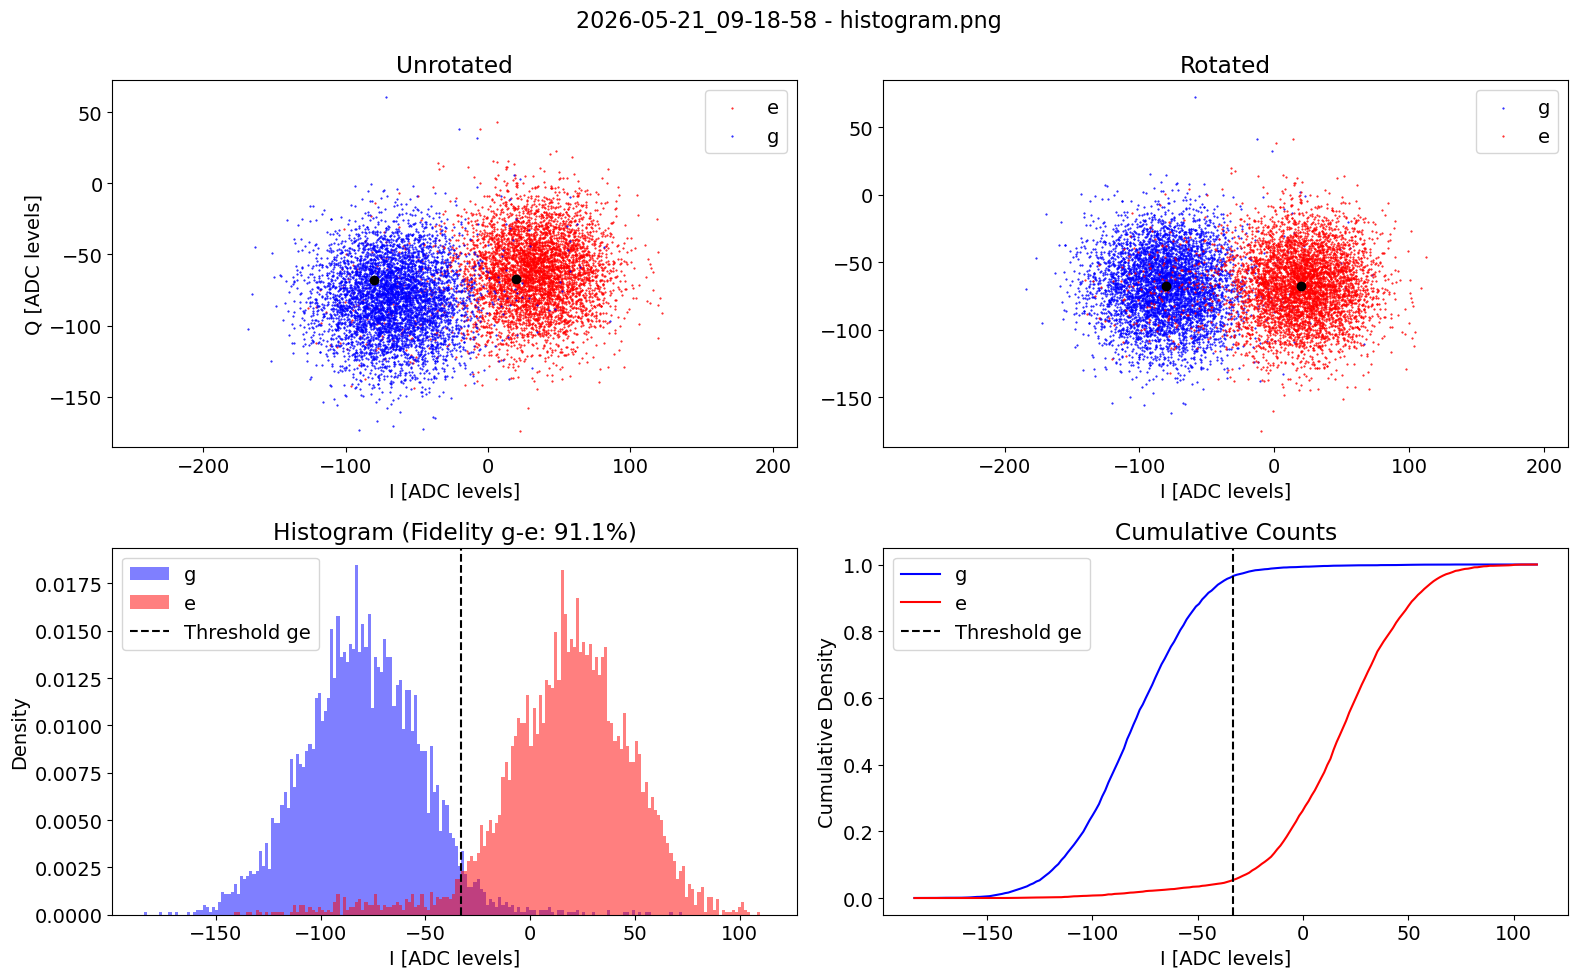

[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\Stark-induced sweet spot\2026\05\2026-05-21.md


In [29]:
single_shot_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

single_shot = single_shot_runner.execute(
        go_kwargs=dict(analyze=False, display=False),
        check_f=False,
        relax_delay=2000,
        pre_sweep_pulse=None,
        prepulse=False,
        gate_based=False,
        reps=5000,
        coupler_current=float(I_set_ma * 1e-3), 
    )

### Rabi

In [ ]:
coupler_rabi_expt = coupler_rabi_runner.execute(
    coupler_current=float(I_set_ma * 1e-3),
    f0g1_freq=f0g1_at_setpoint,
    start=0,
    step=350,
    expts=101,
    pulse_type='gauss',
    sigma=.035,
    freq=f_coupler_at_setpoint,
    reps=100,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
)

if USE_QUEUE:
    coupler_rabi_expt.analyze(fit=False)
    coupler_rabi_expt.display(fit=False)


### Length Rabi

Same setup as the amplitude Rabi above (same `f_coupler_at_setpoint`,
`f0g1_at_setpoint`, coupler current), but here we fix the gain and sweep
the pulse duration. Useful as a cross-check on `pi_gain` from the
amplitude Rabi -- a chevron of pi_time vs gain should be self-consistent
once both are fit.

In [ ]:
coupler_length_rabi_expt = coupler_length_rabi_runner.execute(
    coupler_current=float(I_set_ma * 1e-3),
    f0g1_freq=f0g1_at_setpoint,
    freq=f_coupler_at_setpoint,
    gain=20076,           # fill in from Rabi pi_gain or pick by hand
    start=0.05,
    step=0.02,            # length step [us]
    expts=101,
    pulse_type='gauss',
    reps=200,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
)

# if USE_QUEUE:
#     coupler_length_rabi_expt.analyze(fit=False)
#     coupler_length_rabi_expt.display(fit=False)


### T1 vs Rabi -- matched sigma sanity check

Apples-to-apples: at `tau=0` the T1 readout should equal the Rabi readout at
`gain == pi_gain`, provided both experiments use the **same drive frequency,
pulse shape, and sigma**. The `coupler_t1_runner` defaults leave `sigma=None`
(falls back to `pi_ge.sigma[0]`), so without explicit overrides the T1 and
the Rabi above will use *different* envelopes -- exactly the discrepancy we
want to rule out at suspect flux points.

Run the two cells below in order. The Rabi fit gives `pi_gain`; the T1 then
uses that gain at the same sigma. Compare T1 readout at `xpts[0]` against
the Rabi minimum (or maximum, depending on sign) at the fitted `pi_gain`.


In [ ]:


coupler_rabi_compare = coupler_rabi_runner.execute(
    coupler_current=float(I_set_ma * 1e-3),
    f0g1_freq=f0g1_at_setpoint,
    freq=f_coupler_at_setpoint,
    pulse_type=pulse_type,
    sigma=comparison_sigma,
    length=length,
    start=0, step=350, expts=101,
    reps=200, rounds=1,
    go_kwargs=dict(analyze=False, display=False),
)
if USE_QUEUE:
    coupler_rabi_compare.analyze(fit=True)
    coupler_rabi_compare.display(fit=True)

pi_gain_from_rabi = int(round(float(coupler_rabi_compare.data['pi_gain_avgi'])))
print(f'pi_gain from Rabi fit: {pi_gain_from_rabi} DAC  (sigma={comparison_sigma} us)')


In [ ]:
# 2) T1 at the SAME sigma and at gain = pi_gain_from_rabi.
#    At tau=0 the T1 readout should equal the Rabi readout near gain=pi_gain.
coupler_t1_compare = coupler_t1_runner.execute(
    coupler_current=float(I_set_ma * 1e-3),
    f0g1_freq=f0g1_at_setpoint,
    freq=f_coupler_at_setpoint,
    pulse_type='gauss',
    sigma=comparison_sigma,
    gain=20000,
    start=0.0, step=2.5, expts=101,
    reps=200, rounds=1,
    go_kwargs=dict(analyze=False, display=False),
)
if USE_QUEUE:
    coupler_t1_compare.analyze(fit=True)
    coupler_t1_compare.display(fit=True)

# Side-by-side contrast at the matched operating point.
import numpy as np
rabi_x = np.asarray(coupler_rabi_compare.data['xpts'])
rabi_i = np.asarray(coupler_rabi_compare.data['avgi'])
t1_x   = np.asarray(coupler_t1_compare.data['xpts'])
t1_i   = np.asarray(coupler_t1_compare.data['avgi'])
rabi_at_pigain = float(rabi_i[np.argmin(np.abs(rabi_x - pi_gain_from_rabi))])
rabi_baseline  = float(rabi_i[0])
t1_at_tau0     = float(t1_i[0])
t1_baseline    = float(t1_i[-1])  # long-tau plateau
print(f'Rabi:  baseline (gain~0)        = {rabi_baseline:.4f}  ADC')
print(f'Rabi:  readout at pi_gain       = {rabi_at_pigain:.4f}  ADC')
print(f'Rabi:  contrast |diff|          = {abs(rabi_at_pigain - rabi_baseline):.4f}')
print(f'T1:    tau=0 readout            = {t1_at_tau0:.4f}  ADC')
print(f'T1:    long-tau readout         = {t1_baseline:.4f}  ADC')
print(f'T1:    contrast |diff|          = {abs(t1_at_tau0 - t1_baseline):.4f}')


### Anharmonicity

Coupler spectroscopy with `coupler_f=True` plays a calibrated g→e pi pulse (from cell 47's matched-sigma Rabi: `pi_gain_from_rabi`, `length`) then probes around `f_ge` for the e→f peak. Anharmonicity = `f_ge - f_ef` in MHz. Self-contained: only needs Step 3's earlier cells (43, 45, 47).

In [ ]:
# Coupler spectroscopy with `coupler_f=True`: play a calibrated g->e pi pulse
# (using pi_gain_from_rabi at the matched sigma/length from cell 47) then sweep
# probe frequency around f_ge to find the e->f peak. Anharmonicity = f_ge - f_ef.
# Self-contained: only depends on Step 3 setup (cells 43, 45, 47).

f_band = 100.0   # +/- MHz around f_ge to scan for f_ef
f_step = 1.0     # MHz step
spec_probe_length_us = 10.0
gain = 2000
reps = 1000
rounds = 1

f0g1_here = float(f0g1_fine_func(I_set_ma))
f_ge = float(f_coupler_func(I_set_ma))

# Temporarily install the calibrated g->e pi pulse params; coupler_spec_runner
# with coupler_f=True reads these from hardware_cfg before the e->f probe.
# pi_ge_length is the const-pulse-equivalent duration (use Rabi `length` if the
# Rabi was a const pulse; otherwise use the gauss `t_eff` from the rabi fit).
pi_ge_cfg = station.hardware_cfg.device.coupler.pulses.pi_ge
saved_pi_ge = {k: pi_ge_cfg[k][0] for k in ('freq', 'length', 'gain') if k in pi_ge_cfg}
pi_ge_cfg.setdefault('freq', [0.0])[0] = f_ge
# pi_ge_cfg.setdefault('length', [0.0])[0] = float(length)            # from cell 47
pi_ge_cfg.setdefault('length', [0.0])[0] = float(0.5)            # from cell 47
# pi_ge_cfg.setdefault('gain', [0])[0] = int(pi_gain_from_rabi)       # from cell 47
pi_ge_cfg.setdefault('gain', [0])[0] = int(10000)       # from cell 47

try:
    nb_pts = int(np.round(2 * f_band / f_step)) + 1
    anharm_expt = coupler_spec_runner.execute(
        coupler_current=float(I_set_ma * 1e-3),
        f0g1_freq=f0g1_here,
        start=float(f_ge - f_band - 50.0),
        step=float(f_step),
        expts=int(nb_pts + int(50 / f_step)),
        length=float(spec_probe_length_us),
        gain=int(gain),
        reps=int(reps), rounds=int(rounds),
        coupler_f=False,
        relax_delay=100,
        go_kwargs=dict(analyze=False, display=False),
    )
finally:
    for k, v in saved_pi_ge.items():
        pi_ge_cfg[k][0] = v

# Fit a Lorentzian to the inverted spectrum to find f_ef.
freqs = np.asarray(anharm_expt.data['xpts'], dtype=float)
sig = np.asarray(anharm_expt.data['avgi'], dtype=float)
s = -sig
baseline = float(np.median(s))
amp0 = float(np.max(s) - baseline)
x00 = float(freqs[int(np.argmax(s - baseline))])
try:
    popt, _ = curve_fit(
        _lorentzian, freqs, s - baseline,
        p0=[amp0, x00, max(2 * f_step, (freqs[-1] - freqs[0]) / 20), 0.0],
        bounds=([0.0, freqs[0], f_step, -np.inf],
                [10 * amp0 + 1e-9, freqs[-1], freqs[-1] - freqs[0], np.inf]),
        maxfev=4000,
    )
    f_ef = float(popt[1])
except Exception as exc:
    print(f'Lorentzian fit failed: {type(exc).__name__}: {exc}')
    f_ef = float('nan')

anharmonicity = float(f_ge - f_ef) if np.isfinite(f_ef) else float('nan')

# Quick plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs, sig, '.-', ms=4)
if np.isfinite(f_ef):
    ax.axvline(f_ef, color='C1', lw=1.0, ls='--', label=f'f_ef = {f_ef:.3f} MHz')
ax.axvline(f_ge, color='C2', lw=1.0, ls=':', label=f'f_ge = {f_ge:.3f} MHz')
ax.set_xlabel('Probe freq (MHz)'); ax.set_ylabel('avgi')
ax.set_title(f'Coupler spec coupler_f=True  (I={I_set_ma:+.4f} mA)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'I_set_ma     = {I_set_ma:+.4f} mA')
print(f'  f_ge        = {f_ge:.4f} MHz')
print(f'  f_ef        = {f_ef:.4f} MHz')
print(f'  anharmonicity = {anharmonicity:+.4f} MHz')


#### Anharmonicity from spec-vs-gain (no `coupler_f` pi pulse)

2D sweep: outer = probe gain, inner = probe frequency. At low gain only the f_ge peak appears; as the gain increases, the f_ef line drives a second peak (two-photon at high power, or single-photon via residual thermal `|e⟩` population). Anharmonicity = `f_ge - f_ef`. Uses `coupler_spec_vs_gain_runner` from cell 13.

In [ ]:
# === 2D coupler spec: outer = probe gain, inner = probe freq (no coupler_f pulse) ===
# At higher gain, the f_ef line shows up alongside f_ge -> anharmonicity = f_ge - f_ef.
f_band = 100.0                  # +/- MHz around f_ge
f_step = 0.5                    # MHz
spec_probe_length_us = 5.0
gain_start, gain_stop, gain_npts = 200, 6000, 11
reps = 500
rounds = 1

f0g1_here = float(f0g1_fine_func(I_set_ma))
f_ge = float(f_coupler_func(I_set_ma))
nb_pts = int(np.round(2 * f_band / f_step)) + 1

mother = coupler_spec_vs_gain_runner.execute(
    coupler_current=float(I_set_ma * 1e-3),
    f0g1_freq=f0g1_here,
    sweep_start=float(gain_start),
    sweep_stop=float(gain_stop),
    sweep_npts=int(gain_npts),
    start=float(f_ge - 1.5*f_band),
    step=float(f_step),
    expts=int(nb_pts),
    length=float(spec_probe_length_us),
    reps=int(reps), rounds=int(rounds),
    coupler_f=False,
    relax_delay=300,
)


In [ ]:
gains = np.asarray(mother.data['gain_sweep'], dtype=float)
sig_2d = np.asarray(mother.data['avgi'], dtype=float)
xpts_2d = np.asarray(mother.data['xpts'], dtype=float)
if xpts_2d.ndim == 1:
    xpts_2d = np.broadcast_to(xpts_2d, sig_2d.shape).copy()
freqs = xpts_2d[0]


def _fit_lor(x, y, fstep, sign=None):
    """Fit Lorentzian to a 1D row. Auto-detects peak sign (up vs down) by
    comparing |max-median| against |median-min| if sign is None.
    Returns (center, hwhm, sign) — center is nan on failure."""
    y = np.asarray(y, dtype=float)
    med = float(np.median(y))
    if sign is None:
        sign = 1 if (np.max(y) - med) >= (med - np.min(y)) else -1
    s = sign * (y - med)               # peaks-up, baseline near 0
    amp0 = float(np.max(s))
    if not np.isfinite(amp0) or amp0 <= 0:
        return float('nan'), float('nan'), sign
    x0_guess = float(x[int(np.argmax(s))])
    try:
        popt, _ = curve_fit(
            _lorentzian, x, s,
            p0=[amp0, x0_guess, max(2 * fstep, (x[-1] - x[0]) / 30), 0.0],
            bounds=([0.0, x[0], fstep, -np.inf],
                    [10 * amp0 + 1e-9, x[-1], x[-1] - x[0], np.inf]),
            maxfev=4000,
        )
        return float(popt[1]), float(abs(popt[2])), sign
    except Exception:
        return float('nan'), float('nan'), sign


# --- f_ge from the lowest-gain row (clean, not power-broadened) ---
f_ge_fit, gamma_ge, sgn = _fit_lor(freqs, sig_2d[0], f_step)
print(f'  detected peak sign = {sgn:+d}  (f_ge fit at lowest gain)')
if not np.isfinite(f_ge_fit):
    print('  f_ge fit failed; falling back to lookup f_ge.')
    f_ge_fit = f_ge

# --- Per-slice two-photon peak: mask +/- 15 MHz around f_ge_fit, reuse sign ---
ef_mask_halfwidth = 10.0  # MHz
keep = np.abs(freqs - f_ge_fit) > ef_mask_halfwidth
f_2ph_per_slice = np.full(len(gains), np.nan)
for i, row in enumerate(sig_2d):
    if not np.any(keep):
        continue
    fc, _, _ = _fit_lor(freqs[keep], row[keep], f_step, sign=sgn)
    f_2ph_per_slice[i] = fc

# Two-photon peak sits at (f_ge + f_ef)/2  =>  f_ef = 2*f_2ph - f_ge
f_ef_per_slice  = 2.0 * f_2ph_per_slice - f_ge_fit
anharm_per_slice = f_ge_fit - f_ef_per_slice                # = 2*(f_ge - f_2ph)

# "Best" estimate from top gain
f_2ph = float(f_2ph_per_slice[-1])
f_ef = float(f_ef_per_slice[-1])
anharmonicity = float(anharm_per_slice[-1])



# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

ax = axes[0]
extent = (freqs[0], freqs[-1], gains[0], gains[-1])
ax.imshow(sig_2d, aspect='auto', origin='lower', extent=extent, cmap='viridis')
ax.axvline(f_ge_fit, color='C2', lw=1.0, ls=':',
           label=f'f_ge = {f_ge_fit:.2f} MHz')
ax.axvline(f_ge_fit - ef_mask_halfwidth, color='w', lw=0.5, ls='--', alpha=0.5)
ax.axvline(f_ge_fit + ef_mask_halfwidth, color='w', lw=0.5, ls='--', alpha=0.5)
good = np.isfinite(f_ef_per_slice)
if np.any(good):
    ax.plot(f_2ph_per_slice[good], gains[good], 'o', color='C1', ms=5,
            label=f'f_2ph per slice (top: {f_2ph:.2f} MHz)')
ax.set_xlabel('Probe freq (MHz)'); ax.set_ylabel('Probe gain (DAC)')
ax.set_title(f'Spec vs gain  (I={I_set_ma:+.4f} mA)')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
slice_idx = (0, len(gains) // 2, len(gains) - 1)
colors = ['C0', 'C3', 'C4']
for j, c in zip(slice_idx, colors):
    ax.plot(freqs, sig_2d[j], '.-', ms=3, color=c, label=f'gain={gains[j]:.0f}')
    if np.isfinite(f_2ph_per_slice[j]):
        ax.axvline(f_2ph_per_slice[j], color=c, lw=0.8, ls='--', alpha=0.7,
                   label=f'f_2ph@{gains[j]:.0f} = {f_2ph_per_slice[j]:.2f}')

ax.axvline(f_ge_fit, color='C2', lw=1.0, ls=':', label=f'f_ge = {f_ge_fit:.2f}')
ax.axvspan(f_ge_fit - ef_mask_halfwidth, f_ge_fit + ef_mask_halfwidth,
           color='gray', alpha=0.08, label=f'masked (+/- {ef_mask_halfwidth:.0f} MHz)')
ax.set_xlabel('Probe freq (MHz)'); ax.set_ylabel('avgi')
ax.set_title('Slices (low/mid/top gain)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.show()

print(f'I_set_ma     = {I_set_ma:+.4f} mA')
print(f'  f_ge (fit lowest gain)  = {f_ge_fit:.4f} MHz   (HWHM ~ {gamma_ge:.2f} MHz)')
print(f'  per-slice 2-photon peak -> f_ef -> anharm:')
for g, fp, fef, a in zip(gains, f_2ph_per_slice, f_ef_per_slice, anharm_per_slice):
    print(f'    gain={g:8.0f}  f_2ph={fp:.4f}  f_ef={fef:.4f}  anharm={a:+.3f} MHz')
print(f'  anharmonicity (top gain) = {anharmonicity:+.4f} MHz')


### Ramsey

Coupler Ramsey at `I_set_ma` using the Rabi-calibrated pi/2 from cell 47 (`pi_gain_from_rabi`, `comparison_sigma`, `length`, `pulse_type`). Half-pi gain is `pi_gain_from_rabi // 2` (linear with DAC). `ramsey_freq` is the virtual phase detune in MHz; the fit returns the actual oscillation frequency, whose offset from `ramsey_freq` is the real detuning of the drive from `f_ge`.

In [ ]:
# Coupler Ramsey at the set current using the matched-sigma Rabi calibration.
# hpi_gain = int(6000)
# hpi_gain = int(20076)
hpi_gain = int(10929)

# hpi_gain = int(1)
length =0.035
# ramsey_freq = 9.54771194803748 + 25   # MHz virtual detuning
# ramsey_freq = 10  # MHz virtual detuning
ramsey_freq = 5  # MHz virtual detuning
pulse_type = 'gauss' 

coupler_ramsey_expt = coupler_ramsey_runner.execute(
    coupler_current=float(I_set_ma * 1e-3),
    f0g1_freq=f0g1_at_setpoint,
    freq=4687.41694692822,
    pulse_type=pulse_type,
    sigma=length,
    length=length,
    gain=int(hpi_gain),
    ramsey_freq=float(ramsey_freq),
    start=0.0,
    step=0.01,
    # step=0.025,
    expts=50,
    reps=100,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    echoes=2
)
# if USE_QUEUE:
#     coupler_ramsey_expt.analyze(fit=True)
#     coupler_ramsey_expt.display(fit=True)

# p = coupler_ramsey_expt.data.get('fit_avgi')
# if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
#     T2_us = float(p[3])
#     fit_freq_MHz = float(p[1])
#     print(f'I_set_ma     = {I_set_ma:+.4f} mA')
#     print(f'  hpi_gain            = {hpi_gain} DAC  (pulse_type={pulse_type}, sigma={comparison_sigma}, length={length})')
#     print(f'  T2 (ramsey)         = {T2_us:.2f} us')
#     print(f'  fit freq            = {fit_freq_MHz:.4f} MHz   (virtual detune = {ramsey_freq:.3f} MHz)')
#     print(f'  detuning from f_ge  = {fit_freq_MHz - ramsey_freq:+.4f} MHz')
# else:
#     print('Ramsey fit not available; check expt.data')
# # --- Optional: persist this T2_long to the per-current pickle entry for I_set_ma. ---
# # Step 3 is the manual "run only Ramsey" path: the hpi_gain / length / ramsey_freq
# # above are hand-tuned, no Rabi calibration required. When the fit looks good, set
# # save_T2_long = True and the per-current pickle entry gains T2_long / T2_long_us.
# save_T2_long = True
# if save_T2_long and isinstance(p, (list, np.ndarray)) and len(p) >= 4:
#     T2_long_record = dict(
#         T2_ramsey_us=T2_us,
#         ramsey_freq_offset_MHz=fit_freq_MHz - ramsey_freq,
#         ramsey_freq_MHz=float(ramsey_freq),
#         hpi_gain=int(hpi_gain),
#         hpi_pulse_dur=float(length),
#         pulse_type=pulse_type,
#         sigma=float(comparison_sigma),
#         fname=getattr(coupler_ramsey_expt, 'fname', None),
#     )
#     pickle_save_per_current(LOOKUP_PATH, I_set_ma,
#                             T2_long=T2_long_record, T2_long_us=float(T2_us))
#     print(f'  Saved T2_long = {T2_us:.2f} us to pickle for I_set_ma={I_set_ma:+.4f}')


In [ ]:
print('fit avgi', coupler_ramsey_expt.data.get('fit_avgi'))
print('avgi', coupler_ramsey_expt.data.get('avgi'))

In [ ]:
p = coupler_ramsey_expt.data.get('fit_avgi')
if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
    T2_us = float(p[3])
    fit_freq_MHz = float(p[1])
    print(f'I_set_ma     = {I_set_ma:+.4f} mA')
    print(f'  hpi_gain            = {hpi_gain} DAC  (pulse_type={pulse_type}, sigma={comparison_sigma}, length={length})')
    print(f'  T2 (ramsey)         = {T2_us:.2f} us')
    print(f'  fit freq            = {fit_freq_MHz:.4f} MHz   (virtual detune = {ramsey_freq:.3f} MHz)')
    print(f'  detuning from f_ge  = {fit_freq_MHz - ramsey_freq:+.4f} MHz')
else:
    print('Ramsey fit not available; check expt.data')
# --- Optional: persist this T2_long to the per-current pickle entry for I_set_ma. ---
# Step 3 is the manual "run only Ramsey" path: the hpi_gain / length / ramsey_freq
# above are hand-tuned, no Rabi calibration required. When the fit looks good, set
# save_T2_long = True and the per-current pickle entry gains T2_long / T2_long_us.
save_T2_long = True
if save_T2_long and isinstance(p, (list, np.ndarray)) and len(p) >= 4:
    T2_long_record = dict(
        T2_ramsey_us=T2_us,
        ramsey_freq_offset_MHz=fit_freq_MHz - ramsey_freq,
        ramsey_freq_MHz=float(ramsey_freq),
        hpi_gain=int(hpi_gain),
        hpi_pulse_dur=float(length),
        pulse_type=pulse_type,
        sigma=float(comparison_sigma),
        fname=getattr(coupler_ramsey_expt, 'fname', None),
    )
    pickle_save_per_current(LOOKUP_PATH, I_set_ma,
                            T2_long=T2_long_record, T2_long_us=float(T2_us))
    print(f'  Saved T2_long = {T2_us:.2f} us to pickle for I_set_ma={I_set_ma:+.4f}')

## Step 4 -- Per-current coupler characterization

For a chosen current set point `I_set_mA`, run a full coupler characterization:

- **T1**: `T1CouplerExperiment` (already exists), with `f0g1_freq` override now patched in.
- **Amplitude Rabi** at the set point: gives the Rabi rate per DAC unit (`k`) **and** acts as a regime detector via the standard `fitdecaysin` model — if the swept gain window contains less than `min_oscillations` Rabi periods before the decay envelope kills the oscillation, we declare short-T2.
- **Long-T2 path** (clean Rabi): standard Ramsey with the calibrated pi/2 from the Rabi fit; optional anharmonicity via coupler spectroscopy with `coupler_f=True`.
- **Short-T2 path** (Rabi can't separate `k` from `T2`): joint extraction from
  - coupler spectroscopy vs power (FWHM^2 vs A^2 linearization) — gives `T2` (T1-independent intercept) and `k` (slope, requires `T1`),
  - amplitude Rabi at several pulse-length / sigma values (Torrey global fit) — independent estimate of `(k, T2)`,
  - then `combine_short_T2(...)` cross-checks the two.

Branching is automatic by default but overridable via `regime_override='auto'|'long_T2'|'short_T2'` for unstable fits. Each step writes its results to the lookup pickle as soon as it completes (`pickle_save_per_current(...)`), so a kernel crash mid-loop preserves all completed entries.

In [ ]:
# --- Per-step characterization functions ---
# Each takes I_set_mA, derives f0g1 / f_coupler from the lookup tables, runs
# its underlying experiment, fits the result, and returns a small dict.

from scipy.special import erf as _erf


def _gauss_t_eff(sigma_us):
    """Effective drive time for the qick Gaussian envelope, length = 4*sigma.

    qick add_gauss (GAUSS_BUG=True, tProc v1) emits exp(-t^2 / sigma^2),
    not the standard exp(-t^2 / (2*sigma^2)). Truncated at +-2*sigma:
        t_eff = sigma * sqrt(pi) * erf(2)   ~= 1.7642 * sigma.
    """
    return float(sigma_us) * np.sqrt(np.pi) * _erf(2.0)


def _expt_fname(expt):
    return getattr(expt, 'fname', None)


def characterize_t1(I_set_mA, **overrides):
    """Coupler T1 at the chosen current. Returns {T1_us, T1_err_us, fname}."""
    f0g1_here = float(f0g1_fine_func(I_set_mA))
    f_coupler_here = float(f_coupler_func(I_set_mA))
    expt = coupler_t1_runner.execute(
        coupler_current=float(I_set_mA * 1e-3),
        f0g1_freq=f0g1_here,
        freq=f_coupler_here,
        **overrides,
    )
    p = expt.data.get('fit_avgi')
    pCov = expt.data.get('fit_err_avgi')
    if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
        T1 = float(p[3])
        T1_err = float(np.sqrt(pCov[3][3])) if pCov is not None else float('nan')
    else:
        T1, T1_err = float('nan'), float('nan')
    return dict(T1_us=T1, T1_err_us=T1_err, fname=_expt_fname(expt))


def _run_amp_rabi(I_set_mA, *, pulse_type='gauss', sigma=0.5, length=5.0,
                  **overrides):
    """Single amp Rabi run + fit. Returns the underlying expt (with .data populated).

    Default pulse_type='gauss' with sigma=0.5 us (envelope length = 4*sigma =
    2 us ~ 12k DAC samples). Combined with the f0-g{man_no} swap envelope on
    the same manipulate channel, the cumulative buffer must stay under 32768
    samples; sigmas above ~1.0 us start to risk overflow depending on the
    f0g1 swap length at the current set point.
    """
    f0g1_here = float(f0g1_fine_func(I_set_mA))
    f_coupler_here = float(f_coupler_func(I_set_mA))
    if pulse_type == 'gauss':
        pulse_kw = dict(sigma=float(sigma))
    else:
        pulse_kw = dict(length=float(length))
    expt = coupler_rabi_runner.execute(
        coupler_current=float(I_set_mA * 1e-3),
        f0g1_freq=f0g1_here,
        freq=f_coupler_here,
        pulse_type=pulse_type,
        **pulse_kw,
        **overrides,
    )
    if 'fit_avgi' not in expt.data:
        expt.analyze(fit=True)
    return expt


def _summarize_rabi(expt, *, pulse_type='gauss', sigma=None, length=None):
    """Pack a fit-summary dict from a completed Rabi experiment."""
    p = expt.data.get('fit_avgi')
    pCov = expt.data.get('fit_err_avgi')
    pi_gain = float(expt.data.get('pi_gain_avgi', np.nan))
    hpi_gain = float(expt.data.get('hpi_gain_avgi', np.nan))
    if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
        rabi_freq = float(p[1])
        decay_dac = float(p[3])
    else:
        rabi_freq, decay_dac = float('nan'), float('nan')
    if pulse_type == 'gauss':
        t_eff = _gauss_t_eff(sigma) if sigma is not None else float('nan')
    else:
        t_eff = float(length) if length is not None else float('nan')
    return dict(
        pi_gain=pi_gain,
        hpi_gain=hpi_gain,
        rabi_freq_per_DAC=rabi_freq,
        decay_DAC=decay_dac,
        sigma=float(sigma) if sigma is not None else None,
        length=float(length) if length is not None else None,
        pulse_type=pulse_type,
        t_eff_us=float(t_eff),
        fit_avgi=np.asarray(p, dtype=float).tolist() if p is not None else None,
        fit_err_avgi=np.asarray(pCov, dtype=float).tolist() if pCov is not None else None,
        fname=_expt_fname(expt),
    )


def characterize_amp_rabi(I_set_mA, *, pulse_type='gauss', sigma=0.5, length=5.0,
                          **overrides):
    """Coupler amplitude Rabi at the set current.

    Default pulse_type='gauss', sigma=0.5 us. Keep sigma small enough that
    the Rabi envelope (4*sigma) plus the f0-g{man_no} swap envelope fits in
    the 32768-sample manipulate-channel buffer (sigma <= ~1 us is generally
    safe).
    """
    expt = _run_amp_rabi(I_set_mA, pulse_type=pulse_type,
                         sigma=sigma, length=length, **overrides)
    return _summarize_rabi(expt, pulse_type=pulse_type,
                           sigma=sigma, length=length)


def decide_T2_regime(rabi_result, *, min_oscillations=1.0):
    """Heuristic regime detector from a single Rabi fit.

    Long-T2 iff decay_DAC >= min_oscillations * (1 / rabi_freq_per_DAC).
    Otherwise short-T2.
    """
    freq = rabi_result.get('rabi_freq_per_DAC', float('nan'))
    decay = rabi_result.get('decay_DAC', float('nan'))
    if not (np.isfinite(freq) and np.isfinite(decay)) or freq <= 0 or decay <= 0:
        return 'short_T2'
    period = 1.0 / freq
    return 'long_T2' if decay >= min_oscillations * period else 'short_T2'


def characterize_t2_ramsey(I_set_mA, *, hpi_gain, hpi_pulse_dur,
                           pulse_type='gauss', ramsey_freq=2.0, **overrides):
    """Coupler Ramsey using the Rabi-calibrated pi/2.

    `hpi_pulse_dur` is the duration in us; sigma if pulse_type='gauss',
    length if pulse_type='const'. Pass the value that matches the Rabi
    calibration so the same hpi_gain produces a true pi/2 rotation.
    """
    f0g1_here = float(f0g1_fine_func(I_set_mA))
    f_coupler_here = float(f_coupler_func(I_set_mA))
    pulse_kw = (dict(sigma=float(hpi_pulse_dur)) if pulse_type == 'gauss'
                else dict(length=float(hpi_pulse_dur)))
    expt = coupler_ramsey_runner.execute(
        coupler_current=float(I_set_mA * 1e-3),
        f0g1_freq=f0g1_here,
        freq=f_coupler_here,
        gain=int(hpi_gain),
        pulse_type=pulse_type,
        **pulse_kw,
        ramsey_freq=float(ramsey_freq),
        **overrides,
    )
    p = expt.data.get('fit_avgi')
    pCov = expt.data.get('fit_err_avgi')
    if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
        T2 = float(p[3])
        ramsey_offset = float(p[1])
        try:
            T2_err = (float(np.sqrt(pCov[3][3]))
                      if pCov is not None else float('nan'))
            ramsey_offset_err = (float(np.sqrt(pCov[1][1]))
                                 if pCov is not None else float('nan'))
        except Exception:
            T2_err, ramsey_offset_err = float('nan'), float('nan')
    else:
        T2, ramsey_offset = float('nan'), float('nan')
        T2_err, ramsey_offset_err = float('nan'), float('nan')
    return dict(T2_ramsey_us=T2, T2_ramsey_err_us=T2_err,
                ramsey_freq_offset_MHz=ramsey_offset,
                ramsey_freq_offset_err_MHz=ramsey_offset_err,
                fname=_expt_fname(expt))


def _fit_lorentzian_row(freqs, signal, *, sign='auto'):
    """Per-row Lorentzian fit using fitter.fitlor (matches T2 notebook).

    Returns (popt, sign_used) where popt = [y0, yscale, x0, xscale]
    (xscale is HWHM, signed). FWHM = 2 * abs(popt[3]); center = popt[2].
    `sign='auto'` flips data so the peak is positive before fitting.
    """
    import fitting.fitting as _fitter
    freqs = np.asarray(freqs, dtype=float)
    signal = np.asarray(signal, dtype=float)
    if sign == 'auto':
        sign_used = (-1 if (signal.max() - signal.mean())
                          < (signal.mean() - signal.min()) else 1)
    else:
        sign_used = int(sign)
    popt, _ = _fitter.fitlor(freqs, sign_used * signal)
    return np.asarray(popt, dtype=float), int(sign_used)


def _mad_outlier_mask(values, *, thresh=3.0):
    """Boolean inlier mask via median absolute deviation. thresh in MADs.

    Returns all-True if std(values) is degenerate or thresh is None.
    """
    if thresh is None:
        return np.ones_like(values, dtype=bool)
    v = np.asarray(values, dtype=float)
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    if mad <= 0 or not np.isfinite(mad):
        return np.ones_like(v, dtype=bool)
    # 1.4826 scales MAD to a Gaussian-equivalent sigma.
    return np.abs(v - med) <= thresh * 1.4826 * mad


def _linearize_fwhm_vs_gain(gains, fwhms, T1_us, *, outlier_thresh_mad=3.0):
    """FWHM^2 = b + m*A^2 fit with optional MAD outlier rejection.

    Returns dict with T2_us, k_per_DAC, FWHM_intercept (b), FWHM_slope (m),
    inlier_mask, residuals, T1_us.
    """
    gains = np.asarray(gains, dtype=float)
    fwhms = np.asarray(fwhms, dtype=float)
    finite = np.isfinite(fwhms) & (gains > 0)
    A2 = gains[finite] ** 2
    y = fwhms[finite] ** 2

    inlier_mask_full = np.zeros_like(gains, dtype=bool)
    nan_result = dict(T2_us=float('nan'), k_per_DAC=float('nan'),
                      FWHM_intercept=float('nan'), FWHM_slope=float('nan'),
                      inlier_mask=inlier_mask_full.tolist(),
                      residuals=[float('nan')] * len(gains))

    if A2.size < 3:
        return nan_result

    # Initial linear fit, then drop outliers in residual space.
    m0, b0 = np.polyfit(A2, y, 1)
    res = y - (m0 * A2 + b0)
    inlier = _mad_outlier_mask(res, thresh=outlier_thresh_mad)
    if inlier.sum() < 3:
        # Too few inliers -- keep all points.
        inlier = np.ones_like(res, dtype=bool)

    m, b = np.polyfit(A2[inlier], y[inlier], 1)
    if not (np.isfinite(b) and b > 0):
        return nan_result
    T2_us = 1.0 / (np.pi * np.sqrt(b))
    if (T1_us is not None and np.isfinite(T1_us) and T1_us > 0
            and m > 0):
        k = float(np.sqrt(np.pi / T1_us) * np.sqrt(m) * b ** (-0.25))
    else:
        k = float('nan')

    inlier_mask_full[finite] = inlier
    residuals_full = np.full_like(gains, np.nan)
    residuals_full[finite] = y - (m * A2 + b)

    return dict(T2_us=float(T2_us), k_per_DAC=k,
                FWHM_intercept=float(b), FWHM_slope=float(m),
                inlier_mask=inlier_mask_full.tolist(),
                residuals=residuals_full.tolist())


def _plot_per_gain_lorentzians(xpts_2d, sig_2d, gains, lor_params, signs,
                                 *, channel='avgi'):
    """Grid of subplots, one per gain, with the data and Lorentzian fit overlay."""
    import fitting.fitting as _fitter
    n = len(gains)
    if n == 0:
        return
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(4 * ncols, 3 * nrows), squeeze=False)
    for i, (x, y, g) in enumerate(zip(xpts_2d, sig_2d, gains)):
        ax = axes[i // ncols, i % ncols]
        ax.plot(x, y, 'o', ms=3, label='data')
        p = lor_params[i]
        if p is not None and all(np.isfinite(p)):
            xf = np.linspace(float(np.min(x)), float(np.max(x)), 400)
            ax.plot(xf, signs[i] * _fitter.lorfunc(xf, *p), '-',
                    label=f'x0={p[2]:.3f}, HWHM={abs(p[3]):.3f}')
        ax.set_title(f'gain = {g:.0f}')
        ax.set_xlabel('freq [MHz]')
        ax.set_ylabel(channel)
        ax.legend(fontsize=8)
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].set_visible(False)
    plt.tight_layout()
    plt.show()


def _plot_spec_summary(gains, fwhms, centers, inlier_mask, b, m,
                        T2_us, k, I_set_mA):
    """FWHM(gain), Lorentzian center(gain), and FWHM^2 vs A^2 with inlier/outlier markers."""
    inlier_mask = np.asarray(inlier_mask, dtype=bool)
    gains = np.asarray(gains, dtype=float)
    fwhms = np.asarray(fwhms, dtype=float)
    centers = np.asarray(centers, dtype=float)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(gains, centers, 'o-')
    axes[0].set_xlabel('gain [DAC]'); axes[0].set_ylabel('center [MHz]')
    axes[0].set_title(f'I = {I_set_mA:+.4f} mA  Lorentzian center')
    axes[0].grid(alpha=0.3)

    axes[1].plot(gains, fwhms, 'o-', label='all')
    if (~inlier_mask).any():
        axes[1].plot(gains[~inlier_mask], fwhms[~inlier_mask], 'rx', ms=10,
                     label='outlier')
    axes[1].set_xlabel('gain [DAC]'); axes[1].set_ylabel('FWHM [MHz]')
    axes[1].set_title('FWHM(gain)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    A2 = gains ** 2
    y = fwhms ** 2
    in_finite = inlier_mask & np.isfinite(y)
    axes[2].plot(A2[in_finite], y[in_finite], 'o', label='inlier')
    if (~inlier_mask & np.isfinite(y)).any():
        axes[2].plot(A2[~inlier_mask & np.isfinite(y)],
                     y[~inlier_mask & np.isfinite(y)], 'rx', ms=10,
                     label='outlier')
    if np.isfinite(b) and np.isfinite(m):
        A2_line = np.linspace(0, float(A2.max()) * 1.05, 100)
        axes[2].plot(A2_line, m * A2_line + b, '-',
                     label=f'fit: b={b:.3g}, m={m:.3g}')
    axes[2].set_xlabel(r'gain$^2$ [DAC$^2$]')
    axes[2].set_ylabel(r'FWHM$^2$ [MHz$^2$]')
    title = (f'T2 = {T2_us:.2f} us, k = {k:.3e}'
             if np.isfinite(k) else f'T2 = {T2_us:.2f} us, k = nan')
    axes[2].set_title(title)
    axes[2].legend(); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig

# Override the original spec-vs-power helper with the two-pass refit.

def characterize_spec_vs_power(I_set_mA, *, T1_us,
                               gain_start=500, gain_stop=1200, gain_npts=5,
                               f_band=80.0, f_step=0.8,
                               length=50.0, reps=400, rounds=1,
                               sign='auto',
                               outlier_thresh_mad=3.0,
                               sat_frac=0.90,
                               show_per_gain_plots=True,
                               show_summary_plot=True,
                               log_measurement=True,
                               **overrides):
    """Coupler spectroscopy vs probe gain for the short-T2 branch.

    Per-gain Lorentzian fits are done in two passes:
    first pass to detect saturation from fitted amplitudes, then a second pass
    that re-fits only the pre-saturation rows with mean-based initial guesses.
    """
    f0g1_here = float(f0g1_fine_func(I_set_mA))
    f_coupler_here = float(f_coupler_func(I_set_mA))
    nb_pts = int(np.round(2 * f_band / f_step)) + 1

    mother = coupler_spec_vs_gain_runner.execute(
        coupler_current=float(I_set_mA * 1e-3),
        f0g1_freq=f0g1_here,
        sweep_start=float(gain_start), sweep_stop=float(gain_stop),
        sweep_npts=int(gain_npts),
        start=float(f_coupler_here - f_band),
        step=float(f_step),
        expts=int(nb_pts),
        length=float(length),
        reps=int(reps), rounds=int(rounds),
        coupler_f=False,
        **overrides,
    )

    gains = np.asarray(mother.data.get('gain_sweep', []), dtype=float)
    sig_2d = np.asarray(mother.data['avgi'], dtype=float)
    xpts_2d = np.asarray(mother.data['xpts'], dtype=float)
    if xpts_2d.ndim == 1:
        xpts_2d = np.broadcast_to(xpts_2d, sig_2d.shape).copy()

    import fitting.fitting as _fitter

    fwhms = np.full(len(gains), np.nan)
    centers = np.full(len(gains), np.nan)
    lor_params = [None] * len(gains)
    signs = [0] * len(gains)
    amps = np.full(len(gains), np.nan)

    for i, (x_row, row, g) in enumerate(zip(xpts_2d, sig_2d, gains)):
        try:
            popt, s_used = _fit_lorentzian_row(x_row, row, sign=sign)
            lor_params[i] = popt
            signs[i] = s_used
            centers[i] = float(popt[2])
            fwhms[i] = 2 * abs(float(popt[3]))
            amps[i] = float(popt[1])
        except Exception as e:
            print(f'[I={I_set_mA:+.4f}] Lor fit failed at gain={g:.0f}: '
                  f'{type(e).__name__}: {e}')

    if np.all(~np.isfinite(amps)):
        pre_idx = np.arange(len(gains))
    else:
        amax = np.nanmax(amps)
        if not np.isfinite(amax) or amax == 0:
            pre_idx = np.arange(len(gains))
        else:
            sat_mask = amps >= (sat_frac * amax)
            if sat_mask.any():
                first_sat = int(np.where(sat_mask)[0][0])
                pre_idx = np.arange(0, first_sat)
                if pre_idx.size == 0:
                    pre_idx = np.arange(len(gains))
            else:
                pre_idx = np.arange(len(gains))

    valid = np.array([p is not None for p in lor_params])
    pre_valid = np.intersect1d(pre_idx, np.where(valid)[0])

    if pre_valid.size > 0:
        mean_y0 = float(np.nanmean([lor_params[i][0] for i in pre_valid]))
        mean_amp = float(np.nanmean([lor_params[i][1] for i in pre_valid]))
        mean_center = float(np.nanmean([lor_params[i][2] for i in pre_valid]))
        mean_hwhm = float(np.nanmean([abs(lor_params[i][3]) for i in pre_valid]))
    else:
        mean_y0 = np.nanmedian(sig_2d)
        mean_amp = np.nanmax(sig_2d) - np.nanmin(sig_2d)
        mean_center = np.nanmean(xpts_2d)
        mean_hwhm = (np.nanmax(xpts_2d) - np.nanmin(xpts_2d)) / 10.0

    for i in pre_idx:
        x_row = xpts_2d[i]
        row = sig_2d[i]
        try:
            init = [mean_y0, mean_amp, mean_center, mean_hwhm]
            popt, pcov = _fitter.fitlor(x_row, (signs[i] if signs[i] else 1) * row, fitparams=init)
            lor_params[i] = np.asarray(popt, dtype=float)
            centers[i] = float(popt[2])
            fwhms[i] = 2 * abs(float(popt[3]))
            amps[i] = float(popt[1])
            signs[i] = int(signs[i] or 1)
        except Exception:
            pass

    if show_per_gain_plots:
        _plot_per_gain_lorentzians(xpts_2d, sig_2d, gains, lor_params, signs)

    lin = _linearize_fwhm_vs_gain(gains, fwhms, T1_us,
                                  outlier_thresh_mad=outlier_thresh_mad)

    fig_summary = None
    if show_summary_plot:
        fig_summary = _plot_spec_summary(gains, fwhms, centers, lin['inlier_mask'],
                                         lin['FWHM_intercept'], lin['FWHM_slope'],
                                         lin['T2_us'], lin['k_per_DAC'], I_set_mA)

    if log_measurement and fig_summary is not None:
        try:
            station.log_measurement(
                fig=fig_summary,
                title=f'Spec-vs-power (two-pass)  I={I_set_mA:+.4f} mA',
                notes=('Two-pass per-gain Lorentzian: first-pass fits detect saturation, '
                       'then pre-saturation rows are re-fit with mean-based init guesses. '
                       'T2 from intercept (T1-independent), k from slope (uses T1).'),
                parameters={
                    'I_mA': float(I_set_mA),
                    'f0g1_MHz': float(f0g1_here),
                    'f_coupler_MHz': float(f_coupler_here),
                    'gain_start': float(gain_start),
                    'gain_stop': float(gain_stop),
                    'gain_npts': int(gain_npts),
                    'length_us': float(length),
                    'reps': int(reps),
                    'rounds': int(rounds),
                    'T1_us_used': (float(T1_us) if T1_us is not None else None),
                    'outlier_thresh_mad': outlier_thresh_mad,
                    'sat_frac': sat_frac,
                    'T2_us': float(lin['T2_us']),
                    'k_per_DAC': float(lin['k_per_DAC']),
                    'FWHM_intercept': float(lin['FWHM_intercept']),
                    'FWHM_slope': float(lin['FWHM_slope']),
                    'gains_DAC': [float(g) for g in gains.tolist()],
                    'FWHMs_MHz': [float(v) for v in fwhms.tolist()],
                    'fname': _expt_fname(mother),
                },
            )
        except Exception as _e:
            print(f'[log_measurement] spec_vs_power failed: {_e!r}')

    return dict(
        T2_us=lin['T2_us'],
        k_per_DAC=lin['k_per_DAC'],
        FWHM_intercept=lin['FWHM_intercept'],
        FWHM_slope=lin['FWHM_slope'],
        gains=gains.tolist(),
        FWHMs=fwhms.tolist(),
        centers=centers.tolist(),
        lor_params=[None if p is None else p.tolist() for p in lor_params],
        signs=signs,
        inlier_mask=lin['inlier_mask'],
        residuals=lin['residuals'],
        T1_us_used=float(T1_us) if T1_us is not None else None,
        outlier_thresh_mad=outlier_thresh_mad,
        sat_frac=sat_frac,
        xpts_2d=xpts_2d.tolist(),
        signal_2d=sig_2d.tolist(),
        fname=_expt_fname(mother),
    )

# def characterize_spec_vs_power(I_set_mA, *, T1_us,
#                                 gain_start=500, gain_stop=1200, gain_npts=5,
#                                 f_band=80.0, f_step=0.8,
#                                 length=50.0, reps=400, rounds=1,
#                                 sign='auto',
#                                 outlier_thresh_mad=3.0,
#                                 show_per_gain_plots=True,
#                                 show_summary_plot=True,
#                                 log_measurement=True,
#                                 **overrides):
#     """Coupler spectroscopy vs probe gain for the short-T2 branch.

#     Per-gain Lorentzian fit (via fitter.fitlor, matching the T2 notebook)
#     -> FWHM(A)^2 = b + m*A^2 linearization with MAD-based outlier rejection:
#         T2 = 1 / (pi * sqrt(b))                 (T1-independent intercept)
#         k  = sqrt(pi/T1) * sqrt(m) * b^(-1/4)   (slope, requires T1)

#     `sign='auto'|+1|-1`: flip the row before Lorentzian fit (auto-detected
#     by whether the peak is on top or bottom).
#     `outlier_thresh_mad`: drop points whose FWHM^2 vs A^2 residual is more
#     than this many scaled-MADs from a tentative line. Set to None to disable.
#     `show_per_gain_plots`: grid of per-gain Lorentzian overlays (default True).
#     `show_summary_plot`: 3-panel summary of FWHM, center, and linearization.

#     Saves the raw xpts_2d / signal_2d (and lor_params / signs) so you can
#     re-fit later with `debug_spec_vs_power_from_saved`.
#     """
#     f0g1_here = float(f0g1_fine_func(I_set_mA))
#     f_coupler_here = float(f_coupler_func(I_set_mA))
#     nb_pts = int(np.round(2 * f_band / f_step)) + 1

#     mother = coupler_spec_vs_gain_runner.execute(
#         coupler_current=float(I_set_mA * 1e-3),
#         f0g1_freq=f0g1_here,
#         sweep_start=float(gain_start), sweep_stop=float(gain_stop),
#         sweep_npts=int(gain_npts),
#         start=float(f_coupler_here - f_band),
#         step=float(f_step),
#         expts=int(nb_pts),
#         length=float(length),
#         reps=int(reps), rounds=int(rounds),
#         coupler_f=False,
#         **overrides,
#     )

#     gains = np.asarray(mother.data.get('gain_sweep', []), dtype=float)
#     sig_2d = np.asarray(mother.data['avgi'], dtype=float)
#     xpts_2d = np.asarray(mother.data['xpts'], dtype=float)
#     if xpts_2d.ndim == 1:
#         xpts_2d = np.broadcast_to(xpts_2d, sig_2d.shape).copy()

#     fwhms = np.full(len(gains), np.nan)
#     centers = np.full(len(gains), np.nan)
#     lor_params = [None] * len(gains)
#     signs = [0] * len(gains)
#     for i, (x_row, row, g) in enumerate(zip(xpts_2d, sig_2d, gains)):
#         try:
#             popt, s_used = _fit_lorentzian_row(x_row, row, sign=sign)
#             lor_params[i] = popt
#             signs[i] = s_used
#             centers[i] = float(popt[2])
#             fwhms[i] = 2 * abs(float(popt[3]))
#         except Exception as e:
#             print(f'[I={I_set_mA:+.4f}] Lor fit failed at gain={g:.0f}: '
#                   f'{type(e).__name__}: {e}')

#     if show_per_gain_plots:
#         _plot_per_gain_lorentzians(xpts_2d, sig_2d, gains, lor_params, signs)

#     lin = _linearize_fwhm_vs_gain(gains, fwhms, T1_us,
#                                   outlier_thresh_mad=outlier_thresh_mad)

#     fig_summary = None
#     if show_summary_plot:
#         fig_summary = _plot_spec_summary(gains, fwhms, centers, lin['inlier_mask'],
#                                         lin['FWHM_intercept'], lin['FWHM_slope'],
#                                         lin['T2_us'], lin['k_per_DAC'], I_set_mA)

#     if log_measurement and fig_summary is not None:
#         try:
#             station.log_measurement(
#                 fig=fig_summary,
#                 title=f'Spec-vs-power  I={I_set_mA:+.4f} mA',
#                 notes=('Per-gain Lorentzian -> FWHM^2 vs A^2 linearization. '
#                        'T2 from intercept (T1-independent), k from slope (uses T1).'),
#                 parameters={
#                     'I_mA': float(I_set_mA),
#                     'f0g1_MHz': float(f0g1_here),
#                     'f_coupler_MHz': float(f_coupler_here),
#                     'gain_start': float(gain_start),
#                     'gain_stop': float(gain_stop),
#                     'gain_npts': int(gain_npts),
#                     'length_us': float(length),
#                     'reps': int(reps),
#                     'rounds': int(rounds),
#                     'T1_us_used': (float(T1_us) if T1_us is not None else None),
#                     'outlier_thresh_mad': outlier_thresh_mad,
#                     'T2_us': float(lin['T2_us']),
#                     'k_per_DAC': float(lin['k_per_DAC']),
#                     'FWHM_intercept': float(lin['FWHM_intercept']),
#                     'FWHM_slope': float(lin['FWHM_slope']),
#                     'gains_DAC': [float(g) for g in gains.tolist()],
#                     'FWHMs_MHz': [float(v) for v in fwhms.tolist()],
#                     'fname': _expt_fname(mother),
#                 },
#             )
#         except Exception as _e:
#             print(f'[log_measurement] spec_vs_power failed: {_e!r}')

#     return dict(
#         T2_us=lin['T2_us'],
#         k_per_DAC=lin['k_per_DAC'],
#         FWHM_intercept=lin['FWHM_intercept'],
#         FWHM_slope=lin['FWHM_slope'],
#         gains=gains.tolist(),
#         FWHMs=fwhms.tolist(),
#         centers=centers.tolist(),
#         lor_params=[None if p is None else p.tolist() for p in lor_params],
#         signs=signs,
#         inlier_mask=lin['inlier_mask'],
#         residuals=lin['residuals'],
#         T1_us_used=float(T1_us) if T1_us is not None else None,
#         outlier_thresh_mad=outlier_thresh_mad,
#         # Raw arrays so the fit can be redone offline.
#         xpts_2d=xpts_2d.tolist(),
#         signal_2d=sig_2d.tolist(),
#         fname=_expt_fname(mother),
#     )


def debug_spec_vs_power_from_saved(I_set_mA, *,
                                    T1_us='auto',
                                    sign='auto',
                                    outlier_thresh_mad=3.0,
                                    lookup_path=None,
                                    show_per_gain_plots=True,
                                    show_summary_plot=True):
    """Re-run the spec-vs-power Lorentzian fits + linearization on saved data.

    Loads xpts_2d / signal_2d from
    `pickle['characterization'][I][spec_vs_power]` and re-runs the per-gain
    Lorentzian + FWHM-vs-A linearization. Use to iterate on `sign`,
    `outlier_thresh_mad`, etc. without re-running the measurement.

    `T1_us='auto'` -> use the saved T1 for this current; pass a float to
    override; pass None to skip the k extraction (only T2 reported).
    """
    if lookup_path is None:
        lookup_path = LOOKUP_PATH
    entry = pickle_get_per_current(lookup_path, I_set_mA)
    sp = entry.get('spec_vs_power', {}) or {}
    xpts_2d = np.asarray(sp.get('xpts_2d', []), dtype=float)
    sig_2d = np.asarray(sp.get('signal_2d', []), dtype=float)
    gains = np.asarray(sp.get('gains', []), dtype=float)
    if xpts_2d.size == 0 or sig_2d.size == 0 or gains.size == 0:
        raise ValueError(f'no spec_vs_power raw data saved for I={I_set_mA} '
                         f'in {lookup_path}. Re-run characterize_spec_vs_power '
                         f'so the raw arrays get pickled.')

    if T1_us == 'auto':
        T1_us = entry.get('T1', {}).get('T1_us')

    fwhms = np.full(len(gains), np.nan)
    centers = np.full(len(gains), np.nan)
    lor_params = [None] * len(gains)
    signs = [0] * len(gains)
    for i, (x_row, row, g) in enumerate(zip(xpts_2d, sig_2d, gains)):
        try:
            popt, s_used = _fit_lorentzian_row(x_row, row, sign=sign)
            lor_params[i] = popt
            signs[i] = s_used
            centers[i] = float(popt[2])
            fwhms[i] = 2 * abs(float(popt[3]))
        except Exception as e:
            print(f'[gain={g:.0f}] Lor fit failed: {type(e).__name__}: {e}')

    if show_per_gain_plots:
        _plot_per_gain_lorentzians(xpts_2d, sig_2d, gains, lor_params, signs)

    lin = _linearize_fwhm_vs_gain(gains, fwhms, T1_us,
                                  outlier_thresh_mad=outlier_thresh_mad)

    if show_summary_plot:
        _plot_spec_summary(gains, fwhms, centers, lin['inlier_mask'],
                           lin['FWHM_intercept'], lin['FWHM_slope'],
                           lin['T2_us'], lin['k_per_DAC'], I_set_mA)

    print(f'I = {I_set_mA:+.4f} mA  spec-vs-power re-fit:')
    print(f'  T1 used = {T1_us}')
    print(f'  T2 = {lin["T2_us"]:.3f} us  '
          f'(b = {lin["FWHM_intercept"]:.3g}, m = {lin["FWHM_slope"]:.3g})')
    print(f'  k = {lin["k_per_DAC"]:.4e} cyc/DAC')
    n_out = int((~np.asarray(lin["inlier_mask"], dtype=bool)).sum())
    print(f'  outliers removed: {n_out} / {len(gains)} '
          f'(thresh={outlier_thresh_mad} MAD)')
    return dict(
        T2_us=lin['T2_us'], k_per_DAC=lin['k_per_DAC'],
        FWHM_intercept=lin['FWHM_intercept'],
        FWHM_slope=lin['FWHM_slope'],
        gains=gains.tolist(), FWHMs=fwhms.tolist(),
        centers=centers.tolist(),
        inlier_mask=lin['inlier_mask'],
        residuals=lin['residuals'],
    )


def _torrey_pe(A, k, T2, t_eff):
    """Pe(A) for a fixed-duration drive in the T1 -> infinity limit.

    Units: T2 and t_eff in us, k in (rad/us) / DAC, so Omega = k*A is in
    rad/us. Handles both underdamped (Omega > Gamma -> cos/sin) and
    overdamped (Omega < Gamma -> cosh/sinh) regimes via the analytic
    continuation of sqrt(Omega**2 - Gamma**2). Gamma = 1/(2*T2).
    """
    A = np.asarray(A, dtype=float)
    Omega = k * A
    Gamma = 0.5 / T2
    disc = Omega ** 2 - Gamma ** 2
    w = np.sqrt(np.abs(disc))
    safe_w = np.where(w == 0.0, 1.0, w)
    trig = np.where(
        disc >= 0.0,
        np.cos(w * t_eff) + (Gamma / safe_w) * np.sin(w * t_eff),
        np.cosh(w * t_eff) + (Gamma / safe_w) * np.sinh(w * t_eff),
    )
    return 0.5 * (1.0 - np.exp(-Gamma * t_eff) * trig)


def fit_torrey_global(A_list, sig_list, t_effs, *,
                      T2_fixed_us=None, k_seed_rad=None, max_nfev=30000):
    """Joint Torrey fit across N Rabi traces taken at different durations.

    Per-trace `scale_i, offset_i` (different ADC normalizations across pulse
    shapes) and a single shared `k` (rad/us/DAC). T2 is fixed if
    `T2_fixed_us` is finite (typical when called after spec-vs-power has
    pinned T2 from the FWHM intercept), otherwise fit as a 5th shared param.

    Returns a dict with k_rad_per_DAC, k_per_DAC (cycles/DAC), T2_us,
    T2_fixed, scales, offsets, perr, cost, status, nfev.
    """
    from scipy.optimize import least_squares

    A_list = [np.asarray(a, dtype=float) for a in A_list]
    sig_list = [np.asarray(s, dtype=float) for s in sig_list]
    t_effs = np.asarray(t_effs, dtype=float)
    N = len(A_list)
    assert N == len(sig_list) == len(t_effs)

    fix_t2 = (T2_fixed_us is not None and np.isfinite(T2_fixed_us)
              and T2_fixed_us > 0)
    T2_fix = float(T2_fixed_us) if fix_t2 else None

    def _unpack(params):
        if fix_t2:
            T2 = T2_fix
            k = params[0]
            so = params[1:].reshape(N, 2)
        else:
            T2 = params[0]
            k = params[1]
            so = params[2:].reshape(N, 2)
        return T2, k, so[:, 0], so[:, 1]

    def _resid(params):
        T2, k, scales, offsets = _unpack(params)
        out = []
        for i in range(N):
            pred = scales[i] * _torrey_pe(A_list[i], k, T2, t_effs[i]) + offsets[i]
            out.append(pred - sig_list[i])
        return np.concatenate(out)

    A_max_global = float(np.max([np.max(np.abs(A)) for A in A_list])) or 1.0
    k0 = (float(k_seed_rad) if k_seed_rad is not None
          else 2.0 * np.pi * 5.0 / A_max_global)  # ~5 MHz Rabi at A_max
    scale0 = np.array([2.0 * (float(np.ptp(s)) or 1.0) for s in sig_list])
    offset0 = np.array([float(s[np.argmin(np.abs(A))])
                        for s, A in zip(sig_list, A_list)])
    so_init = np.ravel(np.column_stack([scale0, offset0]))

    if fix_t2:
        p0 = np.concatenate([[k0], so_init])
        lo = np.concatenate([[0.0],     np.full(2 * N, -np.inf)])
        hi = np.concatenate([[np.inf],  np.full(2 * N,  np.inf)])
    else:
        T2_0 = 0.1
        p0 = np.concatenate([[T2_0],  [k0],     so_init])
        lo = np.concatenate([[1e-3],  [0.0],    np.full(2 * N, -np.inf)])
        hi = np.concatenate([[100.0], [np.inf], np.full(2 * N,  np.inf)])

    result = least_squares(_resid, p0, bounds=(lo, hi), max_nfev=max_nfev)
    T2_fit, k_fit, scales_fit, offsets_fit = _unpack(result.x)

    # Standard errors via SVD of the Jacobian.
    try:
        U, s, Vh = np.linalg.svd(result.jac, full_matrices=False)
        tol = np.finfo(float).eps * max(result.jac.shape) * (s[0] if len(s) else 1.0)
        s_inv = np.where(s > tol, 1.0 / s, 0.0)
        cov = Vh.T @ np.diag(s_inv ** 2) @ Vh
        perr = np.sqrt(np.diag(cov))
        if fix_t2:
            T2_err = 0.0
            k_err = float(perr[0])
        else:
            T2_err = float(perr[0])
            k_err = float(perr[1])
    except Exception:
        T2_err = float('nan')
        k_err = float('nan')

    return dict(
        k_rad_per_DAC=float(k_fit),
        k_per_DAC=float(k_fit / (2 * np.pi)),
        k_rad_err=k_err,
        T2_us=float(T2_fit),
        T2_err_us=T2_err,
        T2_fixed=fix_t2,
        T2_source='spec_vs_power' if fix_t2 else None,
        scales=np.asarray(scales_fit, dtype=float).tolist(),
        offsets=np.asarray(offsets_fit, dtype=float).tolist(),
        cost=float(result.cost),
        nfev=int(result.nfev),
        status=int(result.status),
    )


def _plot_torrey_overlay(per_sigma, fit, *, title_prefix=''):
    """Plot per-sigma data + per-sigma fit overlays for a torrey global fit."""
    fig, ax = plt.subplots(figsize=(9, 5))
    cmap = plt.cm.viridis(np.linspace(0, 0.9, max(len(per_sigma), 1)))
    k_rad = fit.get('k_rad_per_DAC', float('nan'))
    T2_fit = fit.get('T2_us', float('nan'))
    scales = fit.get('scales', [float('nan')] * len(per_sigma))
    offsets = fit.get('offsets', [float('nan')] * len(per_sigma))

    ok = (np.isfinite(k_rad) and np.isfinite(T2_fit)
          and all(np.isfinite(scales)) and all(np.isfinite(offsets)))

    for c, entry, scale_i, off_i in zip(cmap, per_sigma, scales, offsets):
        A = np.asarray(entry['gains'], dtype=float)
        sig = np.asarray(entry['signal'], dtype=float)
        ax.plot(A, sig, 'o', ms=3, color=c,
                label=fr"$\sigma$={entry['sigma']:.2f} us")
        if ok:
            A_fine = np.linspace(float(A.min()), float(A.max()), 300)
            pred = scale_i * _torrey_pe(A_fine, k_rad, T2_fit,
                                        entry['t_eff_us']) + off_i
            ax.plot(A_fine, pred, '-', color=c, alpha=0.85, lw=1.2)

    ax.set_xlabel('gain [DAC]')
    ax.set_ylabel('avgi [ADC]')
    T2_tag = 'fixed' if fit.get('T2_fixed') else 'free'
    k_per = fit.get('k_per_DAC', float('nan'))
    title = (f'{title_prefix}Torrey ({T2_tag}): '
             f'T2 = {T2_fit*1e3:.1f} ns, k = {k_per:.3e} cyc/DAC '
             f'(cost={fit.get("cost", float("nan")):.2e})')
    if 'error' in fit:
        title = f'{title_prefix}Torrey FAILED: {fit["error"]}'
    ax.set_title(title)
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


def characterize_rabi_vs_sigma(I_set_mA, *,
                                sigma_list=(0.4, 0.5, 0.6, 0.8, 1.0),
                                T2_fixed_us=None,
                                show_plot=True,
                                log_measurement=True,
                                **overrides):
    """Amplitude Rabi at several Gaussian sigmas; Torrey global fit -> k (T2 fixed).

    Uses the T2-notebook Torrey kernel (Gamma = 1/(2*T2), cosh/sinh in the
    overdamped branch) and a per-sigma scale/offset least-squares fit so
    different ADC normalizations across pulse shapes don't bias k.

    `T2_fixed_us`: when finite (typical: T2 from spec-vs-power's FWHM-
    intercept, T1-independent and well-constrained by long pulses), the
    Torrey fit holds T2 fixed and only fits k + per-sigma (scale, offset).
    Pass None to fall back to a free-T2 fit.

    Reps/expts default to the coupler_rabi runner config (same as
    characterize_amp_rabi). Override per-call via `**overrides`.

    Sigmas should stay <= 1 us so the gauss envelope (4*sigma) plus the f0g1
    swap fits in the 32768-sample manipulate-channel buffer.
    """
    per_sigma = []
    A_list = []
    sig_list = []
    t_eff_list = []

    for sigma in sigma_list:
        expt = _run_amp_rabi(
            I_set_mA, pulse_type='gauss', sigma=float(sigma),
            go_kwargs=dict(analyze=False, display=False),
            **overrides,
        )
        gains = np.asarray(expt.data['xpts'], dtype=float).squeeze()
        signal = np.asarray(expt.data['avgi'], dtype=float).squeeze()
        t_eff = _gauss_t_eff(sigma)
        A_list.append(gains)
        sig_list.append(signal)
        t_eff_list.append(t_eff)
        # Quick single-sigma fit for seeding + diagnostics.
        if 'fit_avgi' not in expt.data:
            try:
                expt.analyze(fit=True)
            except Exception:
                pass
        per_sigma.append(dict(
            sigma=float(sigma),
            t_eff_us=float(t_eff),
            gains=gains.tolist(),
            signal=signal.tolist(),
            fname=_expt_fname(expt),
            single_fit=_summarize_rabi(expt, pulse_type='gauss', sigma=sigma),
        ))

    # Seed k from the longest-duration single fit when available.
    seed = max(per_sigma, key=lambda r: r['t_eff_us'])['single_fit']
    rabi_freq = seed.get('rabi_freq_per_DAC', float('nan'))
    if np.isfinite(rabi_freq) and rabi_freq > 0 and seed['t_eff_us'] > 0:
        k_seed_rad = 2.0 * np.pi * rabi_freq / seed['t_eff_us']
    else:
        k_seed_rad = None

    try:
        global_fit = fit_torrey_global(
            A_list, sig_list, t_eff_list,
            T2_fixed_us=T2_fixed_us, k_seed_rad=k_seed_rad,
        )
    except Exception as e:
        global_fit = dict(k_per_DAC=float('nan'), T2_us=float('nan'),
                          T2_fixed=bool(T2_fixed_us is not None
                                        and np.isfinite(T2_fixed_us)
                                        and T2_fixed_us > 0),
                          error=repr(e))

    fig_torrey = None
    if show_plot:
        fig_torrey = _plot_torrey_overlay(
            per_sigma, global_fit,
            title_prefix=f'I = {I_set_mA:+.4f} mA  ')

    if log_measurement and fig_torrey is not None:
        try:
            station.log_measurement(
                fig=fig_torrey,
                title=f'Rabi-vs-sigma (Torrey global fit)  I={I_set_mA:+.4f} mA',
                notes=('Amplitude Rabi at multiple Gaussian sigmas + joint Torrey fit '
                       '(per-sigma scale/offset, shared k; T2 fixed when supplied).'),
                parameters={
                    'I_mA': float(I_set_mA),
                    'sigma_list_us': [float(s) for s in sigma_list],
                    'T2_fixed_us': (float(T2_fixed_us)
                                    if (T2_fixed_us is not None
                                        and np.isfinite(T2_fixed_us)) else None),
                    'k_per_DAC': float(global_fit.get('k_per_DAC', float('nan'))),
                    'k_rad_per_DAC': float(global_fit.get('k_rad_per_DAC', float('nan'))),
                    'T2_us': float(global_fit.get('T2_us', float('nan'))),
                    'T2_was_fixed': bool(global_fit.get('T2_fixed', False)),
                    'cost': float(global_fit.get('cost', float('nan'))),
                    'nfev': int(global_fit.get('nfev', 0)),
                    'per_sigma_fnames': [p.get('fname') for p in per_sigma],
                },
            )
        except Exception as _e:
            print(f'[log_measurement] rabi_vs_sigma failed: {_e!r}')

    return dict(torrey_global_fit=global_fit, per_sigma=per_sigma)


def debug_torrey_fit_from_saved(I_set_mA, *, T2_fixed_us='auto',
                                 lookup_path=None, plot=True):
    """Re-run the Torrey global fit on saved Rabi-vs-sigma data.

    Lets you iterate on the fit (e.g. try different `T2_fixed_us`) without
    re-running the 20-min measurement. Loads `per_sigma` from
    `pickle['characterization'][I][rabi_vs_sigma]` and calls
    `fit_torrey_global`.

    `T2_fixed_us`:
        'auto'  -> use the saved spec_vs_power T2 if present, else free-T2.
        None    -> force free-T2 fit (T2 floats).
        <float> -> use this T2 (us).
    """
    if lookup_path is None:
        lookup_path = LOOKUP_PATH
    entry = pickle_get_per_current(lookup_path, I_set_mA)
    rs = entry.get('rabi_vs_sigma', {}) or {}
    per_sigma = rs.get('per_sigma', [])
    if not per_sigma:
        raise ValueError(f'no rabi_vs_sigma data saved for I={I_set_mA} '
                         f'in {lookup_path}')

    A_list = [np.asarray(p['gains'], dtype=float) for p in per_sigma]
    sig_list = [np.asarray(p['signal'], dtype=float) for p in per_sigma]
    t_effs = [float(p['t_eff_us']) for p in per_sigma]

    if T2_fixed_us == 'auto':
        T2_fixed_us = entry.get('spec_vs_power', {}).get('T2_us')

    # Seed k from the longest-duration single fit if available.
    longest = max(per_sigma, key=lambda r: r['t_eff_us'])
    sf = longest.get('single_fit', {}) or {}
    rabi_freq = sf.get('rabi_freq_per_DAC', float('nan'))
    if (np.isfinite(rabi_freq) and rabi_freq > 0
            and longest['t_eff_us'] > 0):
        k_seed_rad = 2.0 * np.pi * rabi_freq / longest['t_eff_us']
    else:
        k_seed_rad = None

    fit = fit_torrey_global(A_list, sig_list, t_effs,
                            T2_fixed_us=T2_fixed_us, k_seed_rad=k_seed_rad)
    print(f'I = {I_set_mA:+.4f} mA  Torrey re-fit  '
          f'(T2_fixed_us={T2_fixed_us!r}):')
    print(f'  T2 = {fit["T2_us"]*1e3:.2f} ns  '
          f'(fixed={fit["T2_fixed"]}, '
          f'err={fit.get("T2_err_us", float("nan"))*1e3:.2f} ns)')
    print(f'  k  = {fit["k_per_DAC"]:.4e} cyc/DAC  '
          f'(= {fit["k_rad_per_DAC"]:.4e} rad/us/DAC)')
    print(f'  cost = {fit["cost"]:.3e}, nfev = {fit["nfev"]}, '
          f'status = {fit["status"]}')

    if plot:
        _plot_torrey_overlay(per_sigma, fit,
                             title_prefix=f'I = {I_set_mA:+.4f} mA  [re-fit]  ')
    return fit


def combine_short_T2(spec_result, sigma_sweep_result):
    """Combine spec-vs-power and Rabi-vs-sigma into a canonical (T2, k).

    T2 comes from spec-vs-power (FWHM intercept, T1-independent and well-
    constrained by long pulses). k comes from the Rabi-vs-sigma Torrey fit
    (more sensitive to k at the gain ranges actually used). When the Rabi
    fit was run with T2 locked to spec_T2, both halves are self-consistent
    by construction.
    """
    spec_T2 = spec_result.get('T2_us', float('nan'))
    spec_k = spec_result.get('k_per_DAC', float('nan'))
    rs_fit = sigma_sweep_result.get('torrey_global_fit', {})
    rs_T2 = rs_fit.get('T2_us', float('nan'))
    rs_k = rs_fit.get('k_per_DAC', float('nan'))

    sources = dict(
        spec_vs_power=dict(T2_us=spec_T2, k_per_DAC=spec_k),
        rabi_vs_sigma=dict(T2_us=rs_T2, k_per_DAC=rs_k,
                           T2_fixed=rs_fit.get('T2_fixed'),
                           perr=rs_fit.get('perr')),
    )

    # Canonical: spec T2 + rabi k.
    if (np.isfinite(spec_T2) and spec_T2 > 0
            and np.isfinite(rs_k) and rs_k > 0):
        T2 = float(spec_T2); k = float(rs_k); pick = 'spec_T2+rabi_k'
    elif np.isfinite(rs_T2) and np.isfinite(rs_k) and rs_T2 > 0 and rs_k > 0:
        T2 = float(rs_T2); k = float(rs_k); pick = 'rabi_vs_sigma_only'
    elif np.isfinite(spec_T2) and np.isfinite(spec_k) and spec_T2 > 0:
        T2 = float(spec_T2); k = float(spec_k); pick = 'spec_vs_power_only'
    else:
        T2 = float('nan'); k = float('nan'); pick = 'none'

    def _rel(a, b):
        if np.isfinite(a) and np.isfinite(b) and max(a, b) > 0:
            return float((a - b) / max(a, b))
        return float('nan')

    residuals = dict(
        T2_relative_disagreement=_rel(rs_T2, spec_T2),
        k_relative_disagreement=_rel(rs_k, spec_k),
    )
    return dict(T2_us=T2, k_per_DAC=k, picked=pick,
                sources=sources, residuals=residuals)


def characterize_anharmonicity(I_set_mA, *, pi_ge_gain, pi_ge_length,
                                f_band=200.0, f_step=2.0, length=5.0,
                                reps=400, rounds=1, **overrides):
    """Coupler spectroscopy with `coupler_f=True` to probe e->f.

    Anharmonicity = f_ge - f_ef (MHz). Requires a calibrated coupler g->e pi
    pulse - passed in via `pi_ge_gain` (DAC) and `pi_ge_length` (us). The
    coupler_f path inside the spec experiment plays a const-style pulse, so
    `pi_ge_length` is the const-pulse equivalent (use `rabi['t_eff_us']`
    if your Rabi calibration used a Gaussian).
    """
    f0g1_here = float(f0g1_fine_func(I_set_mA))
    f_ge = float(f_coupler_func(I_set_mA))

    pi_ge_cfg = station.hardware_cfg.device.coupler.pulses.pi_ge
    saved = {k: pi_ge_cfg[k][0] for k in ('freq', 'length', 'gain') if k in pi_ge_cfg}
    pi_ge_cfg.setdefault('freq', [0.0])[0] = f_ge
    pi_ge_cfg.setdefault('length', [0.0])[0] = float(pi_ge_length)
    pi_ge_cfg.setdefault('gain', [0])[0] = int(pi_ge_gain)

    try:
        nb_pts = int(np.round(2 * f_band / f_step)) + 1
        expt = coupler_spec_runner.execute(
            coupler_current=float(I_set_mA * 1e-3),
            f0g1_freq=f0g1_here,
            start=float(f_ge - f_band - 50.0),
            step=float(f_step),
            expts=int(nb_pts + int(50 / f_step)),
            length=float(length),
            reps=int(reps), rounds=int(rounds),
            coupler_f=True,
            **overrides,
        )
    finally:
        for k, v in saved.items():
            pi_ge_cfg[k][0] = v

    freqs = np.asarray(expt.data['xpts'], dtype=float)
    sig = np.asarray(expt.data['avgi'], dtype=float)
    s = -sig
    baseline = float(np.median(s))
    amp0 = float(np.max(s) - baseline)
    x00 = float(freqs[int(np.argmax(s - baseline))])
    try:
        popt, _ = curve_fit(
            _lorentzian, freqs, s - baseline,
            p0=[amp0, x00, max(2 * f_step, (freqs[-1] - freqs[0]) / 20), 0.0],
            bounds=([0.0, freqs[0], f_step, -np.inf],
                    [10 * amp0 + 1e-9, freqs[-1], freqs[-1] - freqs[0], np.inf]),
            maxfev=4000,
        )
        f_ef = float(popt[1])
    except Exception:
        f_ef = float('nan')

    anharmonicity = float(f_ge - f_ef) if np.isfinite(f_ef) else float('nan')
    return dict(anharmonicity_MHz=anharmonicity, ef_freq_MHz=f_ef,
                ge_freq_MHz=f_ge, fname=_expt_fname(expt))


In [ ]:
# --- Top-level driver ---
# Calls each step in order, branches on T2 regime, saves to the pickle after
# every step. `regime_override` flips the auto branching to manual when fits
# get unreliable.

def characterize_at_current(I_set_mA, *,
                            save=True,
                            do_t1=True, do_rabi=True,
                            do_spec_vs_power=True, do_rabi_vs_sigma=True,
                            do_anharm=True,
                            do_rabi_verify=False,
                            t2_two_pass=True,
                            regime_override='auto',
                            sigma_list_short_T2=(0.4, 0.5, 0.6, 0.8, 1.0),
                            min_oscillations=1.0,
                            pass1_max_T2_err_rel=0.5,
                            t1_overrides=None,
                            rabi_overrides=None,
                            ramsey_overrides=None,
                            spec_vs_power_overrides=None,
                            rabi_vs_sigma_overrides=None,
                            anharm_overrides=None,
                            rabi_verify_overrides=None,
                            verbose=True):
    """Full per-current coupler characterization, saved incrementally.

    Parameters
    ----------
    I_set_mA : float
        Current set point in mA.
    save : bool
        Write each completed step to the lookup pickle as soon as it finishes.
    do_t1 : bool
        Run T1. If False, T1_us is loaded from the pickle entry for this current
        (raises if not present). Skip when only the T2/k/anharm steps need to be redone.
    do_rabi : bool
        Run amplitude Rabi. If False, the saved `rabi` dict is loaded from the
        pickle entry (raises if not present). Skip when the Rabi calibration is
        already trustworthy for this current.
    do_spec_vs_power : bool
        (short-T2 only) Run coupler spectroscopy vs probe power. If False, the
        cached `spec_vs_power` dict is loaded from the pickle (raises if missing).
    do_rabi_vs_sigma : bool
        (short-T2 only) Run amplitude Rabi at multiple Gaussian sigmas. If False,
        the cached `rabi_vs_sigma` dict is loaded from the pickle (raises if missing).
    do_anharm : bool
        Run the anharmonicity step on the long-T2 path.
    do_rabi_verify : bool
        (long-T2 only, requires t2_two_pass=True with a valid pass 1)
        After the Ramsey, re-run amplitude Rabi at f_coupler corrected
        by the signed Ramsey detuning. Refreshes top-level k_per_DAC
        and the anharmonicity step (when enabled) is driven by the
        corrected pi_gain. The pre-correction Rabi is preserved at
        entry['rabi']; the verify result is saved at entry['rabi_verify'].
    t2_two_pass : bool
        (long-T2 only) If True (default), run Ramsey twice: pass 1 at
        ramsey_freq=0 to estimate |Δf| and a crude T2, pass 2 with a
        T2-scaled sweep and ramsey_freq chosen for ~5 oscillations.
        If False, run a single Ramsey using `ramsey_overrides` as-is
        (ramsey_freq taken from overrides or its default of 2.0 MHz);
        no `delta_f_MHz` is written to the lookup.
    regime_override : {'auto', 'long_T2', 'short_T2'}
        'auto' uses `decide_T2_regime` on the Rabi fit. Force the branch when
        the Rabi fit is unreliable but you can eyeball the regime.
    sigma_list_short_T2 : tuple of float
        Gaussian sigmas (us) for the multi-sigma Rabi sweep on the short-T2
        branch. Keep <= ~1 us so the envelope buffer doesn't overflow.
    min_oscillations : float
        Threshold for `decide_T2_regime` (Rabi periods that must fit inside
        the envelope to call it long-T2).
    pass1_max_T2_err_rel : float
        (long-T2, two-pass only) Maximum tolerated `T2_pass1_err / T2_pass1`.
        Above this, pass 2 and the verify-Rabi are skipped and only the
        pass-1 Ramsey is saved (with `T2_path='ramsey_pass1_only'`). T1,
        Rabi, and pass-1 are kept; anharm still runs if enabled. NaN error
        (legacy data without covariance) does not trigger the abort.
    *_overrides : dict or None
        Per-step kwargs passed through to the underlying characterize_*
        function. The long-T2 path runs Ramsey twice (pass 1 at
        ramsey_freq=0 to estimate |Δf|, pass 2 with a T2-scaled sweep);
        `ramsey_overrides` is the template for both passes, but
        start/step/expts/ramsey_freq are managed by the function.
    """
    t1_overrides = dict(t1_overrides or {})
    rabi_overrides = dict(rabi_overrides or {})
    ramsey_overrides = dict(ramsey_overrides or {})
    spec_vs_power_overrides = dict(spec_vs_power_overrides or {})
    rabi_vs_sigma_overrides = dict(rabi_vs_sigma_overrides or {})
    anharm_overrides = dict(anharm_overrides or {})
    rabi_verify_overrides = dict(rabi_verify_overrides or {})

    ctx = {
        'I_mA': float(I_set_mA),
        'f0g1_MHz': float(f0g1_fine_func(I_set_mA)),
        'f_coupler_MHz': float(f_coupler_func(I_set_mA)),
    }
    if verbose:
        print(f'\n=== characterize_at_current(I={I_set_mA:+.4f} mA) ===')
        print(f'    f0g1 = {ctx["f0g1_MHz"]:.4f} MHz, '
              f'f_coupler = {ctx["f_coupler_MHz"]:.4f} MHz')


    # first of all do a single shot to calibrate the IQ rotation
    single_shot = single_shot_runner.execute(
        go_kwargs=dict(analyze=False, display=False),
        check_f=False,
        relax_delay=2000,
        pre_sweep_pulse=None,
        prepulse=False,
        gate_based=False,
        reps=5000,
        coupler_current=float(I_set_mA * 1e-3), 
    )



    # --- 1. Amplitude Rabi (also acts as regime detector) ---
    if do_rabi:
        if verbose: print('  [1/4] Amplitude Rabi ...')
        rabi = characterize_amp_rabi(I_set_mA, **rabi_overrides)
        ctx['rabi'] = rabi
        if verbose:
            print(f'        pi_gain = {rabi["pi_gain"]:.0f} DAC, '
                  f'rabi_freq_per_DAC = {rabi["rabi_freq_per_DAC"]:.3e}, '
                  f'decay = {rabi["decay_DAC"]:.0f} DAC')
        if save:
            pickle_save_per_current(LOOKUP_PATH, I_set_mA, rabi=rabi)
    else:
        # print('  [2/4] Rabi skipped (regime detection may be unreliable without Rabi data).')
        cached = pickle_get_per_current(LOOKUP_PATH, I_set_mA)
        if not cached.get('rabi'):
            raise RuntimeError(
                f'do_rabi=False but no cached rabi in pickle for I={I_set_mA:+.4f} mA. '
                'Run with do_rabi=True at least once for this current.')
        rabi = cached['rabi']
        ctx['rabi'] = rabi
        if verbose:
            print(f'  [2/4] Rabi skipped (cached pi_gain = {rabi.get("pi_gain", float("nan")):.0f}, '
                  f'k = {rabi.get("rabi_freq_per_DAC", float("nan")):.3e})')
            

    # --- 1. T1 ---
    if do_t1:
        if verbose: print('  [1/4] T1 ...')
        t1 = characterize_t1(I_set_mA, **t1_overrides)
        ctx['T1_us'] = t1['T1_us']
        if verbose: print(f'        T1 = {t1["T1_us"]:.2f} us')
        if save:
            pickle_save_per_current(LOOKUP_PATH, I_set_mA, T1=t1,
                                    f0g1_MHz=ctx['f0g1_MHz'],
                                    f_coupler_MHz=ctx['f_coupler_MHz'])
    else:
        cached = pickle_get_per_current(LOOKUP_PATH, I_set_mA)
        if not cached.get('T1') or 'T1_us' not in cached['T1']:
            raise RuntimeError(
                f'do_t1=False but no cached T1 in pickle for I={I_set_mA:+.4f} mA. '
                'Run with do_t1=True at least once for this current.')
        t1 = cached['T1']
        ctx['T1_us'] = t1['T1_us']
        if verbose: print(f'  [1/4] T1 skipped (cached T1 = {t1["T1_us"]:.2f} us)')

    # --- 3. Decide regime ---
    if regime_override == 'auto':
        regime = decide_T2_regime(rabi, min_oscillations=min_oscillations)
        regime_source = 'auto'
    else:
        regime = regime_override
        regime_source = 'manual'
    ctx['regime'] = regime
    ctx['regime_source'] = regime_source
    if verbose:
        print(f'        regime = {regime} ({regime_source})')

    # --- Pick the duration param that matches the Rabi pulse shape ---
    rabi_dur_param = ('sigma' if rabi['pulse_type'] == 'gauss' else 'length')
    rabi_dur = rabi[rabi_dur_param]

    # --- 4. T2 + k extraction ---
    if regime == 'long_T2':
        # Convert cycles/DAC -> cycles/us/DAC to match short_T2 Torrey k units.
        t_eff_us = float(rabi.get('t_eff_us', float('nan')))
        ctx['k_per_DAC'] = (rabi['rabi_freq_per_DAC'] / t_eff_us
                            if np.isfinite(t_eff_us) and t_eff_us > 0
                            else float('nan'))

        if t2_two_pass:
            # Pass 1: Ramsey at zero virtual detuning. Fitted oscillation
            # frequency = |Δf|; fitted decay = crude T2 estimate.
            pass1_overrides = dict(ramsey_overrides)
            pass1_overrides['ramsey_freq'] = 0.
            if verbose: print('  [3/4] Ramsey pass 1 (ramsey_freq=0) ...')
            t2_pass1 = characterize_t2_ramsey(
                I_set_mA, hpi_gain=rabi['hpi_gain'],
                hpi_pulse_dur=rabi_dur,
                pulse_type=rabi['pulse_type'],
                **pass1_overrides,
            )
            T2_pass1 = float(t2_pass1.get('T2_ramsey_us', float('nan')))
            T2_pass1_err = float(t2_pass1.get('T2_ramsey_err_us', float('nan')))
            delta_f = float(t2_pass1.get('ramsey_freq_offset_MHz', float('nan')) - pass1_overrides['ramsey_freq'])
            T2_pass1_rel_err = (T2_pass1_err / T2_pass1
                                if (np.isfinite(T2_pass1_err)
                                    and np.isfinite(T2_pass1) and T2_pass1 > 0)
                                else float('nan'))
            if verbose:
                rel_pct = (f'{T2_pass1_rel_err*100:.0f}%'
                           if np.isfinite(T2_pass1_rel_err) else '?%')
                print(f'        pass 1: T2 = {T2_pass1:.2f} ± '
                      f'{T2_pass1_err:.2f} us ({rel_pct}), '
                      f'|Δf| = {delta_f:.4f} MHz')

            # NaN rel-err -> no covariance available; do not abort on it.
            pass1_too_uncertain = (np.isfinite(T2_pass1_rel_err)
                                   and T2_pass1_rel_err > pass1_max_T2_err_rel)

            if pass1_too_uncertain:
                # Abort: pass-1 fit is too noisy to seed pass 2 reliably.
                # Save pass-1 only and skip pass 2 + verify-Rabi.
                if verbose:
                    print(f'        [abort] T2 rel-err {rel_pct} > '
                          f'{pass1_max_T2_err_rel*100:.0f}% threshold; '
                          f'skipping pass 2 + verify-Rabi.')
                t2 = dict(t2_pass1)
                t2['pass1_only'] = True
                t2['T2_pass1_us'] = T2_pass1
                t2['T2_pass1_err_us'] = T2_pass1_err
                t2['T2_pass1_rel_err'] = float(T2_pass1_rel_err)
                t2['fname_pass1'] = t2_pass1.get('fname')
                ctx['T2_long_us'] = T2_pass1
                ctx['delta_f_MHz'] = delta_f
                ctx['T2_path'] = 'ramsey_pass1_only'
                ctx['pass1_only'] = True
                if save:
                    pickle_save_per_current(LOOKUP_PATH, I_set_mA,
                                            T2_long=t2,
                                            T2_long_us=T2_pass1,
                                            delta_f_MHz=delta_f,
                                            k_per_DAC=ctx['k_per_DAC'],
                                            T2_path='ramsey_pass1_only',
                                            regime=regime,
                                            regime_source=regime_source)
                # Gate the verify-Rabi block below.
                pass1_valid = False
            else:
                # Pass 2: pick ramsey_freq for ~5 oscillations across a sweep
                # scaled to ~2.5*T2 (clipped 5..50 us). The +|Δf| add hardens
                # against pass-1 sign ambiguity: pass 1 only knows |Δf|, so an
                # unlucky sign could otherwise null pass-2's observed frequency.
                pass1_valid = (np.isfinite(T2_pass1) and np.isfinite(delta_f)
                               and T2_pass1 > 0.01)
                if pass1_valid:
                    sweep_max = float(np.clip(2.5 * T2_pass1, 0.5, 50.0))
                    n_periods = 5.0
                    ramsey_freq2 = n_periods / sweep_max + abs(delta_f)
                    expts2 = 201
                    step2 = sweep_max / (expts2 - 1)
                else:
                    sweep_max = 5.0
                    ramsey_freq2 = 1.0
                    expts2 = 201
                    step2 = 0.025
                pass2_overrides = dict(ramsey_overrides)
                pass2_overrides.update(
                    start=0.0, step=float(step2), expts=int(expts2),
                    ramsey_freq=float(ramsey_freq2),
                )
                if verbose:
                    tag = '' if pass1_valid else ' (fallback)'
                    print(f'  [3/4] Ramsey pass 2{tag} '
                          f'(sweep_max={sweep_max:.2f} us, '
                          f'ramsey_freq={ramsey_freq2:.3f} MHz) ...')
                t2_pass2 = characterize_t2_ramsey(
                    I_set_mA, hpi_gain=rabi['hpi_gain'],
                    hpi_pulse_dur=rabi_dur,
                    pulse_type=rabi['pulse_type'],
                    **pass2_overrides,
                )

                # Pack pass-1 diagnostics into the saved T2_long dict.
                # Pass-2 fit is the canonical T2.
                t2 = dict(t2_pass2)
                t2['delta_f_MHz'] = delta_f
                t2['T2_pass1_us'] = T2_pass1
                t2['T2_pass1_err_us'] = T2_pass1_err
                t2['T2_pass1_rel_err'] = float(T2_pass1_rel_err)
                t2['fname_pass1'] = t2_pass1.get('fname')
                t2['ramsey_freq_pass2_MHz'] = float(ramsey_freq2)
                t2['pass1_valid'] = bool(pass1_valid)

                ctx['T2_long_us'] = t2['T2_ramsey_us']
                ctx['delta_f_MHz'] = delta_f
                ctx['T2_path'] = 'ramsey'
                if verbose:
                    print(f'        T2_long (ramsey pass 2) = '
                          f'{t2["T2_ramsey_us"]:.2f} us, '
                          f'Δf saved = {delta_f:.4f} MHz')
                if save:
                    pickle_save_per_current(LOOKUP_PATH, I_set_mA,
                                            T2_long=t2,
                                            T2_long_us=ctx['T2_long_us'],
                                            delta_f_MHz=delta_f,
                                            k_per_DAC=ctx['k_per_DAC'],
                                            T2_path='ramsey',
                                            regime=regime,
                                            regime_source=regime_source)
        else:
            if verbose: print('  [3/4] Ramsey (single-pass) ...')
            t2 = characterize_t2_ramsey(
                I_set_mA, hpi_gain=rabi['hpi_gain'],
                hpi_pulse_dur=rabi_dur,
                pulse_type=rabi['pulse_type'],
                **ramsey_overrides,
            )
            ctx['T2_long_us'] = t2['T2_ramsey_us']
            ctx['T2_path'] = 'ramsey'
            if verbose:
                print(f'        T2_long (ramsey) = {t2["T2_ramsey_us"]:.2f} us')
            if save:
                pickle_save_per_current(LOOKUP_PATH, I_set_mA,
                                        T2_long=t2,
                                        T2_long_us=ctx['T2_long_us'],
                                        k_per_DAC=ctx['k_per_DAC'],
                                        T2_path='ramsey',
                                        regime=regime,
                                        regime_source=regime_source)

        # --- Optional verify: re-run amp Rabi at the Ramsey-corrected
        # frequency so the pi/k calibration is on resonance. Needs the
        # two-pass Ramsey for a sign-resolved Δf. ---
        rabi_post = rabi
        if do_rabi_verify and t2_two_pass and pass1_valid:
            pass2_fit_freq = float(t2_pass2.get('ramsey_freq_offset_MHz',
                                                float('nan')))
            if np.isfinite(pass2_fit_freq):
                # fitted_freq = ramsey_freq + (f_drive - f_ge)  (signed)
                signed_drive_det = pass2_fit_freq - ramsey_freq2
                f_coupler_corr = ctx['f_coupler_MHz'] - signed_drive_det
                pulse_type = rabi['pulse_type']
                pulse_kw = (dict(sigma=float(rabi['sigma']))
                            if pulse_type == 'gauss'
                            else dict(length=float(rabi['length'])))
                if verbose:
                    print(f'  [verify] Rabi at corrected f = '
                          f'{f_coupler_corr:.4f} MHz '
                          f'(signed Δf = {signed_drive_det:+.4f} MHz) ...')
                expt_v = coupler_rabi_runner.execute(
                    coupler_current=float(I_set_mA * 1e-3),
                    f0g1_freq=ctx['f0g1_MHz'],
                    freq=float(f_coupler_corr),
                    pulse_type=pulse_type,
                    **pulse_kw,
                    **rabi_verify_overrides,
                )
                if 'fit_avgi' not in expt_v.data:
                    expt_v.analyze(fit=True)
                rabi_v = _summarize_rabi(
                    expt_v, pulse_type=pulse_type,
                    sigma=rabi.get('sigma'), length=rabi.get('length'),
                )
                rabi_v['f_drive_MHz'] = float(f_coupler_corr)
                rabi_v['signed_drive_detuning_MHz'] = float(signed_drive_det)
                ctx['rabi_verify'] = rabi_v
                rabi_post = rabi_v
                t_eff_us_v = float(rabi_v.get('t_eff_us', float('nan')))
                if np.isfinite(t_eff_us_v) and t_eff_us_v > 0:
                    ctx['k_per_DAC'] = (rabi_v['rabi_freq_per_DAC']
                                        / t_eff_us_v)
                if verbose:
                    print(f'        verify pi_gain = '
                          f'{rabi_v["pi_gain"]:.0f} DAC, '
                          f'k = {ctx["k_per_DAC"]:.3e} cyc/us/DAC')
                if save:
                    pickle_save_per_current(
                        LOOKUP_PATH, I_set_mA,
                        rabi_verify=rabi_v,
                        k_per_DAC=ctx['k_per_DAC'],
                        f_coupler_corrected_MHz=float(f_coupler_corr),
                    )
        elif do_rabi_verify and verbose:
            print('  [verify] skipped (needs t2_two_pass=True with valid pass 1)')

        if do_anharm and np.isfinite(rabi_post.get('pi_gain', np.nan)):
            if verbose: print('  [4/4] Anharmonicity ...')
            anh = characterize_anharmonicity(
                I_set_mA,
                pi_ge_gain=rabi_post['pi_gain'],
                # const-pulse equivalent of the Rabi pulse (the spec experiment
                # plays a const probe internally).
                pi_ge_length=rabi_post['t_eff_us'],
                **anharm_overrides,
            )
            ctx['anharmonicity_MHz'] = anh['anharmonicity_MHz']
            if verbose:
                print(f'        anharmonicity = {anh["anharmonicity_MHz"]:.2f} MHz')
            if save:
                pickle_save_per_current(LOOKUP_PATH, I_set_mA, anharm=anh)
        elif verbose:
            print('  [4/4] Anharmonicity skipped')

    else:  # short_T2 - joint extraction
        if do_spec_vs_power:
            if verbose: print('  [3a/4] Spec vs power ...')
            sp = characterize_spec_vs_power(
                I_set_mA, T1_us=ctx['T1_us'], **spec_vs_power_overrides,
            )
        else:
            cached = pickle_get_per_current(LOOKUP_PATH, I_set_mA)
            if not cached.get('spec_vs_power'):
                raise RuntimeError(
                    f'do_spec_vs_power=False but no cached spec_vs_power in pickle for '
                    f'I={I_set_mA:+.4f} mA. Run with do_spec_vs_power=True first.')
            sp = cached['spec_vs_power']
            if verbose:
                print(f'  [3a/4] Spec-vs-power skipped (cached T2 = '
                      f'{sp.get("T2_us", float("nan")):.2f} us, k = '
                      f'{sp.get("k_per_DAC", float("nan")):.3e})')
        if do_rabi_vs_sigma:
            if verbose: print('  [3b/4] Rabi vs sigma (T2 locked to spec) ...')
            rs = characterize_rabi_vs_sigma(
                I_set_mA, sigma_list=tuple(sigma_list_short_T2),
                T2_fixed_us=sp.get('T2_us'),
                **rabi_vs_sigma_overrides,
            )
        else:
            cached = pickle_get_per_current(LOOKUP_PATH, I_set_mA)
            if not cached.get('rabi_vs_sigma'):
                raise RuntimeError(
                    f'do_rabi_vs_sigma=False but no cached rabi_vs_sigma in pickle for '
                    f'I={I_set_mA:+.4f} mA. Run with do_rabi_vs_sigma=True first.')
            rs = cached['rabi_vs_sigma']
            if verbose:
                gf = rs.get('torrey_global_fit', {}) if isinstance(rs, dict) else {}
                print(f'  [3b/4] Rabi-vs-sigma skipped (cached k = '
                      f'{gf.get("k_per_DAC", float("nan")):.3e})')
        joint = combine_short_T2(sp, rs)
        ctx['T2_short_us'] = joint['T2_us']
        ctx['k_per_DAC'] = joint['k_per_DAC']
        ctx['T2_path'] = 'spec_vs_power+rabi_vs_sigma'
        ctx['joint_short_T2'] = joint
        if verbose:
            print(f'        T2_short (spec) = {joint["T2_us"]:.2f} us, '
                  f'k = {joint["k_per_DAC"]:.3e}, picked = {joint["picked"]}')
        if save:
            pickle_save_per_current(LOOKUP_PATH, I_set_mA,
                                    spec_vs_power=sp,
                                    rabi_vs_sigma=rs,
                                    joint_short_T2=joint,
                                    T2_short_us=ctx['T2_short_us'],
                                    k_per_DAC=ctx['k_per_DAC'],
                                    T2_path=ctx['T2_path'],
                                    regime=regime,
                                    regime_source=regime_source)
        if verbose: print('  [4/4] Anharmonicity skipped (short-T2 regime)')

    return ctx

### Run-now: characterize at a single set point

In [ ]:
I_set_mA = -0.05  # change me

spec_vs_power_overrides = dict(
    gain_start=int(5),
    gain_stop=int(200),
    gain_npts=11,
    f_band=15.0, f_step=0.025,
    length=50.0, reps=250, rounds=1,
    sign='auto',
    outlier_thresh_mad=3.0,
    show_per_gain_plots=True,
    show_summary_plot=True,
    log_measurement=True
)

rabi_overrides = dict(
    start=0,
    step=300,
    expts=101,
    pulse_type='gauss',
    sigma=0.035,
    reps=250,
    rounds=1,
)

ramsey_overrides = dict(
    start=0.0, step=0.01, expts=101,   # tau sweep [us]: 0 → 5.00 us  (the comment in the defaults saying "0 to 1.0 us" is stale)
    reps=1000, rounds=1,
    qubits=[0], man_mode_no=1,
    advance_phase=0,
    ramsey_freq
    prepulse=False, pre_sweep_pulse=None,
    active_reset=False,
)

ctx = characterize_at_current(
    I_set_mA,
    save=True,
    do_anharm=False,
    do_rabi=True, 
    do_t1=True,
    do_rabi_vs_sigma=True,
    do_rabi_verify=False, 
    regime_override='long_T2',     # 'long_T2' or 'short_T2' to force the branch
    min_oscillations=1.0,
    sigma_list_short_T2=(0.4, 0.5, 0.6, 0.8, 1.0),
    spec_vs_power_overrides=spec_vs_power_overrides,
    rabi_overrides=rabi_overrides,
    ramsey_overrides=ramsey_overrides,
)

print('\n--- Summary ---')
for k, v in ctx.items():
    if isinstance(v, dict):
        print(f'  {k}: {{...}}  ({len(v)} fields)')
    else:
        print(f'  {k}: {v}')


### Loop: characterize across a list of currents

Each step writes to the pickle as soon as it completes, so a kernel crash
mid-loop preserves all completed entries. `pickle_get_per_current(...)` to
read back any single set point afterwards.

In [ ]:
I_list = np.array([-0.05, -0.025, 0])

# spec_vs_power_overrides = dict(
#     gain_start=int(500*0.5),
#     gain_stop=int(1200*0.5),
#     gain_npts=10,
#     f_band=80.0, f_step=0.4,
#     length=50.0, reps=400, rounds=1,
#     sign='auto',
#     outlier_thresh_mad=3.0,
#     show_per_gain_plots=True,
#     show_summary_plot=True,
#     log_measurement=True
# )

ramsey_overrides = dict(
    start=0.0, step=0.005, expts=101,   # tau sweep [us]: 0 → 5.00 us  (the comment in the defaults saying "0 to 1.0 us" is stale)
    reps=400, rounds=1,
    qubits=[0], man_mode_no=1,
    advance_phase=0,
    prepulse=False, pre_sweep_pulse=None,
    active_reset=False,
)


results = {}
for I in I_list:
    try:
        results[_round_key(I)] = characterize_at_current(
            I, 
            save=True,
            do_anharm=False,
            do_rabi=True, 
            do_t1=True,
            do_rabi_vs_sigma=False,
            do_rabi_verify=True, 
            t2_two_pass=True,
            regime_override='long_T2',
            spec_vs_power_overrides=spec_vs_power_overrides,
            rabi_overrides=rabi_overrides,
            ramsey_overrides=ramsey_overrides,
        )
    except Exception as e:
        print(f'[I={I:+.4f} mA] FAILED: {type(e).__name__}: {e}')
        continue

print('\n--- Per-current summary ---')
on_disk = pickle_load(LOOKUP_PATH).get('characterization', {})
for I_key in sorted(on_disk):
    e = on_disk[I_key]
    print(f'  I={I_key:+.4f} mA  T1={e.get("T1", {}).get("T1_us", float("nan")):.2f} us  '
          f'T2s={e.get("T2_short_us", float("nan")):.2f}us '
          f'T2l={e.get("T2_long_us", float("nan")):.2f}us '
          f'k={e.get("k_per_DAC", float("nan")):.3e}  '
          f'regime={e.get("regime", "?")}')


In [ ]:
# Quick readback / test cell (does not auto-run experiments).
# Use this cell to inspect the per-current pickle for a chosen I.

I_test = float(currents_refine_mA[0]) if 'currents_refine_mA' in globals() else float(I_start_ma)
entry = pickle_get_per_current(LOOKUP_PATH, I_test)
print(f'Per-current entry for I={I_test:+.4f} mA:')
for k in ('T1_manipulate', 'T2_ramsey_manipulate', 'T2_echo_manipulate'):
    print(f'  {k}:', entry.get(k, 'MISSING'))

# Example call (commented):
# manipulate = characterize_manipulate_at_current(I_test, man_mode_no=1, log=True)
# print('Ran manipulate:', manipulate)


In [ ]:
# Two-pass spec-vs-power refit: detect saturation, re-fit pre-saturation rows with mean guesses

def _refit_spec_vs_power_two_pass(xpts_2d, sig_2d, gains, *, sign='auto',
                                 sat_frac=0.90, show_per_gain_plots=True):
    """Two-pass Lorentzian fits across rows.

    1) First pass: per-row `_fit_lorentzian_row` (same as existing flow).
    2) Detect saturation by fitted amplitude >= `sat_frac` * max_amplitude.
    3) Re-fit only the pre-saturation rows using the mean center/width/amplitude
       from the pre-saturation set as initial guesses (via `fitting.fitlor`).

    Returns dict with lor_params (list), signs, centers, fwhms.
    """
    import fitting.fitting as _fitter
    xpts_2d = np.asarray(xpts_2d, dtype=float)
    sig_2d = np.asarray(sig_2d, dtype=float)
    gains = np.asarray(gains, dtype=float)
    n = len(gains)

    lor_params = [None] * n
    signs = [0] * n
    centers = np.full(n, np.nan)
    fwhms = np.full(n, np.nan)
    amps = np.full(n, np.nan)

    # First pass
    for i, (x_row, row, g) in enumerate(zip(xpts_2d, sig_2d, gains)):
        try:
            popt, s_used = _fit_lorentzian_row(x_row, row, sign=sign)
            lor_params[i] = popt
            signs[i] = s_used
            centers[i] = float(popt[2])
            fwhms[i] = 2 * abs(float(popt[3]))
            amps[i] = float(popt[1])
        except Exception:
            lor_params[i] = None
            signs[i] = 0
            centers[i] = np.nan
            fwhms[i] = np.nan
            amps[i] = np.nan

    # Saturation detection
    if np.all(~np.isfinite(amps)):
        pre_idx = np.arange(n)
    else:
        amax = np.nanmax(amps)
        if not np.isfinite(amax) or amax == 0:
            pre_idx = np.arange(n)
        else:
            sat_mask = amps >= (sat_frac * amax)
            if sat_mask.any():
                first_sat = int(np.where(sat_mask)[0][0])
                pre_idx = np.arange(0, first_sat)
                if pre_idx.size == 0:
                    # nothing pre-sat -> fall back to all
                    pre_idx = np.arange(n)
            else:
                pre_idx = np.arange(n)

    # Compute mean guesses from pre-saturation fits
    valid = np.array([p is not None for p in lor_params])
    pre_valid = np.intersect1d(pre_idx, np.where(valid)[0])

    if pre_valid.size > 0:
        mean_y0 = float(np.nanmean([lor_params[i][0] for i in pre_valid]))
        mean_amp = float(np.nanmean([lor_params[i][1] for i in pre_valid]))
        mean_center = float(np.nanmean([lor_params[i][2] for i in pre_valid]))
        mean_hwhm = float(np.nanmean([abs(lor_params[i][3]) for i in pre_valid]))
    else:
        # fallback guesses
        mean_y0 = np.nanmedian(sig_2d)
        mean_amp = np.nanmax(sig_2d) - np.nanmin(sig_2d)
        mean_center = np.nanmean(xpts_2d)
        mean_hwhm = (np.nanmax(xpts_2d) - np.nanmin(xpts_2d)) / 10.0

    # Second pass: re-fit only pre-saturation rows with mean-based initial guess
    for i in pre_idx:
        x_row = xpts_2d[i]
        row = sig_2d[i]
        try:
            # prepare initial params: [y0, yscale, x0, xscale]
            init = [mean_y0, mean_amp, mean_center, mean_hwhm]
            popt, pcov = _fitter.fitlor(x_row, (signs[i] if signs[i] else 1) * row, fitparams=init)
            lor_params[i] = np.asarray(popt, dtype=float)
            centers[i] = float(popt[2])
            fwhms[i] = 2 * abs(float(popt[3]))
            amps[i] = float(popt[1])
            signs[i] = int(signs[i] or 1)
        except Exception:
            # keep original if re-fit fails
            pass

    if show_per_gain_plots:
        _plot_per_gain_lorentzians(xpts_2d, sig_2d, gains, lor_params, signs)

    return dict(lor_params=lor_params, signs=signs, centers=centers, fwhms=fwhms, amps=amps)


# Wrapper that runs the measurement and uses the two-pass refit
def characterize_spec_vs_power_two_pass(I_set_mA, *, T1_us,
                                       gain_start=500, gain_stop=1200, gain_npts=5,
                                       f_band=80.0, f_step=0.8,
                                       length=50.0, reps=400, rounds=1,
                                       sign='auto', outlier_thresh_mad=3.0,
                                       sat_frac=0.90,
                                       show_per_gain_plots=True,
                                       show_summary_plot=True,
                                       log_measurement=True,
                                       **overrides):
    """Same as `characterize_spec_vs_power` but uses the two-pass refit before
    linearizing FWHM^2 vs A^2. Returns the same dict layout as the original.
    """
    f0g1_here = float(f0g1_fine_func(I_set_mA))
    f_coupler_here = float(f_coupler_func(I_set_mA))
    nb_pts = int(np.round(2 * f_band / f_step)) + 1

    mother = coupler_spec_vs_gain_runner.execute(
        coupler_current=float(I_set_mA * 1e-3),
        f0g1_freq=f0g1_here,
        sweep_start=float(gain_start), sweep_stop=float(gain_stop),
        sweep_npts=int(gain_npts),
        start=float(f_coupler_here - f_band),
        step=float(f_step),
        expts=int(nb_pts),
        length=float(length),
        reps=int(reps), rounds=int(rounds),
        coupler_f=False,
        **overrides,
    )

    gains = np.asarray(mother.data.get('gain_sweep', []), dtype=float)
    sig_2d = np.asarray(mother.data['avgi'], dtype=float)
    xpts_2d = np.asarray(mother.data['xpts'], dtype=float)
    if xpts_2d.ndim == 1:
        xpts_2d = np.broadcast_to(xpts_2d, sig_2d.shape).copy()

    refit = _refit_spec_vs_power_two_pass(xpts_2d, sig_2d, gains, sign=sign,
                                         sat_frac=sat_frac, show_per_gain_plots=show_per_gain_plots)

    lor_params = refit['lor_params']
    signs = refit['signs']
    centers = refit['centers']
    fwhms = refit['fwhms']

    lin = _linearize_fwhm_vs_gain(gains, fwhms, T1_us,
                                  outlier_thresh_mad=outlier_thresh_mad)

    fig_summary = None
    if show_summary_plot:
        fig_summary = _plot_spec_summary(gains, fwhms, centers, lin['inlier_mask'],
                                        lin['FWHM_intercept'], lin['FWHM_slope'],
                                        lin['T2_us'], lin['k_per_DAC'], I_set_mA)

    if log_measurement and fig_summary is not None:
        try:
            station.log_measurement(
                fig=fig_summary,
                title=f'Spec-vs-power (two-pass) I={I_set_mA:+.4f} mA',
                notes=('Two-pass per-gain Lorentzian: first-pass fits -> detect saturation by amplitude ->'
                       ' re-fit pre-saturation rows using mean center/width/amplitude as init guesses.'),
                parameters={
                    'I_mA': float(I_set_mA),
                    'f0g1_MHz': float(f0g1_here),
                    'f_coupler_MHz': float(f_coupler_here),
                    'gain_start': float(gain_start),
                    'gain_stop': float(gain_stop),
                    'gain_npts': int(gain_npts),
                    'length_us': float(length),
                    'reps': int(reps),
                    'rounds': int(rounds),
                    'T1_us_used': (float(T1_us) if T1_us is not None else None),
                    'outlier_thresh_mad': outlier_thresh_mad,
                    'sat_frac': sat_frac,
                    'T2_us': float(lin['T2_us']),
                    'k_per_DAC': float(lin['k_per_DAC']),
                    'FWHM_intercept': float(lin['FWHM_intercept']),
                    'FWHM_slope': float(lin['FWHM_slope']),
                    'gains_DAC': [float(g) for g in gains.tolist()],
                    'FWHMs_MHz': [float(v) for v in fwhms.tolist()],
                    'fname': _expt_fname(mother),
                },
            )
        except Exception as _e:
            print(f'[log_measurement] spec_vs_power_two_pass failed: {_e!r}')

    return dict(
        T2_us=lin['T2_us'],
        k_per_DAC=lin['k_per_DAC'],
        FWHM_intercept=lin['FWHM_intercept'],
        FWHM_slope=lin['FWHM_slope'],
        gains=gains.tolist(),
        FWHMs=fwhms.tolist(),
        centers=centers.tolist(),
        lor_params=[None if p is None else p.tolist() for p in lor_params],
        signs=signs,
        inlier_mask=lin['inlier_mask'],
        residuals=lin['residuals'],
        T1_us_used=float(T1_us) if T1_us is not None else None,
        outlier_thresh_mad=outlier_thresh_mad,
        xpts_2d=xpts_2d.tolist(),
        signal_2d=sig_2d.tolist(),
        fname=_expt_fname(mother),
    )


# Refit some stuff 

In [ ]:
# Refit saved spec-vs-power rows for selected currents using the two-pass refit
for I_sel in [0.2]:
    print('\n=== Re-fitting I =', I_sel, 'mA ===')
    entry = pickle_get_per_current(LOOKUP_PATH, float(I_sel))
    sp = (entry.get('spec_vs_power') or {})
    xpts_2d = np.asarray(sp.get('xpts_2d', []), dtype=float)
    sig_2d = np.asarray(sp.get('signal_2d', []), dtype=float)
    gains = np.asarray(sp.get('gains', []), dtype=float)
    if xpts_2d.size == 0 or sig_2d.size == 0 or gains.size == 0:
        print(f'  No saved spec_vs_power raw data for I={I_sel:+.4f} mA — run characterize_spec_vs_power first.')
        continue

    # run two-pass refit (uses _refit_spec_vs_power_two_pass added earlier)
    refit = _refit_spec_vs_power_two_pass(xpts_2d, sig_2d, gains, sign='auto', sat_frac=0.90, show_per_gain_plots=True)
    fwhms = refit['fwhms']
    centers = refit['centers']

    # pick T1 to use (try saved manipulate T1, fallback to entry['T1'] or NaN)
    T1_use = entry.get('T1_manipulate')
    if T1_use is None:
        T1_use = (entry.get('T1') or {}).get('T1_us')
    lin = _linearize_fwhm_vs_gain(gains, fwhms, T1_use, outlier_thresh_mad=3.0)

    # show/save summary plot
    fig = _plot_spec_summary(gains, fwhms, centers, lin['inlier_mask'], lin['FWHM_intercept'], lin['FWHM_slope'], lin['T2_us'], lin['k_per_DAC'], I_sel)
    try:
        station.log_measurement(fig=fig, title=f'Spec-vs-power two-pass re-fit I={I_sel:+.4f} mA',
                                parameters={'I_mA': float(I_sel), 'T1_used': float(T1_use) if T1_use is not None else None,
                                            'T2_us': float(lin['T2_us']), 'k_per_DAC': float(lin['k_per_DAC'])})
    except Exception as _e:
        print('  station.log_measurement failed:', _e)

    print('T2 from two-pass refit:', lin['T2_us'], 'us, k_per_DAC:', lin['k_per_DAC'])

    # store the re-fit results back into the pickle under a separate key
    sp_out = dict(
        lor_params=[None if p is None else p.tolist() for p in refit['lor_params']],
        signs=refit['signs'],
        centers=centers.tolist(),
        FWHMs=fwhms.tolist(),
        amps=refit['amps'].tolist(),
        T2_us=lin['T2_us'],
        k_per_DAC=lin['k_per_DAC'],
        FWHM_intercept=lin['FWHM_intercept'],
        FWHM_slope=lin['FWHM_slope'],
    )
    entry.setdefault('spec_vs_power_two_pass', {})
    entry['spec_vs_power_two_pass'].update(sp_out)

    # write back atomically
    pickle_save_per_current(LOOKUP_PATH, float(I_sel), spec_vs_power_two_pass=entry['spec_vs_power_two_pass'])
    print(f'  Saved two-pass refit results for I={I_sel:+.4f} mA')


# T1 and T2 for the manipulate

In [34]:
# Manipulate T1 and T2 (Ramsey/Echo) runners with per-current worker setup
# and f0g1 frequency override.

# --- skip-NaN merge writer (consider moving to the utilities cell) ---
def pickle_merge_per_current(path, I_mA, **fields):
    """Like pickle_save_per_current, but NaN scalars / empty strings do NOT
    overwrite an existing value, and dict-valued fields are merged key-by-key
    with the same skip rule. So a failed sub-experiment never clobbers a good
    prior value."""
    def _is_nullish(v):
        if v is None: return True
        if isinstance(v, str) and v == '': return True
        try:
            return isinstance(v, float) and np.isnan(v)
        except Exception:
            return False

    data = pickle_load(path)
    char = data.setdefault('characterization', {})
    entry = char.setdefault(_round_key(I_mA), {})
    for k, v in fields.items():
        if isinstance(v, dict):
            sub = entry.get(k)
            if not isinstance(sub, dict):
                sub = {}
                entry[k] = sub
            for kk, vv in v.items():
                if not _is_nullish(vv):
                    sub[kk] = vv
        else:
            if not _is_nullish(v):
                entry[k] = v
    entry['updated_at'] = str(np.datetime64('now'))
    pickle_atomic_save(path, data)


# --- Helpers to safely extract a fit value ---
def _extract_time_from_fit(expt, key='fit_avgi', idx=3):
    try:
        p = expt.data.get(key)
        if isinstance(p, (list, tuple, np.ndarray)) and len(p) > idx:
            return float(p[idx])
    except Exception:
        pass
    return float('nan')

def _extract_frequency_from_fit(expt, key='fit_avgi', idx=1):
    try:
        p = expt.data.get(key)
        if isinstance(p, (list, tuple, np.ndarray)) and len(p) > idx:
            return float(p[idx])
    except Exception:
        pass
    return float('nan')


# --- T1 manipulate runner ---
_t1_manip_defaults = AttrDict(dict(
    start=0, step=8, expts=120, reps=500, rounds=1,
    f0g1_param=None,
    cavity_prepulse=[False, 300, 1.5],
    f0g1_prep=True, resolved_pi=False,
    qubit=0, normalize=False, cavity=1,
))

def _t1_manip_preprocessor(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    return expt_cfg

t1_manipulate_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t1_cavity.T1CavityExperiment,
    default_expt_cfg=_t1_manip_defaults,
    preprocessor=_t1_manip_preprocessor,
    job_client=client,
    use_queue=USE_QUEUE,
)


# --- T2 manipulate (Ramsey/Echo) runner ---
_t2_manip_defaults = AttrDict(dict(
    start=0.01, step=0.02 * 30, expts=200,
    ramsey_freq=0,
    reps=250, rounds=1,
    qubits=[0],
    active_reset=False,
    mode='manipulate', man_mode_idx=1, man_mode_no=1,
    echoes=0, parity_meas=False,
))

def _t2_manip_preprocessor(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    return expt_cfg

t2_manipulate_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t2_cavity_mode.CavityModeRamseyExperiment,
    default_expt_cfg=_t2_manip_defaults,
    preprocessor=_t2_manip_preprocessor,
    job_client=client,
    use_queue=USE_QUEUE,
)


def characterize_manipulate_at_current(I_set_mA, man_mode_no=1, *,
                                        do_t1=True, do_ramsey=True, do_echo=True,
                                        log=True, **overrides):
    """Run manipulate-mode T1, Ramsey, Echo and incrementally save results.

    Per-block flags let you re-run a single sub-experiment (e.g. only echo).
    Skipped blocks and failed-fit blocks (NaN) preserve any previously saved
    value via pickle_merge_per_current — they are NOT overwritten with NaN.
    """
    f0g1_here = float(f0g1_fine_func(I_set_mA))
    pulse_param = station.hardware_cfg.device.multiphoton.pi['fn-gn+1']
    f0g1_param = [
        f0g1_here,
        pulse_param['gain'][0],
        pulse_param['length'][0],
        pulse_param['sigma'][0],
    ]

    # Only fields that this run actually measured are added — anything else
    # is left out and the merge writer keeps the prior saved value.
    manipulate_sub = {}
    flat_aliases = {}

    # ---- T1 ----
    if do_t1:
        try:
            expt_t1 = t1_manipulate_runner.execute(
                coupler_current=float(I_set_mA * 1e-3),
                f0g1_param=f0g1_param,
                cavity=int(man_mode_no),
                **overrides,
            )
            if 'fit_avgi' not in expt_t1.data:
                try: expt_t1.analyze(fit=True)
                except Exception: pass
            T1_us = _extract_time_from_fit(expt_t1, 'fit_avgi', 3)
            t1_fname = str(getattr(expt_t1, 'fname', '') or '')
            manipulate_sub['T1_us'] = float(T1_us)
            manipulate_sub['T1_fname'] = t1_fname
            flat_aliases['T1_manipulate'] = float(T1_us)

            try:
                x = np.asarray(expt_t1.data.get('xpts', []))
                y = np.asarray(expt_t1.data.get('avgi', []))
                if x.size and y.size:
                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.plot(x, y, 'o-')
                    ax.set_xlabel('Time (us)'); ax.set_ylabel('avgi')
                    ax.set_title(f'Manipulate T1 I={I_set_mA:+.4f} mA')
                    if log:
                        station.log_measurement(
                            fig=fig, title=f'Manipulate T1 I={I_set_mA:+.4f} mA',
                            parameters={'I_mA': float(I_set_mA),
                                        'f0g1_MHz': f0g1_here,
                                        'fname': t1_fname})
                    plt.close(fig)
            except Exception:
                pass
        except Exception as e:
            print(f'[characterize_manipulate_at_current] T1 run failed: {type(e).__name__}: {e}')

    # ---- T2 Ramsey (no echo) ----
    if do_ramsey:
        try:
            # Quick scan to estimate the Ramsey detuning
            expt_ramsey_quick = t2_manipulate_runner.execute(
                coupler_current=float(I_set_mA * 1e-3),
                f0g1_freq=f0g1_here,
                man_mode_no=int(man_mode_no),
                echoes=0, step=0.03, expts=100,
            )
            if 'fit_avgi' not in expt_ramsey_quick.data:
                try: expt_ramsey_quick.analyze(fit=True)
                except Exception: pass
            ramsey_freq = _extract_frequency_from_fit(expt_ramsey_quick, 'fit_avgi', 1)
            if np.isfinite(ramsey_freq):
                print(f'  Detected Ramsey frequency from quick scan: {ramsey_freq:.3f} MHz')
                overrides['ramsey_freq'] = +ramsey_freq + 0.05
                manipulate_sub['T2_ramsey_freq_MHz'] = float(ramsey_freq)
            else:
                print('  Could not detect Ramsey frequency from quick scan; using 0')

            try:
                x = np.asarray(expt_ramsey_quick.data.get('xpts', []))
                y = np.asarray(expt_ramsey_quick.data.get('avgi', []))
                if x.size and y.size:
                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.plot(x, y, 'o-')
                    ax.set_xlabel('Time (us)'); ax.set_ylabel('avgi')
                    ax.set_title(f'Quick Ramsey I={I_set_mA:+.4f} mA (freq est.)')
                    if log:
                        station.log_measurement(
                            fig=fig,
                            title=f'Quick Ramsey I={I_set_mA:+.4f} mA (freq est.)',
                            parameters={'I_mA': float(I_set_mA),
                                        'f0g1_MHz': f0g1_here,
                                        'fname': str(getattr(expt_ramsey_quick, 'fname', '') or '')})
                    plt.close(fig)
            except Exception:
                pass

            # Full Ramsey
            expt_r = t2_manipulate_runner.execute(
                coupler_current=float(I_set_mA * 1e-3),
                f0g1_freq=f0g1_here,
                man_mode_no=int(man_mode_no),
                echoes=0,
                **overrides,
            )
            if 'fit_avgi' not in expt_r.data:
                try: expt_r.analyze(fit=True)
                except Exception: pass
            T2_ramsey = _extract_time_from_fit(expt_r, 'fit_avgi', 3)
            r_fname = str(getattr(expt_r, 'fname', '') or '')
            manipulate_sub['T2_ramsey_us'] = float(T2_ramsey)
            manipulate_sub['T2_ramsey_fname'] = r_fname
            flat_aliases['T2_ramsey_manipulate'] = float(T2_ramsey)

            try:
                x = np.asarray(expt_r.data.get('xpts', []))
                y = np.asarray(expt_r.data.get('avgi', []))
                if x.size and y.size:
                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.plot(x, y, 'o-')
                    ax.set_xlabel('Time (us)'); ax.set_ylabel('avgi')
                    ax.set_title(f'Manipulate T2 (Ramsey) I={I_set_mA:+.4f} mA')
                    if log:
                        station.log_measurement(
                            fig=fig,
                            title=f'Manipulate T2 Ramsey I={I_set_mA:+.4f} mA',
                            parameters={'I_mA': float(I_set_mA),
                                        'f0g1_MHz': f0g1_here,
                                        'fname': r_fname})
                    plt.close(fig)
            except Exception:
                pass
        except Exception as e:
            print(f'[characterize_manipulate_at_current] T2 Ramsey run failed: {type(e).__name__}: {e}')

    # ---- T2 Echo ----
    if do_echo:
        try:
            expt_e = t2_manipulate_runner.execute(
                coupler_current=float(I_set_mA * 1e-3),
                f0g1_freq=f0g1_here,
                man_mode_no=int(man_mode_no),
                ramsey_freq=0.1,
                echoes=1,
            )
            if 'fit_avgi' not in expt_e.data:
                try: expt_e.analyze(fit=True)
                except Exception: pass
            T2_echo = _extract_time_from_fit(expt_e, 'fit_avgi', 3)
            e_fname = str(getattr(expt_e, 'fname', '') or '')
            manipulate_sub['T2_echo_us'] = float(T2_echo)
            manipulate_sub['T2_echo_fname'] = e_fname
            flat_aliases['T2_echo_manipulate'] = float(T2_echo)

            try:
                x = np.asarray(expt_e.data.get('xpts', []))
                y = np.asarray(expt_e.data.get('avgi', []))
                print('x:', x)
                print('avgi:', y)
                if x.size and y.size:
                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.plot(x, y, 'o-')
                    ax.set_xlabel('Time (us)'); ax.set_ylabel('avgi')
                    ax.set_title(f'Manipulate T2 (Echo) I={I_set_mA:+.4f} mA')
                    if log:
                        station.log_measurement(
                            fig=fig,
                            title=f'Manipulate T2 Echo I={I_set_mA:+.4f} mA',
                            parameters={'I_mA': float(I_set_mA),
                                        'f0g1_MHz': f0g1_here,
                                        'fname': e_fname})
                    plt.close(fig)
            except Exception:
                pass
        except Exception as e:
            print(f'[characterize_manipulate_at_current] T2 Echo run failed: {type(e).__name__}: {e}')

    # NaN scalars and empty strings will be skipped by the merge writer, so a
    # failed fit (NaN) leaves the previously saved value intact.
    pickle_merge_per_current(LOOKUP_PATH, I_set_mA,
                              manipulate=manipulate_sub,
                              **flat_aliases)

    return manipulate_sub


In [ ]:
I_vec = np.array([-0.05])


for I in I_vec:
    characterize_manipulate_at_current(I,
                                       do_t1=False,
                                       do_echo=False,
                                       do_ramsey=True,
                                        man_mode_no=1)

# Manipulate cavity-mode Ramsey with always-on Stark drive (per current bias)

Pick a current bias `I_set_mA`. The lookup tables provide everything needed:

- `f0g1_fine_func(I_set_mA)` -> manipulate prep f0g1 swap frequency (passed via `f0g1_freq` — `CavityModeStarkAlwaysOnExperiment` accepts the same override as `CavityModeRamseyExperiment`)
- `f_coupler_func(I_set_mA)` -> coupler feature where the Stark drive sits
- `lookup_on_disk['characterization'][round_key(I_set_mA)]['k_per_DAC']` -> manipulate channel Rabi-per-DAC; converted to rad/us/DAC by `2*pi`

The runner's preprocessor takes a `coupler_current_mA` kwarg and (a) injects `coupler_current=I*1e-3` so the worker ramps the yoko, (b) injects `f0g1_freq=f0g1_fine_func(I)` so the program rebuilds prep / Ramsey / echo pulses against the per-current sideband.

Two patterns, mirroring `T2_ac_stark_shift.ipynb`:
- **single run** at one drive_freq / target Rabi rate
- **detuning sweep** over `drive_freq` around the coupler feature, live-plotting fit_freq and fit_T2

## Runner setup

In [35]:
# === Stark always-on runner ===
# Preprocessor: convert coupler_current_mA -> coupler_current (A) for the worker,
# and inject f0g1_freq from the lookup so the program uses the per-current sideband
# frequency for prep / Ramsey / echo pulses.
stark_ao_defaults = AttrDict(dict(
    mode='manipulate',
    man_mode_idx=1,
    man_mode_no=1,
    # Wait-time sweep [us] (total time between the two pi/2 pulses)
    start=0.2, step=0.5, expts=41,
    ramsey_freq=0.5,
    # Stark drive on manipulate (fixed across the sweep)
    drive_freq=4100.0,
    drive_gain=0,
    rise_time=2.0,
    stark_guard_pre=100.0,
    stark_guard_post=1.0,
    # Averaging
    reps=200, rounds=1,
    qubits=[0],
    echoes=0,
    parity_meas=False,
    prepulse=False, pre_sweep_pulse=None,
    postpulse=False, post_sweep_pulse=None,
    active_reset=False,
))


def _stark_ao_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    I_mA = kwargs.pop('coupler_current_mA', None)
    if I_mA is not None:
        kwargs.setdefault('coupler_current', float(I_mA) * 1e-3)
        kwargs.setdefault('f0g1_freq', float(f0g1_fine_func(I_mA)))
        print(f'  [preproc] I={I_mA:+.4f} mA  ->  '
              f'coupler_current={kwargs["coupler_current"]*1e3:+.3f} mA, '
              f'f0g1_freq={kwargs["f0g1_freq"]:.4f} MHz')
    expt_cfg.update(kwargs)
    return expt_cfg


stark_ao_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.CavityModeStarkAlwaysOnExperiment,
    default_expt_cfg=stark_ao_defaults,
    preprocessor=_stark_ao_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


## Lookup helpers

In [36]:
# === Lookup helpers ===
def lookup_at_current(I_set_mA):
    """Pull f0g1, f_coupler, k_per_DAC at a current bias from the saved pickle.
    Returns a dict; falls back to the nearest stored bias if no exact match."""
    f0g1 = float(f0g1_fine_func(I_set_mA))
    f_coupler = float(f_coupler_func(I_set_mA))
    data = pickle_load(LOOKUP_PATH)
    char = data.get('characterization', {})
    key = _round_key(I_set_mA)
    if key in char:
        entry = char[key]; used_key = key
    elif char:
        used_key = min(char.keys(), key=lambda kk: abs(float(kk) - float(I_set_mA)))
        entry = char[used_key]
        print(f'  no exact match for {I_set_mA} mA; using closest entry I={used_key} mA')
    else:
        raise ValueError('No characterization entries in the lookup pickle.')
    k_per_DAC = entry.get('k_per_DAC')
    if k_per_DAC is None:
        raise ValueError(f'k_per_DAC missing at I={used_key} mA; rerun Step 4 first.')
    return dict(
        I_used_mA=float(used_key),
        f0g1_MHz=f0g1,
        f_coupler_MHz=f_coupler,
        k_per_DAC=float(k_per_DAC),                          # MHz/DAC
        k_rad_per_us_per_DAC=2 * np.pi * float(k_per_DAC),    # rad/us/DAC
    )


def gain_for_rabi_rate(rabi_rate_MHz, k_rad_per_us_per_DAC):
    """Mirror the convention in T2_ac_stark_shift: Gain = 2*pi*rabi_rate * 2 / k_rad."""
    return int(2 * np.pi * float(rabi_rate_MHz) * 2 / float(k_rad_per_us_per_DAC))


## Single run at one target Rabi rate

I_set_mA = -0.0500 mA  (using lookup entry at I=-0.0500 mA)
  f0g1      = 1974.2229 MHz
  f_coupler = 4685.8066 MHz
  k_per_DAC = 4.0219e-04 MHz/DAC  (k_rad = 2.5271e-03 rad/us/DAC)
  Gain      = 497 DAC  (target rabi_rate = 0.1 MHz)
  drive_freq= 4615.8066 MHz  (detuning = -70.00 MHz)
  [preproc] I=-0.0500 mA  ->  coupler_current=-0.050 mA, f0g1_freq=1974.2229 MHz
Job submitted: JOB-20260521-00205 (queue position: 1)

[0.0s] Job JOB-20260521-00205: pending

[2.9s] Job JOB-20260521-00205: running
[WORKER] Loading CavityModeStarkAlwaysOnExperiment from experiments.single_qubit.t2_cavity_mode_stark_always_on
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260521-00205_CavityModeStarkAlwaysOnExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to -0.05mA according to expt.cfg...
[WORKER] Done setting coupler current
f0g1_freq_override: 1974.2228731878513
[CavityModeStarkAlwaysOn] drive_hold_time = 178.33 us  (estimate 173.33 + margin 5.00) a

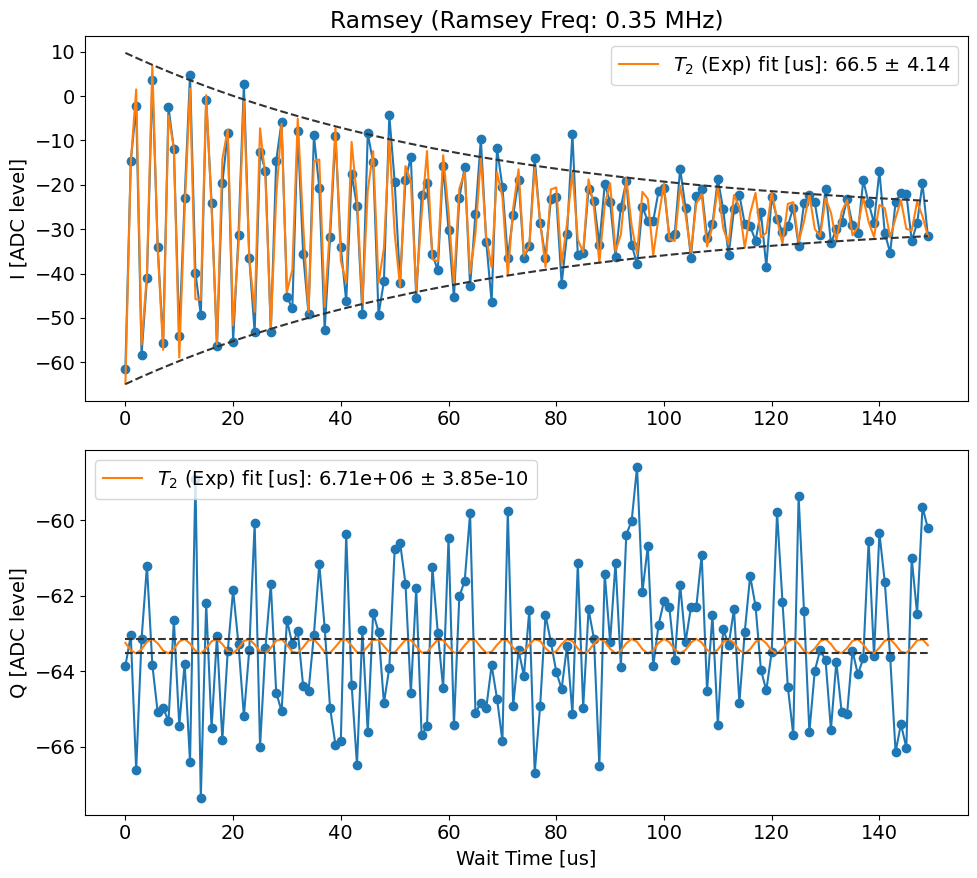

[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\Stark-induced sweet spot\2026\05\2026-05-21.md


In [ ]:
# === Single run at one drive_freq / target Rabi rate ===
I_set_mA = -0.05              # current bias (change me)
rabi_rate = .1      # MHz target Rabi rate for the Stark drive
detuning_MHz = -70          # MHz from the coupler feature (sign matters)
rise_time = 2.4              # us per-edge ramp
# ramsey_virtual_detune = 3.6679 + 0.05 # MHz; the virtual detuning of the second pi/2 phase
ramsey_virtual_detune = 0.25 + 0.1# MHz; the virtual detuning of the second pi/2 phase
look = lookup_at_current(I_set_mA)
print(f'I_set_mA = {I_set_mA:+.4f} mA  (using lookup entry at I={look["I_used_mA"]:+.4f} mA)')
print(f'  f0g1      = {look["f0g1_MHz"]:.4f} MHz')
print(f'  f_coupler = {look["f_coupler_MHz"]:.4f} MHz')
print(f'  k_per_DAC = {look["k_per_DAC"]:.4e} MHz/DAC  (k_rad = {look["k_rad_per_us_per_DAC"]:.4e} rad/us/DAC)')

Gain = gain_for_rabi_rate(rabi_rate, look['k_rad_per_us_per_DAC'])
f_drive = look['f_coupler_MHz'] + detuning_MHz
t_start = 4 * rise_time
print(f'  Gain      = {Gain} DAC  (target rabi_rate = {rabi_rate} MHz)')
print(f'  drive_freq= {f_drive:.4f} MHz  (detuning = {detuning_MHz:+.2f} MHz)')

stark_ao_expt = stark_ao_runner.execute(
    coupler_current_mA=float(I_set_mA),
    mode='manipulate',
    man_mode_idx=1,
    start=0,
    # step= 1,
    step= 1rk_ao_expt.analyze(fit=True)
# stark_ao_expt.display(fit=True)


## Drive-frequency detuning sweep (live plot)

### 6MHz setup

[2/2] Δ = -3.00 MHz   stark_shift = 2.647 MHz   ramsey_freq(used) = 2.697 MHz   T2 = 65.39 us
Current pi pulse frequency: 3564.2565120868453
Envelope chosen (I): exp  (SSR exp=1483, gauss=1532)
Fit frequency from I [MHz]: 0.9483530146770061 +/- 0.00030776195746195644
Suggested new pi pulse frequency from fit I [MHz]:
 	3566.0051916024736
 	3567.9018976318275
T2 Ramsey from fit I [us]: 65.39067501485079  (envelope=exp)
Envelope chosen (Q): exp  (SSR exp=271.9, gauss=271.8)
Fit frequency from Q [MHz]: 0.021474781481617664 +/- 0.05419495535732788
Suggested new pi pulse frequency from fit Q [MHz]:
 	3566.9320698356687
 	3566.975019398632
T2 Ramsey from fit Q [us]: 5.700624292251382  (envelope=exp)


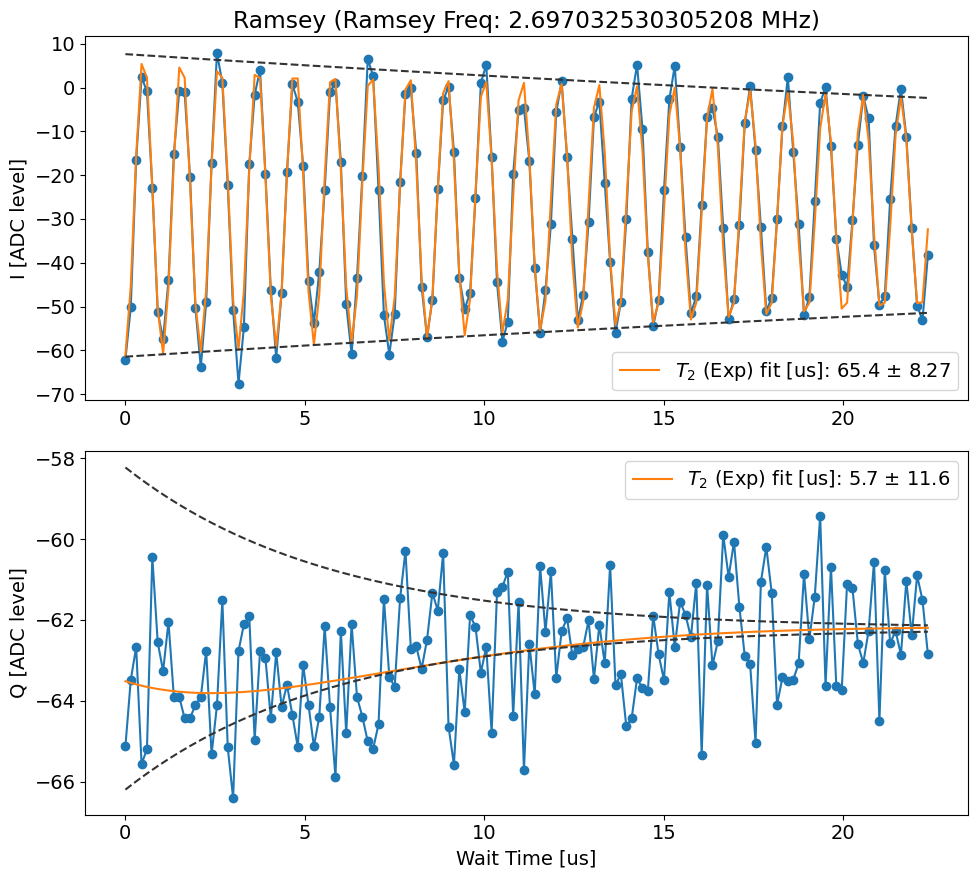

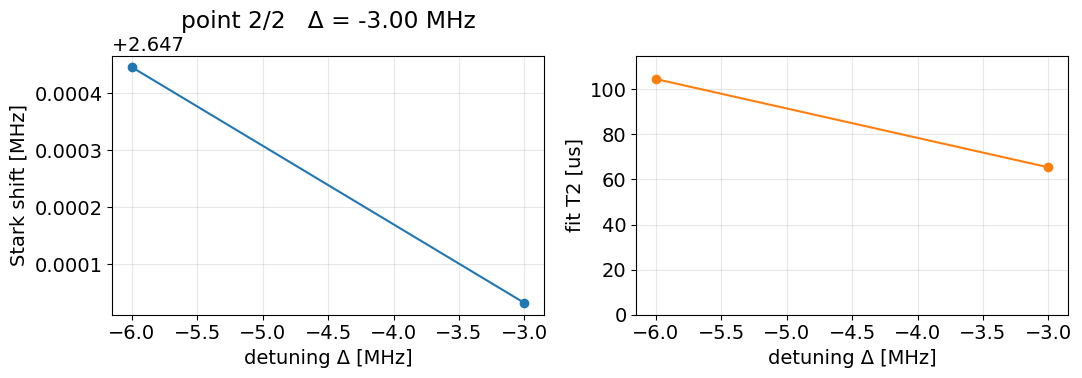

In [40]:
# === Detuning sweep at fixed bias (two-pass per point: quick → long Ramsey) ===
# Pass 1: quick Ramsey at ramsey_freq=0 → fit_freq is the bare Stark shift.
# Pass 2: long Ramsey at ramsey_freq = stark_shift + small offset → fit_T2.
from IPython.display import clear_output, display

# --- Sweep parameters ---
I_set_mA       = -0.05            # current bias
rabi_rate      = 0.01              # MHz target Stark Rabi rate
rise_time      = 2.4              # us per-edge ramp
virtual_offset = 0.05             # MHz small offset added to measured Stark shift for pass 2

f_npts         = 2
detuning_min   = -6             # MHz
detuning_max   = -3              # MHz

# --- Pass-specific timing (rest of cfg is shared) ---
quick_kwargs = dict(start=0.0,   step=0.075, expts=75,  ramsey_freq=1.0, reps=100)
long_kwargs  = dict(start=0.0,   step=0.15,  expts=151, reps=500)   # ramsey_freq filled per point

common_cfg = dict(
    mode='manipulate', man_mode_idx=1,
    drive_gain=None,                       # filled in after Gain is computed
    rise_time=float(rise_time),
    stark_guard_pre=20.0, stark_guard_post=1.0,
    rounds=1,
    relax_delay=1000,
)

look  = lookup_at_current(I_set_mA)
Gain  = gain_for_rabi_rate(rabi_rate, look['k_rad_per_us_per_DAC'])
common_cfg['drive_gain'] = int(Gain)

drive_freqs   = np.linspace(look['f_coupler_MHz'] + detuning_min,
                            look['f_coupler_MHz'] + detuning_max, f_npts)
detunings_MHz = drive_freqs - look['f_coupler_MHz']
print(f'Sweeping drive_freq {drive_freqs[0]:.3f} → {drive_freqs[-1]:.3f} MHz  '
      f'({f_npts} pts, Δ = {detuning_min:+.1f}..{detuning_max:+.1f} MHz)  '
      f'at I = {I_set_mA:+.4f} mA, Gain = {Gain}, rabi = {rabi_rate} MHz')


def _fit_freq_decay(expt):
    """Return (freq_MHz, T2_us) from a fitted Ramsey expt, or (nan, nan)."""
    p = expt.data.get('fit_avgi')
    if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
        return float(abs(p[1])), float(abs(p[3]))
    return float('nan'), float('nan')


stark_shifts_MHz, fit_T2s, ramsey_freqs_used = [], [], []
quick_fnames, long_fnames = [], []

for i, df in enumerate(drive_freqs):
    # ---- Pass 1: quick scan (ramsey_freq = 0 → Stark shift) ----
    expt_quick = stark_ao_runner.execute(
        coupler_current_mA=float(I_set_mA),
        drive_freq=float(df),
        **quick_kwargs,
        go_kwargs=dict(analyze=False, display=False),
        **common_cfg,
    )
    expt_quick.analyze(fit=True)
    stark_shift, _ = _fit_freq_decay(expt_quick)
    stark_shifts_MHz.append(stark_shift)
    quick_fnames.append(str(getattr(expt_quick, 'fname', '') or ''))

    # ---- Pass 2: long Ramsey at virtual detune = stark_shift + offset → T2 ----
    if np.isfinite(stark_shift):
        rfreq = float(stark_shift + virtual_offset)
        expt_long = stark_ao_runner.execute(
            coupler_current_mA=float(I_set_mA),
            drive_freq=float(df),
            ramsey_freq=rfreq,
            **long_kwargs,
            go_kwargs=dict(analyze=False, display=False),
            **common_cfg,
        )
        expt_long.analyze(fit=True)
        _, T2 = _fit_freq_decay(expt_long)
        long_fnames.append(str(getattr(expt_long, 'fname', '') or ''))
    else:
        rfreq, T2 = float('nan'), float('nan')
        expt_long = None
        long_fnames.append('')
    ramsey_freqs_used.append(rfreq)
    fit_T2s.append(T2)

    # ---- Live plot ----
    clear_output(wait=True)
    print(f'[{i+1}/{f_npts}] Δ = {detunings_MHz[i]:+.2f} MHz   '
          f'stark_shift = {stark_shift:.3f} MHz   '
          f'ramsey_freq(used) = {rfreq:.3f} MHz   '
          f'T2 = {T2:.2f} us')
    if expt_long is not None:
        expt_long.display(fit=True)
    else:
        expt_quick.display(fit=True)

    det_arr = detunings_MHz[:i+1]
    fig, (ax_s, ax_t2) = plt.subplots(1, 2, figsize=(11, 4))
    ax_s.plot(det_arr, stark_shifts_MHz, 'o-')
    ax_s.set_xlabel('detuning Δ [MHz]'); ax_s.set_ylabel('Stark shift [MHz]')
    ax_s.set_title(f'point {i+1}/{f_npts}   Δ = {detunings_MHz[i]:+.2f} MHz')
    ax_s.grid(alpha=0.3)

    ax_t2.plot(det_arr, fit_T2s, 'o-', color='C1')
    ax_t2.set_xlabel('detuning Δ [MHz]'); ax_t2.set_ylabel('fit T2 [us]')
    ax_t2.grid(alpha=0.3)
    finite_T2 = np.asarray(fit_T2s)[np.isfinite(fit_T2s)]
    if finite_T2.size:
        ax_t2.set_ylim(0, max(1.1 * finite_T2.max(), 1.0))
    plt.tight_layout()
    display(fig)
    plt.close(fig)


drive_freq_sweep = dict(
    I_set_mA=float(I_set_mA),
    rabi_rate=float(rabi_rate),
    Gain=int(Gain),
    drive_freqs=np.asarray(drive_freqs),
    detunings_MHz=np.asarray(detunings_MHz),
    stark_shifts_MHz=np.asarray(stark_shifts_MHz),
    fit_T2s=np.asarray(fit_T2s),
    ramsey_freqs_used=np.asarray(ramsey_freqs_used),
    quick_kwargs=quick_kwargs,
    long_kwargs=long_kwargs,
    quick_fnames=quick_fnames,
    long_fnames=long_fnames,
)


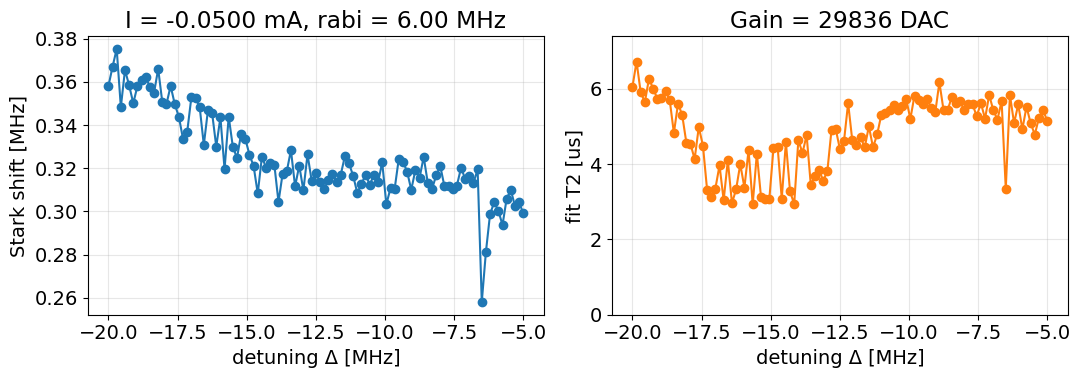

[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\Stark-induced sweet spot\2026\05\2026-05-20.md


In [22]:
# === Final plot + log_measurement for the detuning sweep ===
sweep = drive_freq_sweep
det_arr      = np.asarray(sweep['detunings_MHz'])
df_arr       = np.asarray(sweep['drive_freqs'])
stark_arr    = np.asarray(sweep['stark_shifts_MHz'])
T2_arr       = np.asarray(sweep['fit_T2s'])
rfreqs_used  = np.asarray(sweep['ramsey_freqs_used'])
quick_fnames = sweep.get('quick_fnames', [])
long_fnames  = sweep.get('long_fnames',  [])


def _cfg_get(key, default=None):
    """Look in long_kwargs, then quick_kwargs, then common_cfg."""
    for d in (sweep.get('long_kwargs', {}),
              sweep.get('quick_kwargs', {}),
              common_cfg):
        if isinstance(d, dict) and key in d:
            return d[key]
    return default


fig, (ax_s, ax_t2) = plt.subplots(1, 2, figsize=(11, 4))

ax_s.plot(det_arr, stark_arr, 'o-')
ax_s.set_xlabel('detuning Δ [MHz]')
ax_s.set_ylabel('Stark shift [MHz]')
ax_s.set_title(f'I = {sweep["I_set_mA"]:+.4f} mA, rabi = {sweep["rabi_rate"]:.2f} MHz')
ax_s.grid(alpha=0.3)

ax_t2.plot(det_arr, T2_arr, 'o-', color='C1')
ax_t2.set_xlabel('detuning Δ [MHz]')
ax_t2.set_ylabel('fit T2 [us]')
ax_t2.set_title(f'Gain = {sweep["Gain"]} DAC')
ax_t2.grid(alpha=0.3)
finite_T2 = T2_arr[np.isfinite(T2_arr)]
if finite_T2.size:
    ax_t2.set_ylim(0, max(1.1 * finite_T2.max(), 1.0))

plt.tight_layout()
display(fig)

# --- Log to the vault ---
try:
    station.log_measurement(
        fig=fig,
        title=(f'Stark always-on Ramsey detuning sweep '
               f'I={sweep["I_set_mA"]:+.4f} mA, rabi={sweep["rabi_rate"]:.2f} MHz'),
        notes=('Two-pass per drive_freq: pass 1 = quick Ramsey at ramsey_freq=0 '
               '(fit gives Stark shift); pass 2 = long Ramsey at ramsey_freq = '
               'stark_shift + virtual_offset (fit gives T2). Drive on manipulate, '
               'always-on (rise -> const -> fall), frequency tracks f_coupler(I) + Δ. '
               'quick_fnames / long_fnames give the per-point h5 source files.'),
        parameters={
            'I_mA':              float(sweep['I_set_mA']),
            'rabi_rate_MHz':     float(sweep['rabi_rate']),
            'Gain_DAC':          int(sweep['Gain']),
            'rise_time_us':      _cfg_get('rise_time'),
            'stark_guard_pre':   _cfg_get('stark_guard_pre'),
            'stark_guard_post':  _cfg_get('stark_guard_post'),
            'reps':              _cfg_get('reps'),
            'rounds':            _cfg_get('rounds'),
            'relax_delay':       _cfg_get('relax_delay'),
            'quick_kwargs':      sweep.get('quick_kwargs'),
            'long_kwargs':       sweep.get('long_kwargs'),
            'f_coupler_MHz':     float(look['f_coupler_MHz']),
            'f0g1_MHz':          float(look['f0g1_MHz']),
            'k_per_DAC':         float(look['k_per_DAC']),
            'detunings_MHz':     [float(v) for v in det_arr.tolist()],
            'drive_freqs_MHz':   [float(v) for v in df_arr.tolist()],
            'stark_shifts_MHz':  [float(v) for v in stark_arr.tolist()],
            'fit_T2s_us':        [float(v) for v in T2_arr.tolist()],
            'ramsey_freqs_used': [float(v) for v in rfreqs_used.tolist()],
            'quick_fnames':      list(quick_fnames),
            'long_fnames':       list(long_fnames),
        },
    )
except Exception as e:
    print(f'[log_measurement] failed: {type(e).__name__}: {e}')

plt.close(fig)


### 3MHz setup

[121/121] Δ = -2.00 MHz   stark_shift = 0.245 MHz   ramsey_freq(used) = 0.285 MHz   T2 = 6.77 us


Current pi pulse frequency: 3564.2565120868453
Envelope chosen (I): exp  (SSR exp=976, gauss=1195)
Fit frequency from I [MHz]: 0.241078467401591 +/- 0.0011957871691347806
Suggested new pi pulse frequency from fit I [MHz]:
 	3564.300647855911
 	3564.7828047907137
T2 Ramsey from fit I [us]: 6.772992112281186  (envelope=exp)
Envelope chosen (Q): exp  (SSR exp=967.6, gauss=1021)
Fit frequency from Q [MHz]: 0.016923131709582154 +/- 0.016375183537072794
Suggested new pi pulse frequency from fit Q [MHz]:
 	3564.5248031916026
 	3564.558649455022
T2 Ramsey from fit Q [us]: 5.9576915901512795  (envelope=exp)


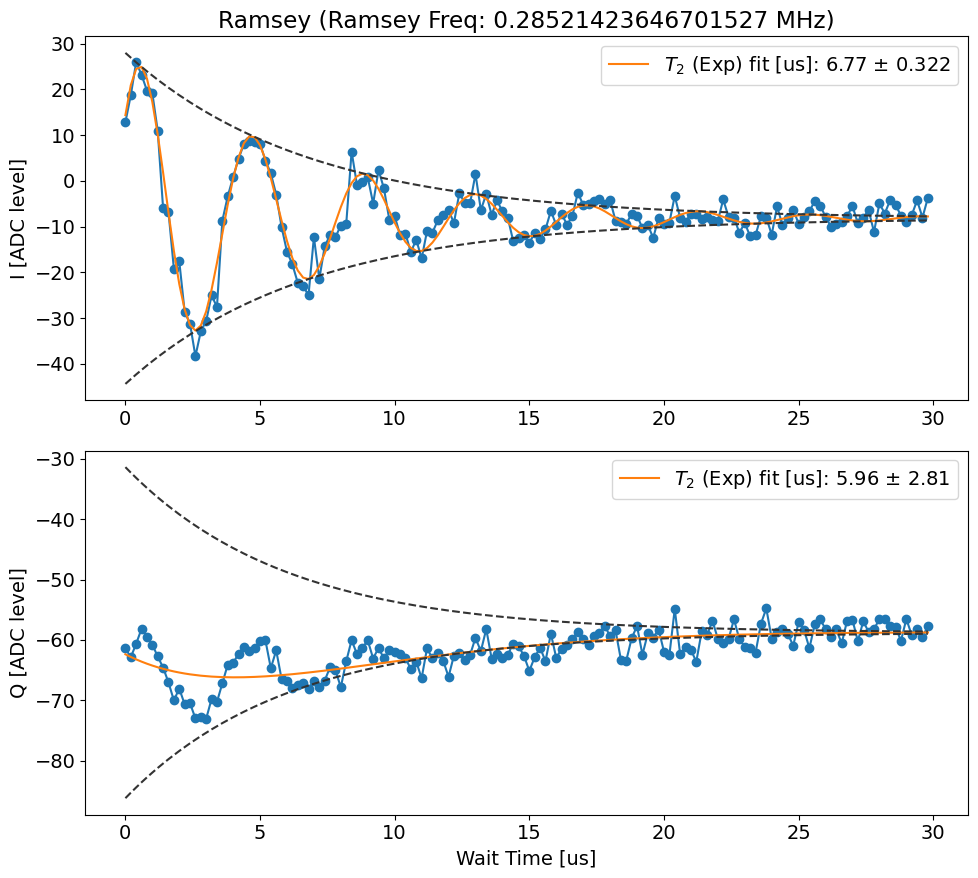

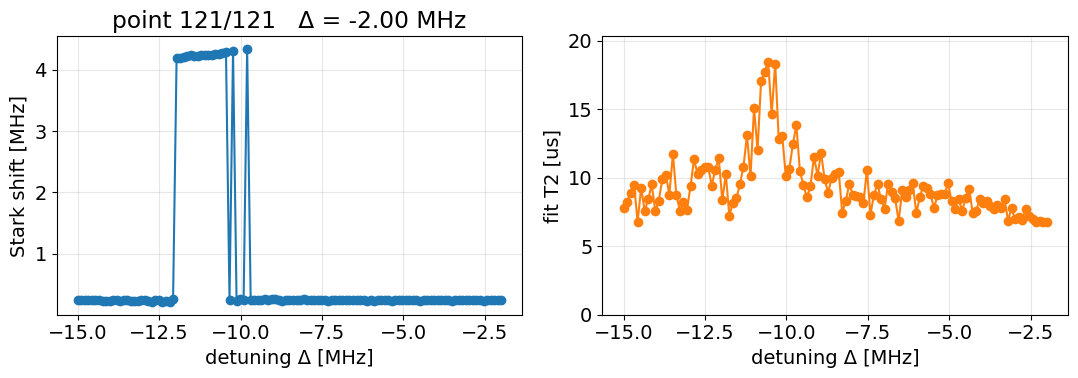

In [26]:
# === Detuning sweep at fixed bias (two-pass per point: quick → long Ramsey) ===
# Pass 1: quick Ramsey at ramsey_freq=0 → fit_freq is the bare Stark shift.
# Pass 2: long Ramsey at ramsey_freq = stark_shift + small offset → fit_T2.
from IPython.display import clear_output, display

# --- Sweep parameters ---
I_set_mA       = -0.05            # current bias
rabi_rate      = 3.0              # MHz target Stark Rabi rate
rise_time      = 2.4              # us per-edge ramp
virtual_offset = 0.04             # MHz small offset added to measured Stark shift for pass 2

f_npts         = 121
detuning_min   = -15             # MHz
detuning_max   = -2              # MHz

# --- Pass-specific timing (rest of cfg is shared) ---
quick_kwargs = dict(start=0.0,   step=0.075, expts=75,  ramsey_freq=0.0, reps=100)
long_kwargs  = dict(start=0.0,   step=0.20,  expts=151, reps=500)   # ramsey_freq filled per point

common_cfg = dict(
    mode='manipulate', man_mode_idx=1,
    drive_gain=None,                       # filled in after Gain is computed
    rise_time=float(rise_time),
    stark_guard_pre=20.0, stark_guard_post=1.0,
    rounds=1,
    relax_delay=1000,
)

look  = lookup_at_current(I_set_mA)
Gain  = gain_for_rabi_rate(rabi_rate, look['k_rad_per_us_per_DAC'])
common_cfg['drive_gain'] = int(Gain)

drive_freqs   = np.linspace(look['f_coupler_MHz'] + detuning_min,
                            look['f_coupler_MHz'] + detuning_max, f_npts)
detunings_MHz = drive_freqs - look['f_coupler_MHz']
print(f'Sweeping drive_freq {drive_freqs[0]:.3f} → {drive_freqs[-1]:.3f} MHz  '
      f'({f_npts} pts, Δ = {detuning_min:+.1f}..{detuning_max:+.1f} MHz)  '
      f'at I = {I_set_mA:+.4f} mA, Gain = {Gain}, rabi = {rabi_rate} MHz')


def _fit_freq_decay(expt):
    """Return (freq_MHz, T2_us) from a fitted Ramsey expt, or (nan, nan)."""
    p = expt.data.get('fit_avgi')
    if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
        return float(abs(p[1])), float(abs(p[3]))
    return float('nan'), float('nan')


stark_shifts_MHz, fit_T2s, ramsey_freqs_used = [], [], []
quick_fnames, long_fnames = [], []

for i, df in enumerate(drive_freqs):
    # ---- Pass 1: quick scan (ramsey_freq = 0 → Stark shift) ----
    expt_quick = stark_ao_runner.execute(
        coupler_current_mA=float(I_set_mA),
        drive_freq=float(df),
        **quick_kwargs,
        go_kwargs=dict(analyze=False, display=False),
        **common_cfg,
    )
    expt_quick.analyze(fit=True)
    stark_shift, _ = _fit_freq_decay(expt_quick)
    stark_shifts_MHz.append(stark_shift)
    quick_fnames.append(str(getattr(expt_quick, 'fname', '') or ''))

    # ---- Pass 2: long Ramsey at virtual detune = stark_shift + offset → T2 ----
    if np.isfinite(stark_shift):
        rfreq = float(stark_shift + virtual_offset)
        expt_long = stark_ao_runner.execute(
            coupler_current_mA=float(I_set_mA),
            drive_freq=float(df),
            ramsey_freq=rfreq,
            **long_kwargs,
            go_kwargs=dict(analyze=False, display=False),
            **common_cfg,
        )
        expt_long.analyze(fit=True)
        _, T2 = _fit_freq_decay(expt_long)
        long_fnames.append(str(getattr(expt_long, 'fname', '') or ''))
    else:
        rfreq, T2 = float('nan'), float('nan')
        expt_long = None
        long_fnames.append('')
    ramsey_freqs_used.append(rfreq)
    fit_T2s.append(T2)

    # ---- Live plot ----
    clear_output(wait=True)
    print(f'[{i+1}/{f_npts}] Δ = {detunings_MHz[i]:+.2f} MHz   '
          f'stark_shift = {stark_shift:.3f} MHz   '
          f'ramsey_freq(used) = {rfreq:.3f} MHz   '
          f'T2 = {T2:.2f} us')
    if expt_long is not None:
        expt_long.display(fit=True)
    else:
        expt_quick.display(fit=True)

    det_arr = detunings_MHz[:i+1]
    fig, (ax_s, ax_t2) = plt.subplots(1, 2, figsize=(11, 4))
    ax_s.plot(det_arr, stark_shifts_MHz, 'o-')
    ax_s.set_xlabel('detuning Δ [MHz]'); ax_s.set_ylabel('Stark shift [MHz]')
    ax_s.set_title(f'point {i+1}/{f_npts}   Δ = {detunings_MHz[i]:+.2f} MHz')
    ax_s.grid(alpha=0.3)

    ax_t2.plot(det_arr, fit_T2s, 'o-', color='C1')
    ax_t2.set_xlabel('detuning Δ [MHz]'); ax_t2.set_ylabel('fit T2 [us]')
    ax_t2.grid(alpha=0.3)
    finite_T2 = np.asarray(fit_T2s)[np.isfinite(fit_T2s)]
    if finite_T2.size:
        ax_t2.set_ylim(0, max(1.1 * finite_T2.max(), 1.0))
    plt.tight_layout()
    display(fig)
    plt.close(fig)


drive_freq_sweep = dict(
    I_set_mA=float(I_set_mA),
    rabi_rate=float(rabi_rate),
    Gain=int(Gain),
    drive_freqs=np.asarray(drive_freqs),
    detunings_MHz=np.asarray(detunings_MHz),
    stark_shifts_MHz=np.asarray(stark_shifts_MHz),
    fit_T2s=np.asarray(fit_T2s),
    ramsey_freqs_used=np.asarray(ramsey_freqs_used),
    quick_kwargs=quick_kwargs,
    long_kwargs=long_kwargs,
    quick_fnames=quick_fnames,
    long_fnames=long_fnames,
)


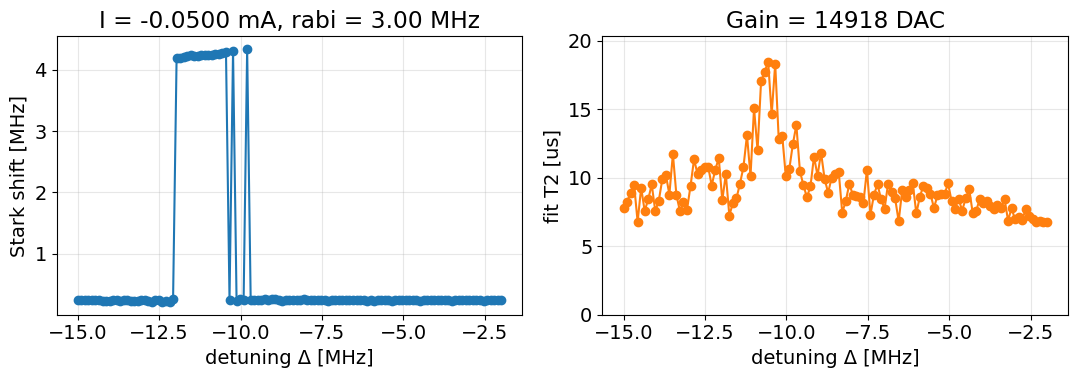

[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\Stark-induced sweet spot\2026\05\2026-05-21.md


In [27]:
# === Final plot + log_measurement for the detuning sweep ===
sweep = drive_freq_sweep
det_arr      = np.asarray(sweep['detunings_MHz'])
df_arr       = np.asarray(sweep['drive_freqs'])
stark_arr    = np.asarray(sweep['stark_shifts_MHz'])
T2_arr       = np.asarray(sweep['fit_T2s'])
rfreqs_used  = np.asarray(sweep['ramsey_freqs_used'])
quick_fnames = sweep.get('quick_fnames', [])
long_fnames  = sweep.get('long_fnames',  [])


def _cfg_get(key, default=None):
    """Look in long_kwargs, then quick_kwargs, then common_cfg."""
    for d in (sweep.get('long_kwargs', {}),
              sweep.get('quick_kwargs', {}),
              common_cfg):
        if isinstance(d, dict) and key in d:
            return d[key]
    return default


fig, (ax_s, ax_t2) = plt.subplots(1, 2, figsize=(11, 4))

ax_s.plot(det_arr, stark_arr, 'o-')
ax_s.set_xlabel('detuning Δ [MHz]')
ax_s.set_ylabel('Stark shift [MHz]')
ax_s.set_title(f'I = {sweep["I_set_mA"]:+.4f} mA, rabi = {sweep["rabi_rate"]:.2f} MHz')
ax_s.grid(alpha=0.3)

ax_t2.plot(det_arr, T2_arr, 'o-', color='C1')
ax_t2.set_xlabel('detuning Δ [MHz]')
ax_t2.set_ylabel('fit T2 [us]')
ax_t2.set_title(f'Gain = {sweep["Gain"]} DAC')
ax_t2.grid(alpha=0.3)
finite_T2 = T2_arr[np.isfinite(T2_arr)]
if finite_T2.size:
    ax_t2.set_ylim(0, max(1.1 * finite_T2.max(), 1.0))

plt.tight_layout()
display(fig)

# --- Log to the vault ---
try:
    station.log_measurement(
        fig=fig,
        title=(f'Stark always-on Ramsey detuning sweep '
               f'I={sweep["I_set_mA"]:+.4f} mA, rabi={sweep["rabi_rate"]:.2f} MHz'),
        notes=('Two-pass per drive_freq: pass 1 = quick Ramsey at ramsey_freq=0 '
               '(fit gives Stark shift); pass 2 = long Ramsey at ramsey_freq = '
               'stark_shift + virtual_offset (fit gives T2). Drive on manipulate, '
               'always-on (rise -> const -> fall), frequency tracks f_coupler(I) + Δ. '
               'quick_fnames / long_fnames give the per-point h5 source files.'),
        parameters={
            'I_mA':              float(sweep['I_set_mA']),
            'rabi_rate_MHz':     float(sweep['rabi_rate']),
            'Gain_DAC':          int(sweep['Gain']),
            'rise_time_us':      _cfg_get('rise_time'),
            'stark_guard_pre':   _cfg_get('stark_guard_pre'),
            'stark_guard_post':  _cfg_get('stark_guard_post'),
            'reps':              _cfg_get('reps'),
            'rounds':            _cfg_get('rounds'),
            'relax_delay':       _cfg_get('relax_delay'),
            'quick_kwargs':      sweep.get('quick_kwargs'),
            'long_kwargs':       sweep.get('long_kwargs'),
            'f_coupler_MHz':     float(look['f_coupler_MHz']),
            'f0g1_MHz':          float(look['f0g1_MHz']),
            'k_per_DAC':         float(look['k_per_DAC']),
            'detunings_MHz':     [float(v) for v in det_arr.tolist()],
            'drive_freqs_MHz':   [float(v) for v in df_arr.tolist()],
            'stark_shifts_MHz':  [float(v) for v in stark_arr.tolist()],
            'fit_T2s_us':        [float(v) for v in T2_arr.tolist()],
            'ramsey_freqs_used': [float(v) for v in rfreqs_used.tolist()],
            'quick_fnames':      list(quick_fnames),
            'long_fnames':       list(long_fnames),
        },
    )
except Exception as e:
    print(f'[log_measurement] failed: {type(e).__name__}: {e}')

plt.close(fig)
